<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/R_F_IOL_STUDY_11626.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [229]:
import pandas as pd
import numpy as np

In [230]:
sheets = pd.ExcelFile('/content/drive/MyDrive/Keerthi krishna thesis clean data preprocesed (2).xlsx')
sheets.sheet_names

['rigid IOL',
 'R preop',
 'R pod1',
 'R pod6wks',
 'R pod3mths',
 'foldable IOL',
 'F preop',
 'F pod1',
 'F pod6wks',
 'F pod3mthh',
 'R and F age analysis',
 'Cataract grading ',
 'Laterality ',
 'Gender']

In [231]:
rigid_preop = sheets.parse('R preop')
rigid_pod1 = sheets.parse('R pod1')
rigid_pod6wks = sheets.parse('R pod6wks')
rigid_pod3mths = sheets.parse('R pod3mths')

In [232]:
rigid_pod1.columns

Index(['Name', 'Age-R', 'Sex-R', 'Laterality-R', 'Cataract grading-R ',
       'Preop VA snellen-R ', 'POD1 IOP-R ', 'POD1 ACD-R ', 'POD1 LV-R ',
       'POD1 CCT-R ', 'POD1 ACA-R  ', 'POD1 ATA-R', 'AOD T POD1 500-R',
       'AOD T POD1 750-R ', 'TISA T POD1 500-R ', 'TISA T 750 POD1-R',
       'SSA-T POD1-R ', 'AOD POD1 N 500-R ', 'AOD POD1 N 750-R  ',
       'TISA POD1 N 500-R ', 'TISA POD1 N 750-R ', 'SSA-N POD1-R '],
      dtype='object')

In [233]:
fold_preop = sheets.parse('F preop')
fold_pod1 = sheets.parse('F pod1')
fold_pod6wks = sheets.parse('F pod6wks')
fold_pod3mths = sheets.parse('F pod3mthh')


### Baseline characteristics

R and F age analysis

Gender

Laterality

Cataract grading

Creat Table 1: Baseline Demographic and Clinical Characteristics

In [234]:
rigid_preop.columns, fold_preop.columns

(Index(['Name', 'Age-R', 'Sex-R', 'Laterality-R', 'Cataract grading-R ',
        'Preop VA snellen-R ', 'Preop LogMAR-R ', 'Preop IOP-R', 'Preop ACD-R ',
        'Preop LV-R', 'Preop CCT-R ', 'Preop ACA-R  ', 'Preop ATA-R ',
        'Preop AOD N 500-R ', 'preop AOD N 750-R ', 'Preop TISA N 500-R ',
        'Preop TISA N 750-R ', 'Preop SSA-N R ', 'Preop AOD T 500-R  ',
        'Preop AOD T 750-R ', 'Preop TISAT  500-R  ', 'Preop TISA T 750-R ',
        'Preop SSA-T-R'],
       dtype='object'),
 Index(['Name', 'Age (F)', 'Sex (F) ', 'Cataract grading-F ', 'Laterality (F)',
        'Preop VA (F)', ' preop IOP (F)', 'Preop ACD (F)', 'Preop LV (F)',
        'Preop CCT (F)', 'Preop ACA (F) ', 'Preop ATA (F)',
        'Preop AOD N 500 (F)', 'Preop AOD N 750 (F) ', 'Preop TISA N 500 (F)',
        'Preop TISA N 750 (F)', 'Preop SSA-N (F) ', 'Preop AOD T 500 (F) ',
        'Preop AOD T 750 (F) ', 'Preop TISA T 500 (F) ',
        'Preop TISA T 750 (F) ', 'Preop SSA-T (F) '],
       dtype='object

In [235]:
from scipy.stats import shapiro, ttest_ind, mannwhitneyu

rigid_age = rigid_preop['Age-R'].dropna()
fold_age = fold_preop['Age (F)'].dropna()

if shapiro(rigid_age).pvalue > 0.05 and shapiro(fold_age).pvalue > 0.05:
    stat, p = ttest_ind(rigid_age, fold_age)
else:
    stat, p = mannwhitneyu(rigid_age, fold_age)

print(f"Age p-value = {p:.4f}")

Age p-value = 0.0741


In [236]:
from scipy.stats import shapiro

# Age data
age_rigid = rigid_preop['Age-R'].dropna()
age_fold = fold_preop['Age (F)'].dropna()

# Shapiro-Wilk test
shapiro_rigid = shapiro(age_rigid)
shapiro_fold = shapiro(age_fold)

print("Rigid IOL Age:")
print(f"W = {shapiro_rigid.statistic:.4f}, p = {shapiro_rigid.pvalue:.4f}")

print("\nFoldable IOL Age:")
print(f"W = {shapiro_fold.statistic:.4f}, p = {shapiro_fold.pvalue:.4f}")

Rigid IOL Age:
W = 0.9429, p = 0.1191

Foldable IOL Age:
W = 0.9690, p = 0.5327


In [237]:
from scipy.stats import ttest_ind, mannwhitneyu

if shapiro_rigid.pvalue > 0.05 and shapiro_fold.pvalue > 0.05:
    stat, p = ttest_ind(age_rigid, age_fold)
    print(f"Independent t-test: p = {p:.4f}")
else:
    stat, p = mannwhitneyu(age_rigid, age_fold)
    print(f"Mann-Whitney U test: p = {p:.4f}")

Independent t-test: p = 0.0741


In [238]:
rigid_gender_counts = rigid_preop['Sex-R'].value_counts().rename('Rigid Count')
fold_gender_counts = fold_preop['Sex (F) '].value_counts().rename('Foldable Count')

gender_df = pd.concat([rigid_gender_counts, fold_gender_counts], axis=1)
gender_df.index.name = 'Gender'
gender_df = gender_df.fillna(0).astype(int)

gender_df['Rigid %'] = (
    gender_df['Rigid Count'] /
    gender_df['Rigid Count'].sum() * 100
).round(1)

gender_df['Foldable %'] = (
    gender_df['Foldable Count'] /
    gender_df['Foldable Count'].sum() * 100
).round(1)

print(gender_df)

        Rigid Count  Foldable Count  Rigid %  Foldable %
Gender                                                  
F                15              17     51.7        58.6
M                14              12     48.3        41.4


In [239]:
from scipy.stats import chi2_contingency

table = gender_df[['Rigid Count','Foldable Count']].values

chi2, p, dof, expected = chi2_contingency(table)

print("Gender p-value =", p)

Gender p-value = 0.7917572434026547


In [240]:
rigid_laterality_counts = rigid_preop['Laterality-R'].value_counts().rename('Rigid Count')
fold_laterality_counts = fold_preop['Laterality (F)'].value_counts().rename('Foldable Count')

laterality_df = pd.concat([rigid_laterality_counts, fold_laterality_counts], axis=1)
laterality_df.index.name = 'Laterality'
laterality_df = laterality_df.fillna(0).astype(int)

table = laterality_df[['Rigid Count','Foldable Count']].values

chi2, p, dof, expected = chi2_contingency(table)

print("Laterality p-value =", p)
print(laterality_df)

Laterality p-value = 2.9571317267959e-07
            Rigid Count  Foldable Count
Laterality                             
LE                   16               0
RE                    5               0
RE                    4              11
LE                    4              18


In [241]:
rigid_cataract_counts = rigid_preop['Cataract grading-R '].value_counts().rename('Rigid Count')
fold_cataract_counts = fold_preop['Cataract grading-F '].value_counts().rename('Foldable Count')

cataract_df = pd.concat([rigid_cataract_counts, fold_cataract_counts], axis=1)
cataract_df.index.name = 'Cataract Grade'
cataract_df = cataract_df.fillna(0).astype(int)

table = cataract_df[['Rigid Count','Foldable Count']].values

chi2, p, dof, expected = chi2_contingency(table)

print("Cataract grade p-value =", p)
print(cataract_df)

Cataract grade p-value = 0.12831352788995495
                Rigid Count  Foldable Count
Cataract Grade                             
NC                        4               5
NS 3                      4               0
NS 4                      4               1
MC                        3               2
 NC                       2               0
NS 1+PSC                  2               1
NMC                       2               1
 NS 3                     2               0
NS 2+PSC                  2               1
 MC                       1               0
PPC                       1               0
NS 2                      1               0
 NS 2                     1               0
NS4                       0               3
NS3                       0               3
NS                        0               2
NS 3                      0               1
NS3+PSC                   0               1
NS2+PSC                   0               1
NS2                       0    

In [242]:
cataract_df.index = (
    cataract_df.index
    .str.upper()
    .str.strip()
    .str.replace('NS3', 'NS 3')
    .str.replace('NS4', 'NS 4')
    .str.replace('NS2', 'NS 2')
    .str.replace('  ', ' ', regex=False)
    .str.replace('LE ', '')
    .str.replace('RE ', '')
)

In [243]:
cataract_df.index = (
    cataract_df.index.astype(str)
    .str.upper()
    .str.strip()
    .str.replace('NS3', 'NS 3', regex=False)
    .str.replace('NS4', 'NS 4', regex=False)
    .str.replace('NS2', 'NS 2', regex=False)
    .str.replace('  ', ' ', regex=False)
    .str.replace('LE ', '', regex=False)
    .str.replace('RE ', '', regex=False)
)

# Merge duplicate categories created by cleaning
cataract_df = cataract_df.groupby(level=0).sum()

cataract_df

,Rigid Count,Foldable Count
Cataract Grade,,
MC,4,2
NC,6,6
NMC,2,2
NS,0,2
NS 1+PSC,2,1
NS 2,2,1
NS 2 + PSC,0,1
NS 2+PSC,2,2
NS 3,6,5


In [244]:
total_rigid = cataract_df['Rigid Count'].sum()
total_fold = cataract_df['Foldable Count'].sum()

table = cataract_df.copy()

table['Rigid n (%)'] = (
    table['Rigid Count'].astype(str)
    + ' ('
    + (100 * table['Rigid Count'] / total_rigid).round(1).astype(str)
    + ')'
)

table['Foldable n (%)'] = (
    table['Foldable Count'].astype(str)
    + ' ('
    + (100 * table['Foldable Count'] / total_fold).round(1).astype(str)
    + ')'
)

table = table[['Rigid n (%)', 'Foldable n (%)']]
print(table)

               Rigid n (%) Foldable n (%)
Cataract Grade                           
MC                4 (13.8)        2 (6.9)
NC                6 (20.7)       6 (20.7)
NMC                2 (6.9)        2 (6.9)
NS                 0 (0.0)        2 (6.9)
NS 1+PSC           2 (6.9)        1 (3.4)
NS 2               2 (6.9)        1 (3.4)
NS 2 + PSC         0 (0.0)        1 (3.4)
NS 2+PSC           2 (6.9)        2 (6.9)
NS 3              6 (20.7)       5 (17.2)
NS 3+PSC           0 (0.0)        1 (3.4)
NS 4              4 (13.8)       4 (13.8)
NS 4+PSC           0 (0.0)        1 (3.4)
PPC                1 (3.4)        0 (0.0)
PSC+CC             0 (0.0)        1 (3.4)


This bar chart displays the percentage distribution of different cataract grades for both Rigid and Foldable IOL types. Each bar represents a cataract grade, with different colors distinguishing between Rigid and Foldable IOLs. The height of each bar corresponds to the percentage of patients within that cataract grade for the respective IOL type.

In [245]:
cataract_df.index = (
    cataract_df.index.astype(str)
    .str.upper()
    .str.strip()
    .str.replace(r'\s*\+\s*', '+', regex=True)  # NS 2 + PSC -> NS 2+PSC
    .str.replace(r'\s+', ' ', regex=True)       # remove extra spaces
)

# Combine identical categories
cataract_df = cataract_df.groupby(level=0).sum()

cataract_df

,Rigid Count,Foldable Count
Cataract Grade,,
MC,4,2
NC,6,6
NMC,2,2
NS,0,2
NS 1+PSC,2,1
NS 2,2,1
NS 2+PSC,2,3
NS 3,6,5
NS 3+PSC,0,1


In [246]:
from scipy.stats import chi2_contingency

gender_table = [
    [14, 15],  # Rigid: Male, Female
    [12, 17]   # Foldable: Male, Female
]

chi2, p, dof, expected = chi2_contingency(gender_table)

print(f"Chi-square = {chi2:.3f}")
print(f"p-value = {p:.4f}")

Chi-square = 0.070
p-value = 0.7918


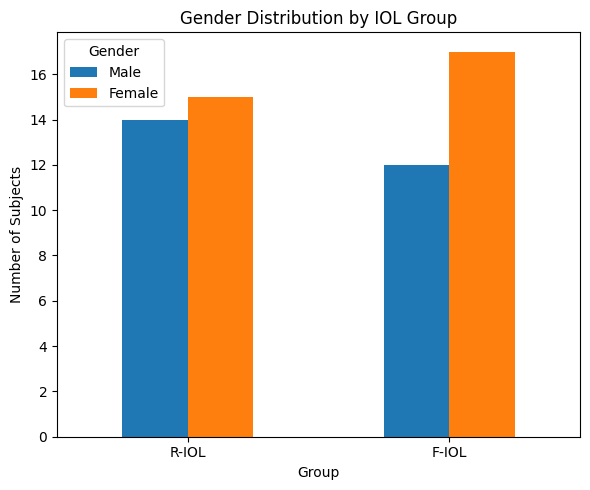

In [247]:
import pandas as pd
import matplotlib.pyplot as plt

# Data
gender_df = pd.DataFrame({
    'Group': ['R-IOL', 'F-IOL'],
    'Male': [14, 12],
    'Female': [15, 17]
})

# Plot
ax = gender_df.set_index('Group').plot(
    kind='bar',
    figsize=(6,5)
)

plt.title('Gender Distribution by IOL Group')
plt.xlabel('Group')
plt.ylabel('Number of Subjects')
plt.xticks(rotation=0)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

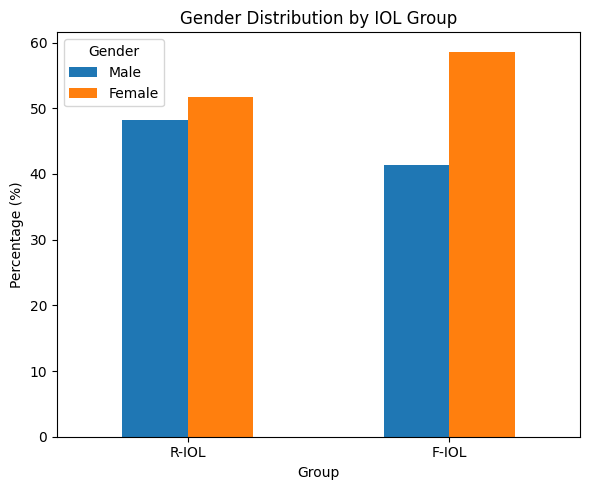

In [248]:
import pandas as pd
import matplotlib.pyplot as plt

gender_pct = pd.DataFrame({
    'Group': ['R-IOL', 'F-IOL'],
    'Male': [48.28, 41.38],
    'Female': [51.72, 58.62]
})

ax = gender_pct.set_index('Group').plot(
    kind='bar',
    figsize=(6,5)
)

plt.title('Gender Distribution by IOL Group')
plt.xlabel('Group')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

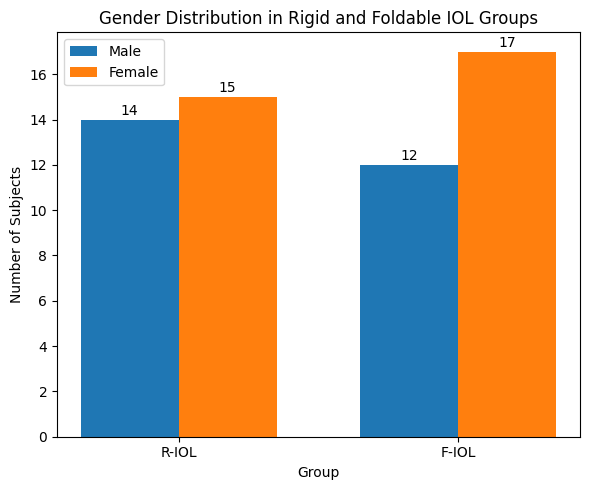

In [249]:
import numpy as np
import matplotlib.pyplot as plt

groups = ['R-IOL', 'F-IOL']
male = [14, 12]
female = [15, 17]

x = np.arange(len(groups))
width = 0.35

plt.figure(figsize=(6,5))

plt.bar(x - width/2, male, width, label='Male')
plt.bar(x + width/2, female, width, label='Female')

plt.xlabel('Group')
plt.ylabel('Number of Subjects')
plt.title('Gender Distribution in Rigid and Foldable IOL Groups')
plt.xticks(x, groups)
plt.legend()

# Add value labels
for i, v in enumerate(male):
    plt.text(x[i] - width/2, v + 0.2, str(v), ha='center')

for i, v in enumerate(female):
    plt.text(x[i] + width/2, v + 0.2, str(v), ha='center')

plt.tight_layout()
plt.show()

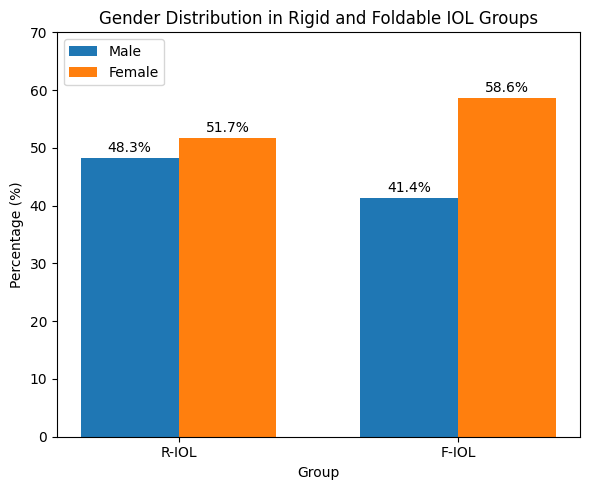

In [250]:
import numpy as np
import matplotlib.pyplot as plt

groups = ['R-IOL', 'F-IOL']
male = [48.28, 41.38]
female = [51.72, 58.62]

x = np.arange(len(groups))
width = 0.35

plt.figure(figsize=(6,5))

plt.bar(x - width/2, male, width, label='Male')
plt.bar(x + width/2, female, width, label='Female')

plt.xlabel('Group')
plt.ylabel('Percentage (%)')
plt.title('Gender Distribution in Rigid and Foldable IOL Groups')
plt.xticks(x, groups)
plt.legend()

for i, v in enumerate(male):
    plt.text(x[i] - width/2, v + 1, f'{v:.1f}%',

             ha='center')

for i, v in enumerate(female):
    plt.text(x[i] + width/2, v + 1, f'{v:.1f}%',

             ha='center')

plt.ylim(0, 70)
plt.tight_layout()
plt.show()

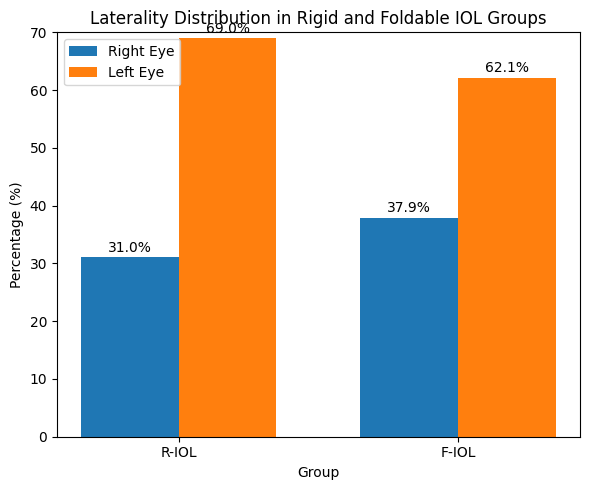

In [251]:
import numpy as np
import matplotlib.pyplot as plt

groups = ['R-IOL', 'F-IOL']

right_eye = [31.03, 37.93]   # Replace with your percentages
left_eye = [68.97, 62.07]    # Replace with your percentages

x = np.arange(len(groups))
width = 0.35

plt.figure(figsize=(6,5))

plt.bar(x - width/2, right_eye, width, label='Right Eye')
plt.bar(x + width/2, left_eye, width, label='Left Eye')

plt.xlabel('Group')
plt.ylabel('Percentage (%)')
plt.title('Laterality Distribution in Rigid and Foldable IOL Groups')
plt.xticks(x, groups)
plt.legend()

for i, v in enumerate(right_eye):
    plt.text(x[i] - width/2, v + 1, f'{v:.1f}%', ha='center')

for i, v in enumerate(left_eye):
    plt.text(x[i] + width/2, v + 1, f'{v:.1f}%', ha='center')

plt.ylim(0, 70)
plt.tight_layout()
plt.show()

### Rigid IOL Group Analysis
R preop

R pod1

R pod6wks

R pod3mths

In [252]:
rigid_preop.columns, rigid_pod1.columns, rigid_pod6wks.columns, rigid_pod3mths.columns

(Index(['Name', 'Age-R', 'Sex-R', 'Laterality-R', 'Cataract grading-R ',
        'Preop VA snellen-R ', 'Preop LogMAR-R ', 'Preop IOP-R', 'Preop ACD-R ',
        'Preop LV-R', 'Preop CCT-R ', 'Preop ACA-R  ', 'Preop ATA-R ',
        'Preop AOD N 500-R ', 'preop AOD N 750-R ', 'Preop TISA N 500-R ',
        'Preop TISA N 750-R ', 'Preop SSA-N R ', 'Preop AOD T 500-R  ',
        'Preop AOD T 750-R ', 'Preop TISAT  500-R  ', 'Preop TISA T 750-R ',
        'Preop SSA-T-R'],
       dtype='object'),
 Index(['Name', 'Age-R', 'Sex-R', 'Laterality-R', 'Cataract grading-R ',
        'Preop VA snellen-R ', 'POD1 IOP-R ', 'POD1 ACD-R ', 'POD1 LV-R ',
        'POD1 CCT-R ', 'POD1 ACA-R  ', 'POD1 ATA-R', 'AOD T POD1 500-R',
        'AOD T POD1 750-R ', 'TISA T POD1 500-R ', 'TISA T 750 POD1-R',
        'SSA-T POD1-R ', 'AOD POD1 N 500-R ', 'AOD POD1 N 750-R  ',
        'TISA POD1 N 500-R ', 'TISA POD1 N 750-R ', 'SSA-N POD1-R '],
       dtype='object'),
 Index(['Name', 'Age-R', 'Sex-R', 'Laterality-

In [253]:
rigid_preop.isnull().sum()

,0
Name,0
Age-R,0
Sex-R,0
Laterality-R,0
Cataract grading-R,0
Preop VA snellen-R,0
Preop LogMAR-R,0
Preop IOP-R,0
Preop ACD-R,0
Preop LV-R,0


In [254]:
rigid_pod1.isnull().sum()
rigid_pod1.dropna(inplace=True)
rigid_pod1.isnull().sum()

,0
Name,0
Age-R,0
Sex-R,0
Laterality-R,0
Cataract grading-R,0
Preop VA snellen-R,0
POD1 IOP-R,0
POD1 ACD-R,0
POD1 LV-R,0
POD1 CCT-R,0


In [255]:
rigid_pod6wks.isnull().sum()
rigid_pod6wks.dropna(inplace=True)
rigid_pod6wks.isnull().sum()

,0
Name,0
Age-R,0
Sex-R,0
Laterality-R,0
Cataract grading-R,0
POD6wk IOP-R,0
ACD 6 wk-R,0
LV 6 wk-R,0
CCT 6 wk-R,0
ACA POD 6 wk-R,0


In [256]:
rigid_pod3mths.isnull().sum()

,0
Name,0
Age-R,0
Sex-R,0
Laterality-R,0
Cataract grading-R,0
POD3 mth IOP -R,17
ACD 3 mth-R,19
LV 3 mth-R,18
CCT 3 mth-R,19
ACA 3 mth-R,19


In [257]:
rigid_pod3mths.dropna(inplace=True)
rigid_pod3mths.isnull().sum()

,0
Name,0
Age-R,0
Sex-R,0
Laterality-R,0
Cataract grading-R,0
POD3 mth IOP -R,0
ACD 3 mth-R,0
LV 3 mth-R,0
CCT 3 mth-R,0
ACA 3 mth-R,0


In [258]:
fold_preop.isnull().sum()

,0
Name,0
Age (F),0
Sex (F),0
Cataract grading-F,0
Laterality (F),0
Preop VA (F),0
preop IOP (F),0
Preop ACD (F),0
Preop LV (F),0
Preop CCT (F),0


In [259]:
fold_pod1.isnull().sum()

,0
Name,0
Age (F),0
Sex (F),0
Cataract grading-F,0
Laterality (F),0
POD1 IOP (F),0
ACD POD1 (F),0
LV POD1 (F),0
CCT POD1 (F),0
ACA POD1 (F),0


In [260]:
fold_pod6wks.isnull().sum()

,0
Name,0
Age (F),0
Sex (F),0
Cataract grading-F,0
Laterality (F),0
POD6wk IOP (F),0
ACD 6wk (F),0
LV 6 wk (F),0
CCT 6 wk (F),0
ACA POD 6 wk (F),0


In [261]:
fold_pod3mths.isnull().sum()

,0
Name,0
Age (F),0
Sex (F),0
Cataract grading-F,0
Laterality (F),0
POD 3 mth IOP (F),0
ACD 3 mth (F),0
LV 3 mth (F),0
CCT 3 mth (F),0
ACA 3 mth (F),0


### Rigid IOL within group analysis

In [262]:
rigid_preop.columns,rigid_pod1.columns,rigid_pod6wks.columns,rigid_pod3mths.columns

(Index(['Name', 'Age-R', 'Sex-R', 'Laterality-R', 'Cataract grading-R ',
        'Preop VA snellen-R ', 'Preop LogMAR-R ', 'Preop IOP-R', 'Preop ACD-R ',
        'Preop LV-R', 'Preop CCT-R ', 'Preop ACA-R  ', 'Preop ATA-R ',
        'Preop AOD N 500-R ', 'preop AOD N 750-R ', 'Preop TISA N 500-R ',
        'Preop TISA N 750-R ', 'Preop SSA-N R ', 'Preop AOD T 500-R  ',
        'Preop AOD T 750-R ', 'Preop TISAT  500-R  ', 'Preop TISA T 750-R ',
        'Preop SSA-T-R'],
       dtype='object'),
 Index(['Name', 'Age-R', 'Sex-R', 'Laterality-R', 'Cataract grading-R ',
        'Preop VA snellen-R ', 'POD1 IOP-R ', 'POD1 ACD-R ', 'POD1 LV-R ',
        'POD1 CCT-R ', 'POD1 ACA-R  ', 'POD1 ATA-R', 'AOD T POD1 500-R',
        'AOD T POD1 750-R ', 'TISA T POD1 500-R ', 'TISA T 750 POD1-R',
        'SSA-T POD1-R ', 'AOD POD1 N 500-R ', 'AOD POD1 N 750-R  ',
        'TISA POD1 N 500-R ', 'TISA POD1 N 750-R ', 'SSA-N POD1-R '],
       dtype='object'),
 Index(['Name', 'Age-R', 'Sex-R', 'Laterality-

In [263]:
rigid_pod1.columns

Index(['Name', 'Age-R', 'Sex-R', 'Laterality-R', 'Cataract grading-R ',
       'Preop VA snellen-R ', 'POD1 IOP-R ', 'POD1 ACD-R ', 'POD1 LV-R ',
       'POD1 CCT-R ', 'POD1 ACA-R  ', 'POD1 ATA-R', 'AOD T POD1 500-R',
       'AOD T POD1 750-R ', 'TISA T POD1 500-R ', 'TISA T 750 POD1-R',
       'SSA-T POD1-R ', 'AOD POD1 N 500-R ', 'AOD POD1 N 750-R  ',
       'TISA POD1 N 500-R ', 'TISA POD1 N 750-R ', 'SSA-N POD1-R '],
      dtype='object')

## Standardising label names uniformly

In [264]:
# Preop
preop_rigid = rigid_preop.rename(columns={
    'Preop IOP-R':'IOP',
    'Preop ACD-R ':'ACD',
    'Preop LV-R':'LV',
    'Preop CCT-R ':'CCT',
    'Preop ACA-R  ':'ACA',
    'Preop ATA-R ':'ATA',
    'Preop AOD N 500-R ':'AOD_N500',
    'preop AOD N 750-R ':'AOD_N750',
    'Preop TISA N 500-R ':'TISA_N500',
    'Preop TISA N 750-R ':'TISA_N750',
    'Preop SSA-N R ':'SSA_N',
    'Preop AOD T 500-R  ':'AOD_T500',
    'Preop AOD T 750-R ':'AOD_T750',
    'Preop TISAT  500-R  ':'TISA_T500',
    'Preop TISA T 750-R ':'TISA_T750',
    'Preop SSA-T-R':'SSA_T'
})

# POD1
pod1_rigid = rigid_pod1.rename(columns={
    'POD1 IOP-R ':'IOP',
    'POD1 ACD-R ':'ACD',
    'POD1 LV-R ':'LV',
    'POD1 CCT-R ':'CCT',
    'POD1 ACA-R  ':'ACA',
    'POD1 ATA-R':'ATA',
    'AOD T POD1 500-R':'AOD_T500',
    'AOD T POD1 750-R ':'AOD_T750',
    'TISA T POD1 500-R ':'TISA_T500',
    'TISA T 750 POD1-R':'TISA_T750',
    'SSA-T POD1-R ':'SSA_T',
    'AOD N POD1 500-R ':'AOD_N500',
    'AOD N POD1 750-R ':'AOD_N750',
    'TISA N POD1 500-R ':'TISA_N500',
    'TISA N POD1 750-R ':'TISA_N750',
    'SSA-N POD1-R ':'SSA_N'


})

# POD6wk
pod6wk_rigid = rigid_pod6wks.rename(columns={
    'POD6wk IOP-R ':'IOP',
    'ACD 6 wk-R ':'ACD',
    'LV 6 wk-R':'LV',
    'CCT 6 wk-R ':'CCT',
    'ACA POD 6 wk-R ':'ACA',
    'ATA 6 wk-R':'ATA',
    'AOD N 500 6 wk-R ':'AOD_N500',
    'AOD N 750 6 wk-R ':'AOD_N750',
    'TISA N 500 6 wk-R ':'TISA_N500',
    'TISA N 750 6 wk-R ':'TISA_N750',
    'SSA-N 6 wk-R ':'SSA_N',
    'AOD T 500 6 wk-R ':'AOD_T500',
    'AOD T 750 6 wk-R ':'AOD_T750',
    'TISA T 500 6 wk-R ':'TISA_T500',
    'TISA T 750 6 wk-R':'TISA_T750',
    'SSA-T 6 wk-R ':'SSA_T'
})

# POD3mth
pod3mth_rigid = rigid_pod3mths.rename(columns={
    'POD3 mth IOP -R':'IOP',
    'ACD 3 mth-R':'ACD',
    'LV 3 mth-R':'LV',
    'CCT 3 mth-R':'CCT',
    'ACA 3 mth-R':'ACA',
    'ATA 3 mth-R':'ATA',
    'AOD 500 N 3 mth-R':'AOD_N500',
    'AOD 750 N 3 mth-R':'AOD_N750',
    'TISA 500 N 3 mth-R':'TISA_N500',
    'TISA 750 N 3 mth-R':'TISA_N750',
    'SSA N 3 mth-R':'SSA_N',
    'AOD 500 T 3 mth-R':'AOD_T500',
    'AOD 750 T 3 mth-R':'AOD_T750',
    'TISA 500 T 3 mth-R':'TISA_T500',
    'TISA 750 T 3 mth-R':'TISA_T750',
    'SSA T 3 mth-R':'SSA_T'
})

In [265]:
pod1_rigid.columns

Index(['Name', 'Age-R', 'Sex-R', 'Laterality-R', 'Cataract grading-R ',
       'Preop VA snellen-R ', 'IOP', 'ACD', 'LV', 'CCT', 'ACA', 'ATA',
       'AOD_T500', 'AOD_T750', 'TISA_T500', 'TISA_T750', 'SSA_T',
       'AOD POD1 N 500-R ', 'AOD POD1 N 750-R  ', 'TISA POD1 N 500-R ',
       'TISA POD1 N 750-R ', 'SSA_N'],
      dtype='object')

In [266]:
pod6wk_rigid.columns

Index(['Name', 'Age-R', 'Sex-R', 'Laterality-R', 'Cataract grading-R ', 'IOP',
       'ACD', 'LV', 'CCT', 'ACA', 'ATA', 'AOD_N500', 'AOD_N750', 'TISA_N500',
       'TISA_N750', 'SSA_N', 'AOD_T500', 'AOD_T750', 'TISA_T500', 'TISA_T750',
       'SSA_T'],
      dtype='object')

In [267]:
preop_rigid.columns, preop_rigid.shape

(Index(['Name', 'Age-R', 'Sex-R', 'Laterality-R', 'Cataract grading-R ',
        'Preop VA snellen-R ', 'Preop LogMAR-R ', 'IOP', 'ACD', 'LV', 'CCT',
        'ACA', 'ATA', 'AOD_N500', 'AOD_N750', 'TISA_N500', 'TISA_N750', 'SSA_N',
        'AOD_T500', 'AOD_T750', 'TISA_T500', 'TISA_T750', 'SSA_T'],
       dtype='object'),
 (29, 23))

In [268]:
preop_rigid_df = preop_rigid[[
     'ACD', 'ACA',
     'AOD_T500','AOD_N500',
     'AOD_T750', 'AOD_N750',
     'TISA_T500','TISA_N500',
     'TISA_T750', 'TISA_N750',
     'SSA_T', 'SSA_N',
      'ATA', 'LV', 'CCT','IOP'

]]

In [269]:
preop_rigid_df['preop_meanAOD500'] = (preop_rigid['AOD_T500'] + preop_rigid['AOD_N500'])/2

preop_rigid_df['preop_meanAOD750'] = (preop_rigid['AOD_T750'] + preop_rigid['AOD_N750'])/2

preop_rigid_df['preop_meanTISA500'] = (preop_rigid['TISA_T500'] + preop_rigid['TISA_N500'])/2

preop_rigid_df['preop_meanTISA750'] = (preop_rigid['TISA_T750'] + preop_rigid['TISA_N750'])/2

preop_rigid_df['preop_meanSSA'] = (preop_rigid['SSA_T'] + preop_rigid['SSA_N'])/2


/tmp/ipykernel_905/2099830031.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  preop_rigid_df['preop_meanAOD500'] = (preop_rigid['AOD_T500'] + preop_rigid['AOD_N500'])/2
/tmp/ipykernel_905/2099830031.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  preop_rigid_df['preop_meanAOD750'] = (preop_rigid['AOD_T750'] + preop_rigid['AOD_N750'])/2
/tmp/ipykernel_905/2099830031.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer

In [270]:
preop_rigid_df.shape, preop_rigid_df.columns

((29, 21),
 Index(['ACD', 'ACA', 'AOD_T500', 'AOD_N500', 'AOD_T750', 'AOD_N750',
        'TISA_T500', 'TISA_N500', 'TISA_T750', 'TISA_N750', 'SSA_T', 'SSA_N',
        'ATA', 'LV', 'CCT', 'IOP', 'preop_meanAOD500', 'preop_meanAOD750',
        'preop_meanTISA500', 'preop_meanTISA750', 'preop_meanSSA'],
       dtype='object'))

### Preop rigid df baseline analysis AS OCT parameters

In [271]:
import pandas as pd
from scipy.stats import shapiro

variables = [
    'ACD',
    'ACA',
    'preop_meanAOD500',
    'preop_meanAOD750',
    'preop_meanTISA500',
    'preop_meanTISA750',
    'preop_meanSSA'
]

results = []

for var in variables:

    data = preop_rigid_df[var].dropna()

    W, p = shapiro(data)

    results.append([
        var,
        f"{data.count():.2f}",
        f"{data.mean():.2f} ± {data.std():.2f}",
        f"{data.median():.2f} ({data.quantile(0.25):.2f}–{data.quantile(0.75):.2f})",
        round(data.min(), 2),
        round(data.max(), 2),
        round(W, 3),
        round(p, 3)
    ])

desc_table = pd.DataFrame(
    results,
    columns=[
        'Variable',
        'Count',
        'Mean ± SD',
        'Median (IQR)',
        'Minimum',
        'Maximum',
        'Shapiro-Wilk W',
        'p-value'
    ]
)

desc_table

,Variable,Count,Mean ± SD,Median (IQR),Minimum,Maximum,Shapiro-Wilk W,p-value
0,ACD,29.00,2.73 ± 0.30,2.70 (2.53–2.94),2.08,3.42,0.982,0.886
1,ACA,29.00,21.85 ± 3.83,20.56 (19.56–24.19),14.92,30.92,0.955,0.239
2,preop_meanAOD500,29.00,0.44 ± 0.07,0.43 (0.38–0.48),0.30,0.59,0.989,0.985
3,preop_meanAOD750,29.00,0.67 ± 0.14,0.67 (0.61–0.73),0.42,1.02,0.926,0.044
4,preop_meanTISA500,29.00,0.16 ± 0.02,0.15 (0.15–0.17),0.12,0.20,0.970,0.567
5,preop_meanTISA750,29.00,0.30 ± 0.05,0.29 (0.27–0.33),0.21,0.41,0.986,0.953
6,preop_meanSSA,29.00,40.64 ± 4.83,41.00 (37.00–44.00),30.50,50.00,0.977,0.746


In [272]:
preop_rigid_df.columns

Index(['ACD', 'ACA', 'AOD_T500', 'AOD_N500', 'AOD_T750', 'AOD_N750',
       'TISA_T500', 'TISA_N500', 'TISA_T750', 'TISA_N750', 'SSA_T', 'SSA_N',
       'ATA', 'LV', 'CCT', 'IOP', 'preop_meanAOD500', 'preop_meanAOD750',
       'preop_meanTISA500', 'preop_meanTISA750', 'preop_meanSSA'],
      dtype='object')

Exception ignored in: <function ZipFile.__del__ at 0x7ef85e6ed300>
Traceback (most recent call last):
  File "/usr/lib/python3.12/zipfile/__init__.py", line 1966, in __del__
    self.close()
  File "/usr/lib/python3.12/zipfile/__init__.py", line 1983, in close
    self.fp.seek(self.start_dir)
ValueError: seek of closed file


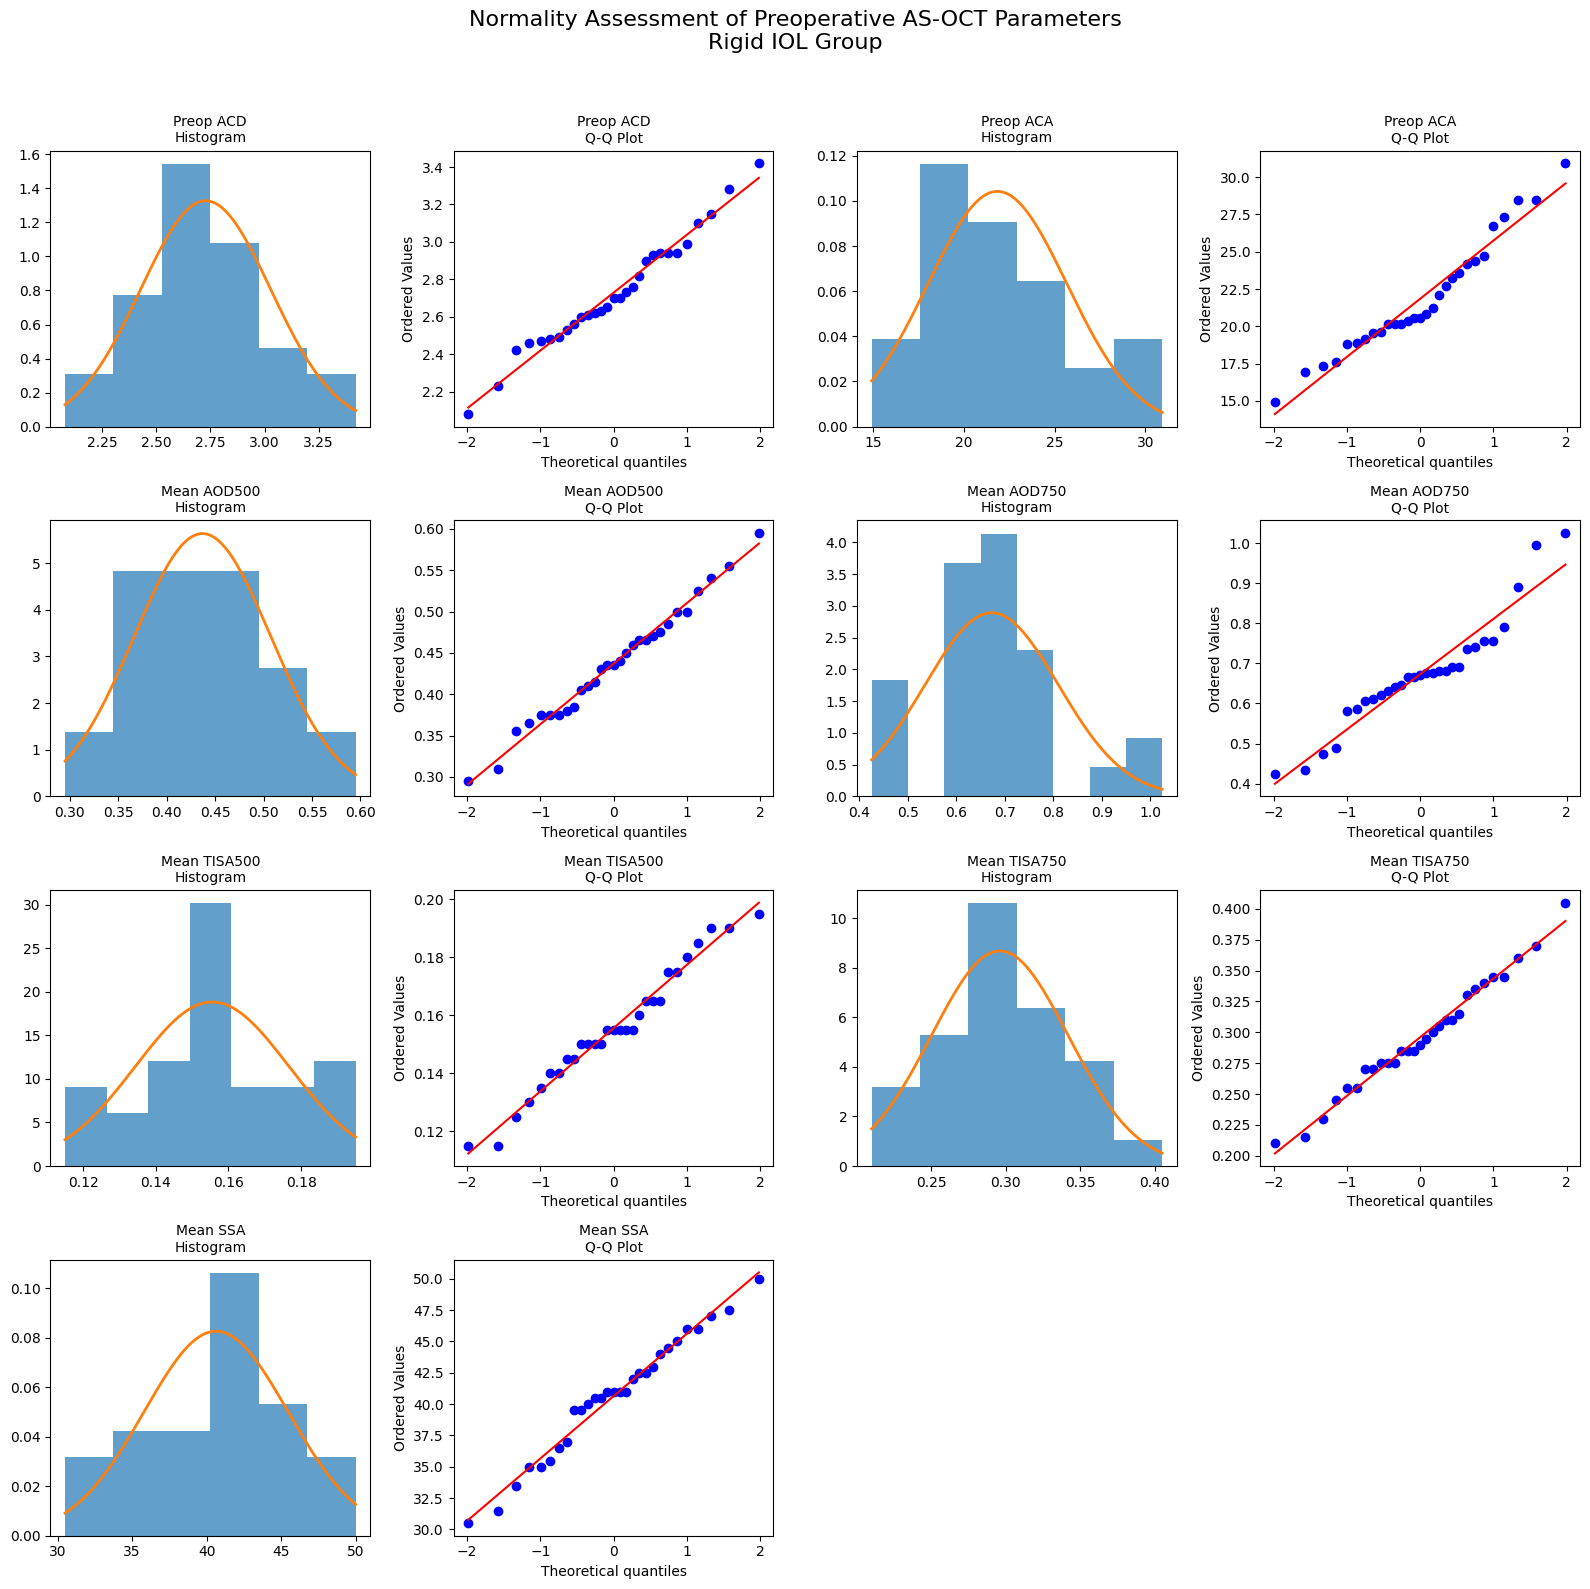

In [273]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, probplot

variables = [
    'ACD',
    'ACA',
    'preop_meanAOD500',
    'preop_meanAOD750',
    'preop_meanTISA500',
    'preop_meanTISA750',
    'preop_meanSSA'

]

titles = [
    'Preop ACD',
    'Preop ACA',
    'Mean AOD500',
    'Mean AOD750',
    'Mean TISA500',
    'Mean TISA750',
    'Mean SSA',

]

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

panel = 0

for var, title in zip(variables, titles):

    data = preop_rigid_df[var].dropna()

    # Histogram + Normal Curve
    axes[panel].hist(data, bins='auto', density=True, alpha=0.7)

    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 200)

    axes[panel].plot(
        x,
        norm.pdf(x, mu, sigma),
        linewidth=2
    )

    axes[panel].set_title(f'{title}\nHistogram', fontsize=10)
    panel += 1

    # QQ Plot
    probplot(data, dist='norm', plot=axes[panel])
    axes[panel].set_title(f'{title}\nQ-Q Plot', fontsize=10)
    panel += 1

# Hide unused panels
for i in range(panel, len(axes)):
    axes[i].axis('off')

plt.suptitle(
    'Normality Assessment of Preoperative AS-OCT Parameters\nRigid IOL Group',
    fontsize=16,
    y=0.99
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(
    'Rigid_Preop_Normality_4x4.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [274]:
from scipy.stats import spearmanr
import pandas as pd

variables = [
    'ACD',
    'ACA',
    'preop_meanAOD500',
    'preop_meanAOD750',
    'preop_meanTISA500',
    'preop_meanTISA750',
    'preop_meanSSA'
]

results = []

for var in variables:

    rho, p = spearmanr(
        preop_rigid_df[var],
        preop_rigid_df['IOP'],
        nan_policy='omit'
    )

    results.append([
        var,
        round(rho, 3),
        round(p, 4)
    ])

spearman_df = pd.DataFrame(
    results,
    columns=['Variable', 'Spearman rho', 'p-value']
)

spearman_df

,Variable,Spearman rho,p-value
0,ACD,-0.140,0.4702
1,ACA,-0.003,0.9858
2,preop_meanAOD500,-0.039,0.8425
3,preop_meanAOD750,-0.122,0.5273
4,preop_meanTISA500,-0.008,0.9690
5,preop_meanTISA750,-0.054,0.7826
6,preop_meanSSA,-0.182,0.3449


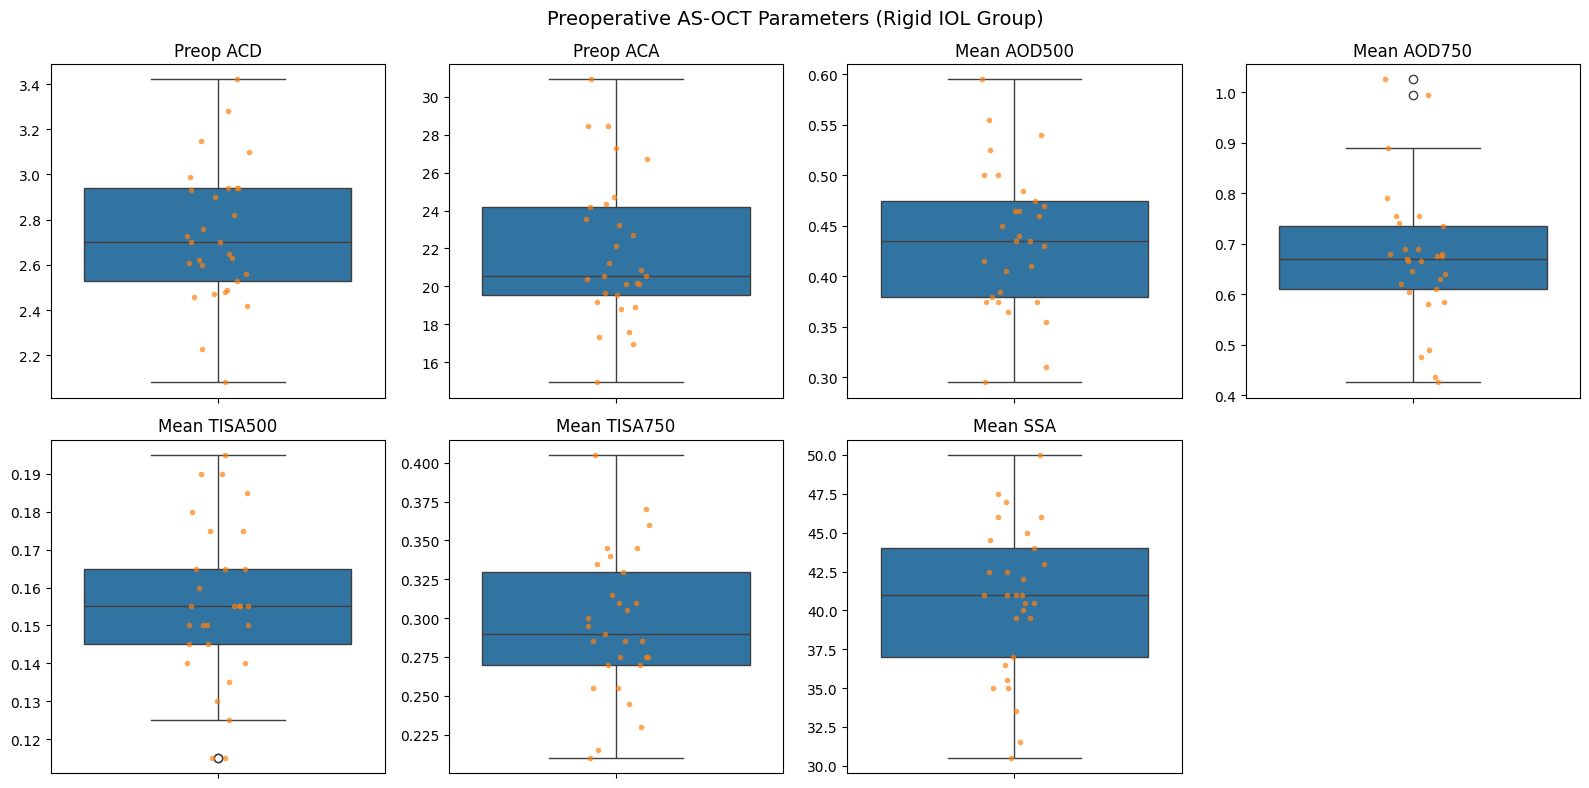

In [275]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, (var, title) in enumerate(zip(variables, titles)):

    sns.boxplot(
        y=preop_rigid_df[var],
        ax=axes[i]
    )

    sns.stripplot(
        y=preop_rigid_df[var],
        ax=axes[i],
        size=4,
        alpha=0.7
    )

    axes[i].set_title(title)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

axes[7].axis('off')

plt.suptitle(
    'Preoperative AS-OCT Parameters (Rigid IOL Group)',
    fontsize=14
)

plt.tight_layout()
plt.show()

## Rigid pod1 analysis



In [276]:
pod1_rigid.shape, pod1_rigid.columns

((25, 22),
 Index(['Name', 'Age-R', 'Sex-R', 'Laterality-R', 'Cataract grading-R ',
        'Preop VA snellen-R ', 'IOP', 'ACD', 'LV', 'CCT', 'ACA', 'ATA',
        'AOD_T500', 'AOD_T750', 'TISA_T500', 'TISA_T750', 'SSA_T',
        'AOD POD1 N 500-R ', 'AOD POD1 N 750-R  ', 'TISA POD1 N 500-R ',
        'TISA POD1 N 750-R ', 'SSA_N'],
       dtype='object'))

In [277]:
pod1_rigid_df = pod1_rigid[[
    'ACD', 'ACA',
    'AOD_T500', 'AOD POD1 N 500-R ',
    'AOD_T750', 'AOD POD1 N 750-R  ',
    'TISA_T500', 'TISA POD1 N 500-R ',
    'TISA_T750', 'TISA POD1 N 750-R ',
    'SSA_T','SSA_N',
    'ATA', 'LV', 'CCT', 'IOP'
]]

In [278]:
pod1_rigid_df['pod1_meanAOD500'] = (pod1_rigid['AOD_T500'] + pod1_rigid['AOD POD1 N 500-R '])/2

pod1_rigid_df['pod1_meanAOD750'] = (pod1_rigid['AOD_T750'] + pod1_rigid['AOD POD1 N 750-R  '])/2

pod1_rigid_df['pod1_meanTISA500'] = (pod1_rigid['TISA_T500'] + pod1_rigid['TISA POD1 N 500-R '])/2

pod1_rigid_df['pod1_meanTISA750'] = (pod1_rigid['TISA_T750'] + pod1_rigid['TISA POD1 N 750-R '])/2

pod1_rigid_df['pod1_meanSSA'] = (pod1_rigid['SSA_T'] + pod1_rigid['SSA_N'])/2

/tmp/ipykernel_905/588638811.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pod1_rigid_df['pod1_meanAOD500'] = (pod1_rigid['AOD_T500'] + pod1_rigid['AOD POD1 N 500-R '])/2
/tmp/ipykernel_905/588638811.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pod1_rigid_df['pod1_meanAOD750'] = (pod1_rigid['AOD_T750'] + pod1_rigid['AOD POD1 N 750-R  '])/2
/tmp/ipykernel_905/588638811.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col

In [279]:
pod1_rigid_df.columns

Index(['ACD', 'ACA', 'AOD_T500', 'AOD POD1 N 500-R ', 'AOD_T750',
       'AOD POD1 N 750-R  ', 'TISA_T500', 'TISA POD1 N 500-R ', 'TISA_T750',
       'TISA POD1 N 750-R ', 'SSA_T', 'SSA_N', 'ATA', 'LV', 'CCT', 'IOP',
       'pod1_meanAOD500', 'pod1_meanAOD750', 'pod1_meanTISA500',
       'pod1_meanTISA750', 'pod1_meanSSA'],
      dtype='object')

In [280]:
import pandas as pd
from scipy.stats import shapiro

variables = [
    'ACD',
    'ACA',
    'pod1_meanAOD500',
    'pod1_meanAOD750',
    'pod1_meanTISA500',
    'pod1_meanTISA750',
    'pod1_meanSSA'
]

results = []

for var in variables:

    data = pod1_rigid_df[var].dropna()

    W, p = shapiro(data)

    results.append([
        var,
        f"{data.count():.2f}",
        f"{data.mean():.2f} ± {data.std():.2f}",
        f"{data.median():.2f} ({data.quantile(0.25):.2f}–{data.quantile(0.75):.2f})",
        round(data.min(), 2),
        round(data.max(), 2),
        round(W, 3),
        round(p, 3)
    ])

desc_table = pd.DataFrame(
    results,
    columns=[
        'Variable',
        'Count',
        'Mean ± SD',
        'Median (IQR)',
        'Minimum',
        'Maximum',
        'Shapiro-Wilk W',
        'p-value'
    ]
)

desc_table

,Variable,Count,Mean ± SD,Median (IQR),Minimum,Maximum,Shapiro-Wilk W,p-value
0,ACD,25.00,3.97 ± 0.28,3.96 (3.80–4.23),3.30,4.42,0.961,0.432
1,ACA,25.00,27.43 ± 2.46,27.54 (26.27–29.49),22.87,32.56,0.968,0.605
2,pod1_meanAOD500,25.00,0.59 ± 0.08,0.57 (0.55–0.65),0.43,0.74,0.962,0.466
3,pod1_meanAOD750,25.00,0.86 ± 0.09,0.85 (0.81–0.92),0.68,1.01,0.960,0.421
4,pod1_meanTISA500,25.00,0.19 ± 0.02,0.19 (0.18–0.20),0.16,0.23,0.945,0.193
5,pod1_meanTISA750,25.00,0.38 ± 0.04,0.36 (0.35–0.40),0.30,0.48,0.977,0.814
6,pod1_meanSSA,25.00,48.82 ± 3.26,48.50 (47.00–51.00),40.00,55.00,0.974,0.757


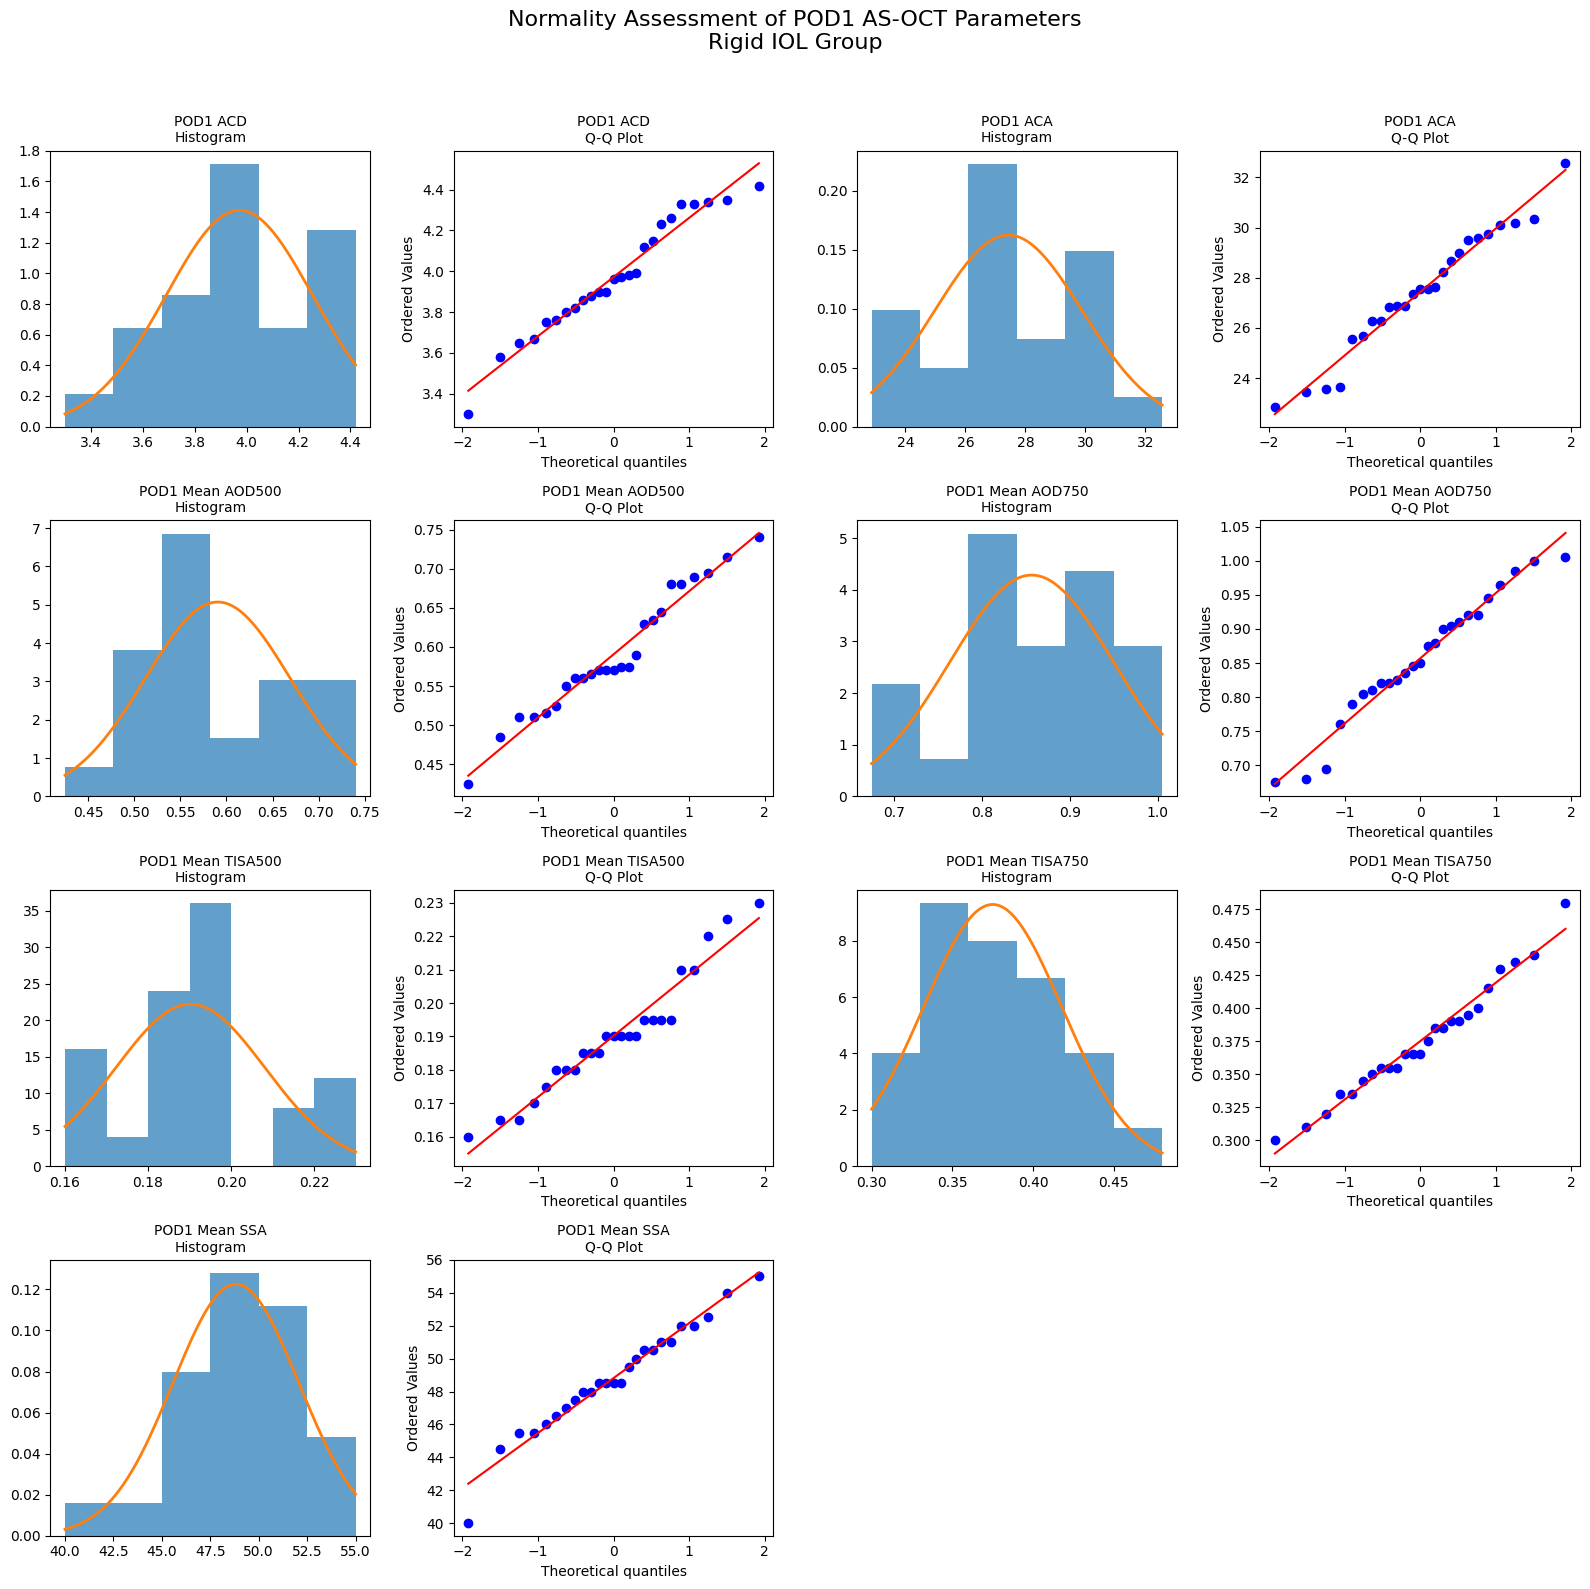

In [281]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, probplot

variables = [
    'ACD',
    'ACA',
    'pod1_meanAOD500',
    'pod1_meanAOD750',
    'pod1_meanTISA500',
    'pod1_meanTISA750',
    'pod1_meanSSA'

]

titles = [
    'POD1 ACD',
    'POD1 ACA',
    'POD1 Mean AOD500',
    'POD1 Mean AOD750',
    'POD1 Mean TISA500',
    'POD1 Mean TISA750',
    'POD1 Mean SSA',

]

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

panel = 0

for var, title in zip(variables, titles):

    data = pod1_rigid_df[var].dropna()

    # Histogram + Normal Curve
    axes[panel].hist(data, bins='auto', density=True, alpha=0.7)

    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 200)

    axes[panel].plot(
        x,
        norm.pdf(x, mu, sigma),
        linewidth=2
    )

    axes[panel].set_title(f'{title}\nHistogram', fontsize=10)
    panel += 1

    # QQ Plot
    probplot(data, dist='norm', plot=axes[panel])
    axes[panel].set_title(f'{title}\nQ-Q Plot', fontsize=10)
    panel += 1

# Hide unused panels
for i in range(panel, len(axes)):
    axes[i].axis('off')

plt.suptitle(
    'Normality Assessment of POD1 AS-OCT Parameters\nRigid IOL Group',
    fontsize=16,
    y=0.99
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(
    'Rigid_POD1_Normality_4x4.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [282]:
from scipy.stats import spearmanr
import pandas as pd

variables = [
    'ACD',
    'ACA',
    'pod1_meanAOD500',
    'pod1_meanAOD750',
    'pod1_meanTISA500',
    'pod1_meanTISA750',
    'pod1_meanSSA'
]

results = []

for var in variables:

    rho, p = spearmanr(
        pod1_rigid_df[var],
        pod1_rigid_df['IOP'],
        nan_policy='omit'
    )

    results.append([
        var,
        round(rho, 3),
        round(p, 4)
    ])

spearman_df = pd.DataFrame(
    results,
    columns=['Variable', 'Spearman rho', 'p-value']
)

spearman_df

,Variable,Spearman rho,p-value
0,ACD,-0.020,0.9234
1,ACA,-0.045,0.8310
2,pod1_meanAOD500,0.224,0.2814
3,pod1_meanAOD750,0.167,0.4263
4,pod1_meanTISA500,0.101,0.6324
5,pod1_meanTISA750,0.212,0.3089
6,pod1_meanSSA,0.115,0.5830


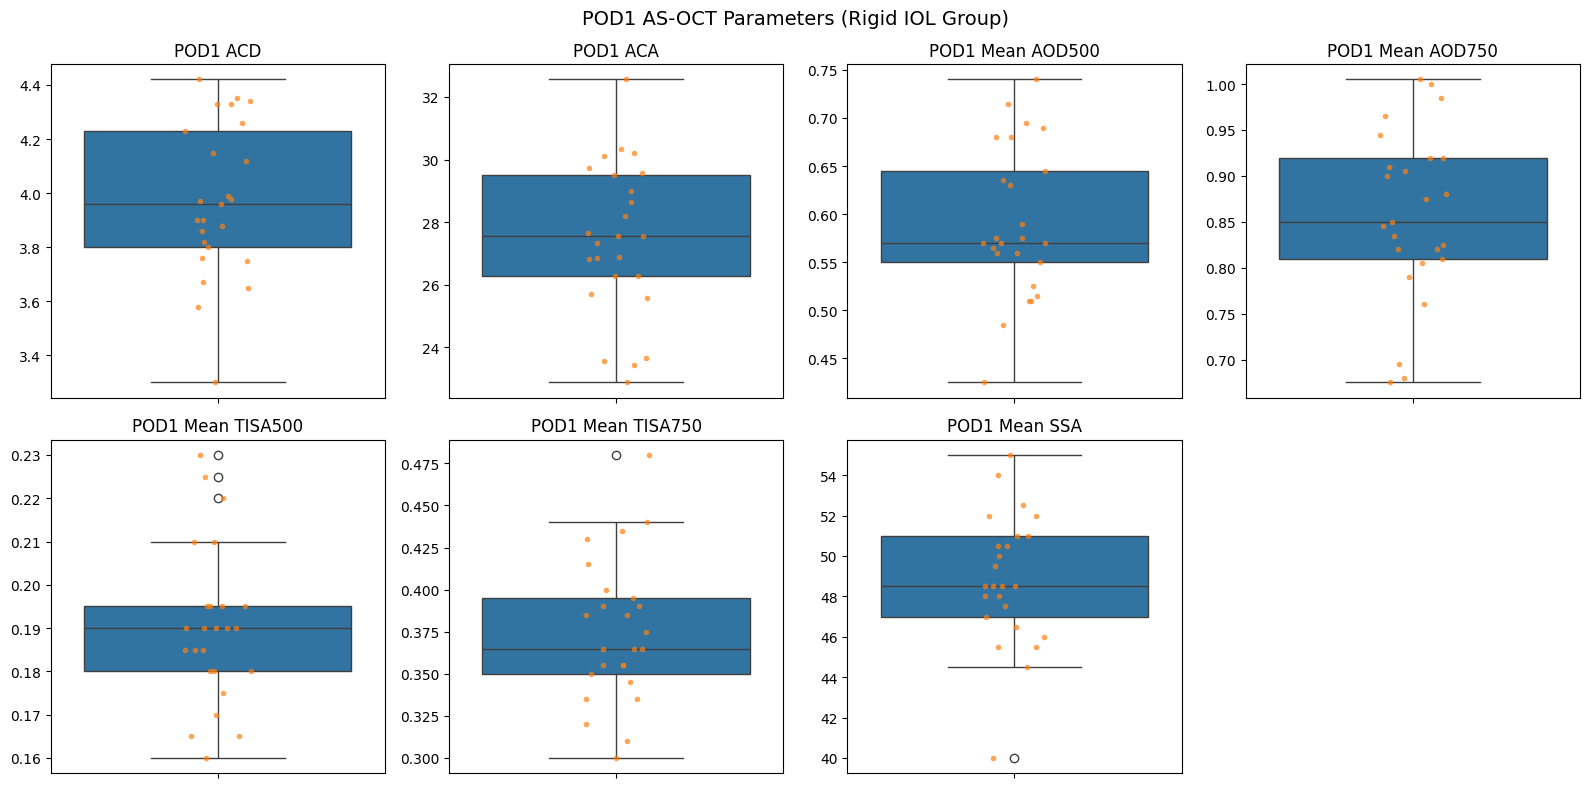

In [283]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, (var, title) in enumerate(zip(variables, titles)):

    sns.boxplot(
        y=pod1_rigid_df[var],
        ax=axes[i]
    )

    sns.stripplot(
        y=pod1_rigid_df[var],
        ax=axes[i],
        size=4,
        alpha=0.7
    )

    axes[i].set_title(title)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

axes[7].axis('off')

plt.suptitle(
    'POD1 AS-OCT Parameters (Rigid IOL Group)',
    fontsize=14
)

plt.tight_layout()
plt.show()

## Rigid POD 6 weeks analysis

In [284]:
pod6wk_rigid.columns, pod6wk_rigid.shape

(Index(['Name', 'Age-R', 'Sex-R', 'Laterality-R', 'Cataract grading-R ', 'IOP',
        'ACD', 'LV', 'CCT', 'ACA', 'ATA', 'AOD_N500', 'AOD_N750', 'TISA_N500',
        'TISA_N750', 'SSA_N', 'AOD_T500', 'AOD_T750', 'TISA_T500', 'TISA_T750',
        'SSA_T'],
       dtype='object'),
 (21, 21))

In [285]:
pod6wk_rigid_df = pod6wk_rigid[[
    'ACD', 'ACA',
    'AOD_T500', 'AOD_N500',
    'AOD_T750', 'AOD_N750',
    'TISA_T500', 'TISA_N500',
    'TISA_T750', 'TISA_N750',
    'SSA_T','SSA_N',
    'ATA', 'LV', 'CCT', 'IOP'
]]

In [286]:
pod6wk_rigid_df['pod6wk_meanAOD500'] = (pod6wk_rigid['AOD_T500'] + pod6wk_rigid['AOD_N500'])/2

pod6wk_rigid_df['pod6wk_meanAOD750'] = (pod6wk_rigid['AOD_T750'] + pod6wk_rigid['AOD_N750'])/2

pod6wk_rigid_df['pod6wk_meanTISA500'] = (pod6wk_rigid['TISA_T500'] + pod6wk_rigid['TISA_N500'])/2

pod6wk_rigid_df['pod6wk_meanTISA750'] = (pod6wk_rigid['TISA_T750'] + pod6wk_rigid['TISA_N750'])/2

pod6wk_rigid_df['pod6wk_meanSSA'] = (pod6wk_rigid['SSA_T'] + pod6wk_rigid['SSA_N'])/2


/tmp/ipykernel_905/4253272442.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pod6wk_rigid_df['pod6wk_meanAOD500'] = (pod6wk_rigid['AOD_T500'] + pod6wk_rigid['AOD_N500'])/2
/tmp/ipykernel_905/4253272442.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pod6wk_rigid_df['pod6wk_meanAOD750'] = (pod6wk_rigid['AOD_T750'] + pod6wk_rigid['AOD_N750'])/2
/tmp/ipykernel_905/4253272442.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col

In [287]:
import pandas as pd
from scipy.stats import shapiro

variables = [
    'ACD',
    'ACA',
    'pod6wk_meanAOD500',
    'pod6wk_meanAOD750',
    'pod6wk_meanTISA500',
    'pod6wk_meanTISA750',
    'pod6wk_meanSSA'
]

results = []

for var in variables:

    data = pod6wk_rigid_df[var].dropna()

    W, p = shapiro(data)

    results.append([
        var,
        f"{data.count():.2f}",
        f"{data.mean():.2f} ± {data.std():.2f}",
        f"{data.median():.2f} ({data.quantile(0.25):.2f}–{data.quantile(0.75):.2f})",
        round(data.min(), 2),
        round(data.max(), 2),
        round(W, 3),
        round(p, 3)
    ])

desc_table = pd.DataFrame(
    results,
    columns=[
        'Variable',
        'Count',
        'Mean ± SD',
        'Median (IQR)',
        'Minimum',
        'Maximum',
        'Shapiro-Wilk W',
        'p-value'
    ]
)

desc_table

,Variable,Count,Mean ± SD,Median (IQR),Minimum,Maximum,Shapiro-Wilk W,p-value
0,ACD,21.00,3.74 ± 0.24,3.70 (3.63–3.83),3.23,4.28,0.975,0.836
1,ACA,21.00,26.28 ± 2.90,26.13 (24.65–27.67),19.07,34.17,0.928,0.125
2,pod6wk_meanAOD500,21.00,0.51 ± 0.06,0.51 (0.48–0.54),0.40,0.63,0.986,0.987
3,pod6wk_meanAOD750,21.00,0.74 ± 0.08,0.74 (0.70–0.80),0.55,0.85,0.921,0.089
4,pod6wk_meanTISA500,21.00,0.17 ± 0.02,0.17 (0.17–0.18),0.15,0.21,0.927,0.119
5,pod6wk_meanTISA750,21.00,0.32 ± 0.03,0.32 (0.29–0.33),0.27,0.39,0.948,0.314
6,pod6wk_meanSSA,21.00,45.02 ± 3.69,45.00 (43.00–47.50),38.50,52.00,0.974,0.812


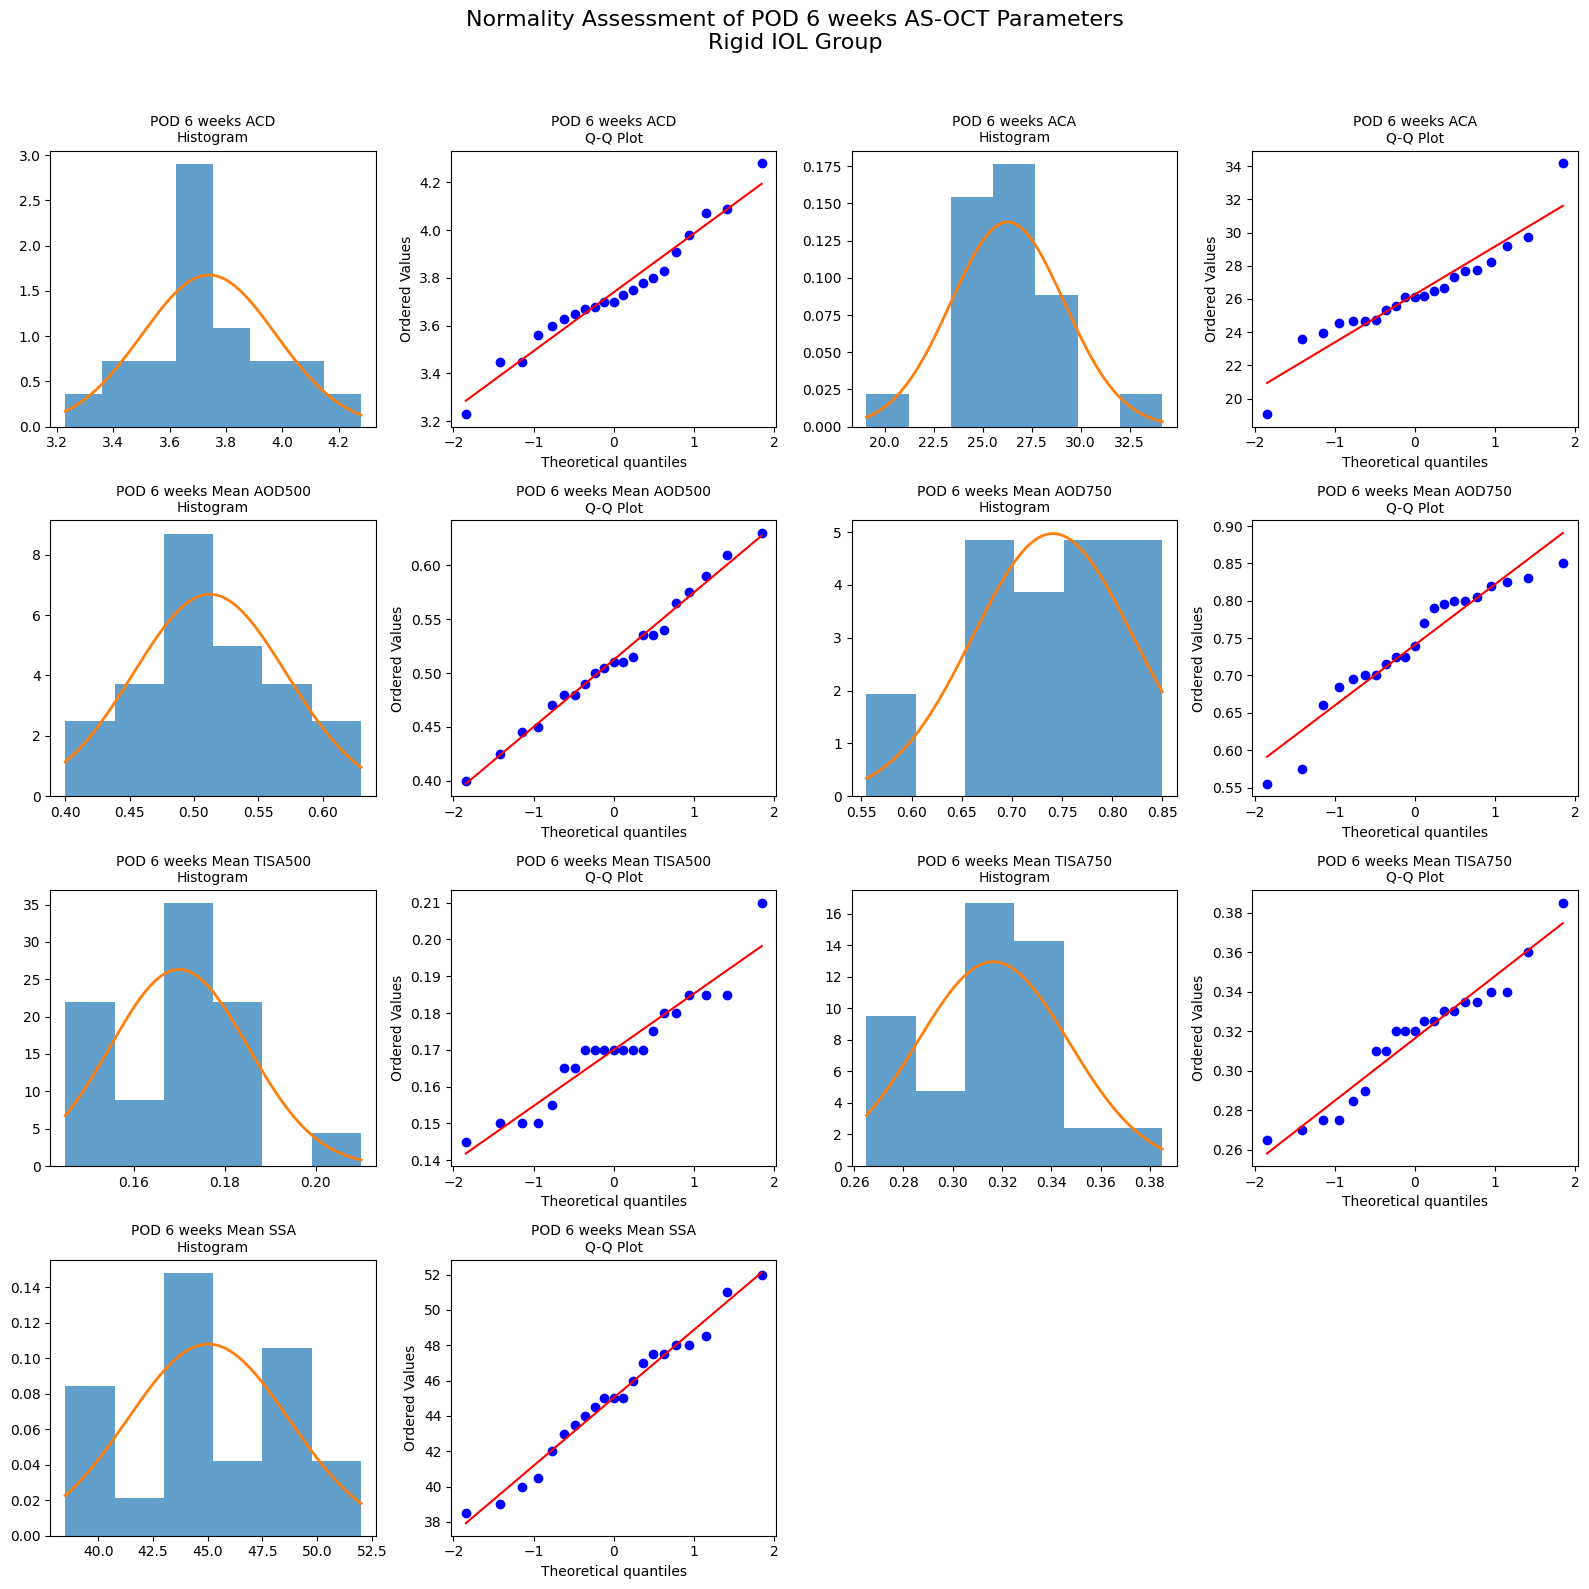

In [288]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, probplot

variables = [
    'ACD',
    'ACA',
    'pod6wk_meanAOD500',
    'pod6wk_meanAOD750',
    'pod6wk_meanTISA500',
    'pod6wk_meanTISA750',
    'pod6wk_meanSSA'

]

titles = [
    'POD 6 weeks ACD',
    'POD 6 weeks ACA',
    'POD 6 weeks Mean AOD500',
    'POD 6 weeks Mean AOD750',
    'POD 6 weeks Mean TISA500',
    'POD 6 weeks Mean TISA750',
    'POD 6 weeks Mean SSA',

]

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

panel = 0

for var, title in zip(variables, titles):

    data = pod6wk_rigid_df[var].dropna()

    # Histogram + Normal Curve
    axes[panel].hist(data, bins='auto', density=True, alpha=0.7)

    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 200)

    axes[panel].plot(
        x,
        norm.pdf(x, mu, sigma),
        linewidth=2
    )

    axes[panel].set_title(f'{title}\nHistogram', fontsize=10)
    panel += 1

    # QQ Plot
    probplot(data, dist='norm', plot=axes[panel])
    axes[panel].set_title(f'{title}\nQ-Q Plot', fontsize=10)
    panel += 1

# Hide unused panels
for i in range(panel, len(axes)):
    axes[i].axis('off')

plt.suptitle(
    'Normality Assessment of POD 6 weeks AS-OCT Parameters\nRigid IOL Group',
    fontsize=16,
    y=0.99
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(
    'Rigid_POD6wk_Normality_4x4.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [289]:
from scipy.stats import spearmanr
import pandas as pd

variables = [
    'ACD',
    'ACA',
    'pod6wk_meanAOD500',
    'pod6wk_meanAOD750',
    'pod6wk_meanTISA500',
    'pod6wk_meanTISA750',
    'pod6wk_meanSSA'
]

results = []

for var in variables:

    rho, p = spearmanr(
        pod6wk_rigid_df[var],
        pod6wk_rigid_df['IOP'],
        nan_policy='omit'
    )

    results.append([
        var,
        round(rho, 3),
        round(p, 4)
    ])

spearman_df = pd.DataFrame(
    results,
    columns=['Variable', 'Spearman rho', 'p-value']
)

spearman_df

,Variable,Spearman rho,p-value
0,ACD,0.239,0.2965
1,ACA,0.206,0.3699
2,pod6wk_meanAOD500,0.105,0.6510
3,pod6wk_meanAOD750,-0.055,0.8131
4,pod6wk_meanTISA500,0.105,0.6511
5,pod6wk_meanTISA750,0.041,0.8601
6,pod6wk_meanSSA,-0.036,0.8779


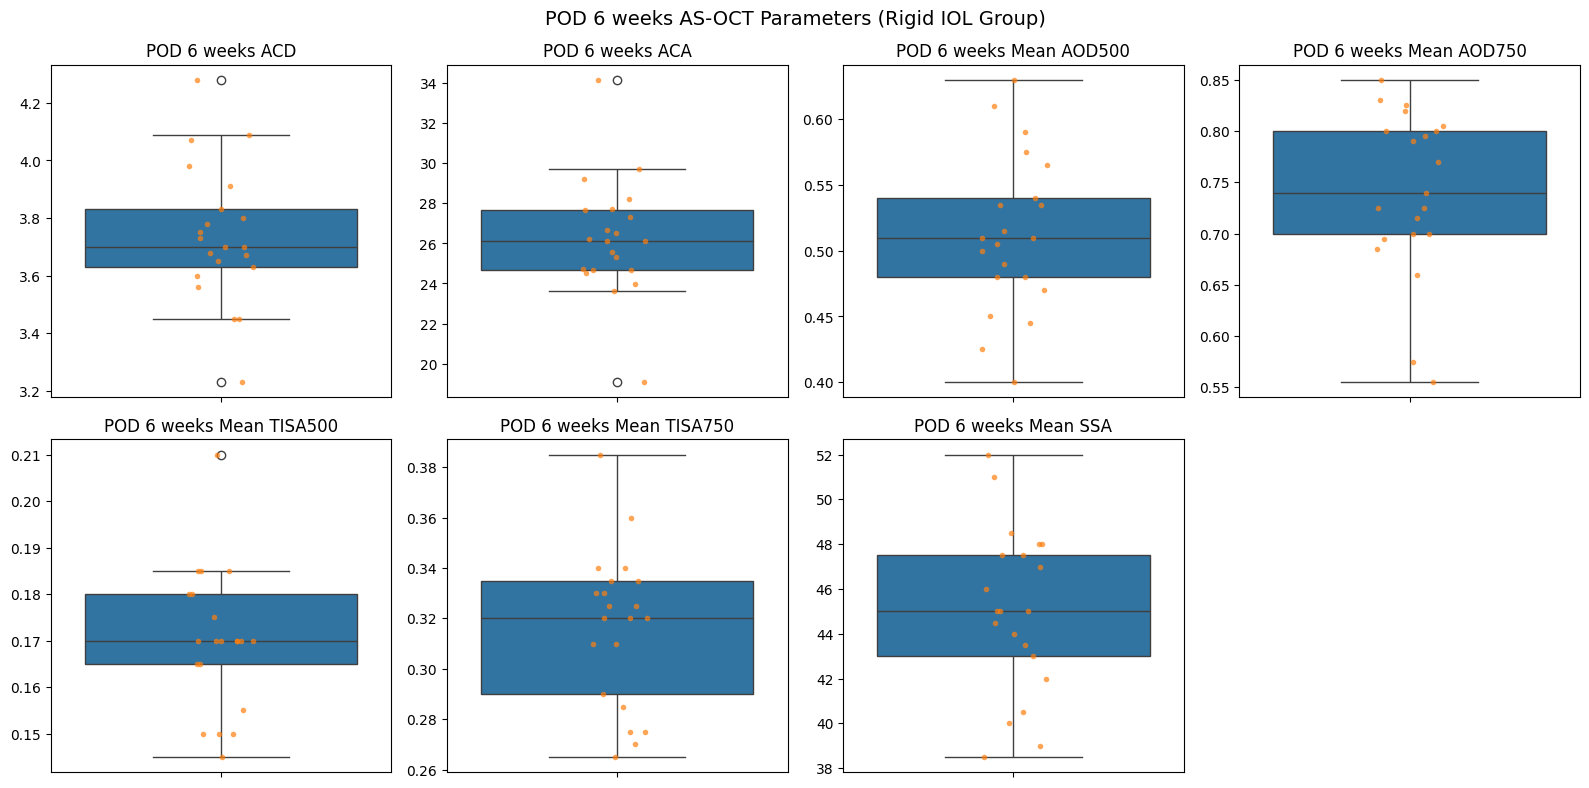

In [290]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, (var, title) in enumerate(zip(variables, titles)):

    sns.boxplot(
        y=pod6wk_rigid_df[var],
        ax=axes[i]
    )

    sns.stripplot(
        y=pod6wk_rigid_df[var],
        ax=axes[i],
        size=4,
        alpha=0.7
    )

    axes[i].set_title(title)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

axes[7].axis('off')

plt.suptitle(
    'POD 6 weeks AS-OCT Parameters (Rigid IOL Group)',
    fontsize=14
)

plt.tight_layout()
plt.show()

## Rigid 3 months analysis

In [291]:
pod3mth_rigid.shape, pod3mth_rigid.columns

((9, 21),
 Index(['Name', 'Age-R', 'Sex-R', 'Laterality-R', 'Cataract grading-R ', 'IOP',
        'ACD', 'LV', 'CCT', 'ACA', 'ATA', 'AOD_N500', 'AOD_N750', 'TISA_N500',
        'TISA_N750', 'SSA_N', 'AOD_T500', 'AOD_T750', 'TISA_T500', 'TISA_T750',
        'SSA_T'],
       dtype='object'))

In [292]:
pod3mth_rigid_df = pod3mth_rigid[[
    'ACD', 'ACA',
    'AOD_T500', 'AOD_N500',
    'AOD_T750', 'AOD_N750',
    'TISA_T500', 'TISA_N500',
    'TISA_T750', 'TISA_N750',
    'SSA_T','SSA_N',
    'ATA', 'LV', 'CCT', 'IOP'
]]

In [293]:
pod3mth_rigid_df['pod3mth_meanAOD500'] = (pod3mth_rigid['AOD_T500'] + pod3mth_rigid['AOD_N500'])/2

pod3mth_rigid_df['pod3mth_meanAOD750'] = (pod3mth_rigid['AOD_T750'] + pod3mth_rigid['AOD_N750'])/2

pod3mth_rigid_df['pod3mth_meanTISA500'] = (pod3mth_rigid['TISA_T500'] + pod3mth_rigid['TISA_N500'])/2

pod3mth_rigid_df['pod3mth_meanTISA750'] = (pod3mth_rigid['TISA_T750'] + pod3mth_rigid['TISA_N750'])/2

pod3mth_rigid_df['pod3mth_meanSSA'] = (pod3mth_rigid['SSA_T'] + pod3mth_rigid['SSA_N'])/2


/tmp/ipykernel_905/3211462375.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pod3mth_rigid_df['pod3mth_meanAOD500'] = (pod3mth_rigid['AOD_T500'] + pod3mth_rigid['AOD_N500'])/2
/tmp/ipykernel_905/3211462375.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pod3mth_rigid_df['pod3mth_meanAOD750'] = (pod3mth_rigid['AOD_T750'] + pod3mth_rigid['AOD_N750'])/2
/tmp/ipykernel_905/3211462375.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_ind

In [294]:
import pandas as pd
from scipy.stats import shapiro

variables = [
    'ACD',
    'ACA',
    'pod3mth_meanAOD500',
    'pod3mth_meanAOD750',
    'pod3mth_meanTISA500',
    'pod3mth_meanTISA750',
    'pod3mth_meanSSA'
]

results = []

for var in variables:

    data = pod3mth_rigid_df[var].dropna()

    W, p = shapiro(data)

    results.append([
        var,
        f"{data.count():.2f}",
        f"{data.mean():.2f} ± {data.std():.2f}",
        f"{data.median():.2f} ({data.quantile(0.25):.2f}–{data.quantile(0.75):.2f})",
        round(data.min(), 2),
        round(data.max(), 2),
        round(W, 3),
        round(p, 3)
    ])

desc_table = pd.DataFrame(
    results,
    columns=[
        'Variable',
        'Count',
        'Mean ± SD',
        'Median (IQR)',
        'Minimum',
        'Maximum',
        'Shapiro-Wilk W',
        'p-value'
    ]
)

desc_table

,Variable,Count,Mean ± SD,Median (IQR),Minimum,Maximum,Shapiro-Wilk W,p-value
0,ACD,9.00,3.63 ± 0.41,3.60 (3.35–3.87),2.90,4.20,0.969,0.890
1,ACA,9.00,23.93 ± 2.94,23.96 (22.40–25.56),19.01,29.54,0.966,0.859
2,pod3mth_meanAOD500,9.00,0.52 ± 0.07,0.53 (0.50–0.57),0.38,0.62,0.927,0.450
3,pod3mth_meanAOD750,9.00,0.77 ± 0.10,0.78 (0.68–0.81),0.63,0.93,0.938,0.560
4,pod3mth_meanTISA500,9.00,0.17 ± 0.02,0.17 (0.17–0.17),0.12,0.20,0.848,0.071
5,pod3mth_meanTISA750,9.00,0.31 ± 0.04,0.30 (0.28–0.34),0.26,0.39,0.955,0.746
6,pod3mth_meanSSA,9.00,45.22 ± 3.51,46.00 (45.00–47.00),37.00,49.50,0.840,0.058


In [295]:
from scipy.stats import spearmanr
import pandas as pd

variables = [
    'ACD',
    'ACA',
    'pod3mth_meanAOD500',
    'pod3mth_meanAOD750',
    'pod3mth_meanTISA500',
    'pod3mth_meanTISA750',
    'pod3mth_meanSSA'
]

results = []

for var in variables:

    rho, p = spearmanr(
        pod3mth_rigid_df[var],
        pod3mth_rigid_df['IOP'],
        nan_policy='omit'
    )

    results.append([
        var,
        round(rho, 3),
        round(p, 4)
    ])

spearman_df = pd.DataFrame(
    results,
    columns=['Variable', 'Spearman rho', 'p-value']
)

spearman_df

,Variable,Spearman rho,p-value
0,ACD,-0.244,0.5276
1,ACA,0.165,0.6721
2,pod3mth_meanAOD500,0.161,0.6791
3,pod3mth_meanAOD750,0.139,0.7221
4,pod3mth_meanTISA500,0.274,0.4749
5,pod3mth_meanTISA750,0.182,0.6394
6,pod3mth_meanSSA,0.052,0.8939


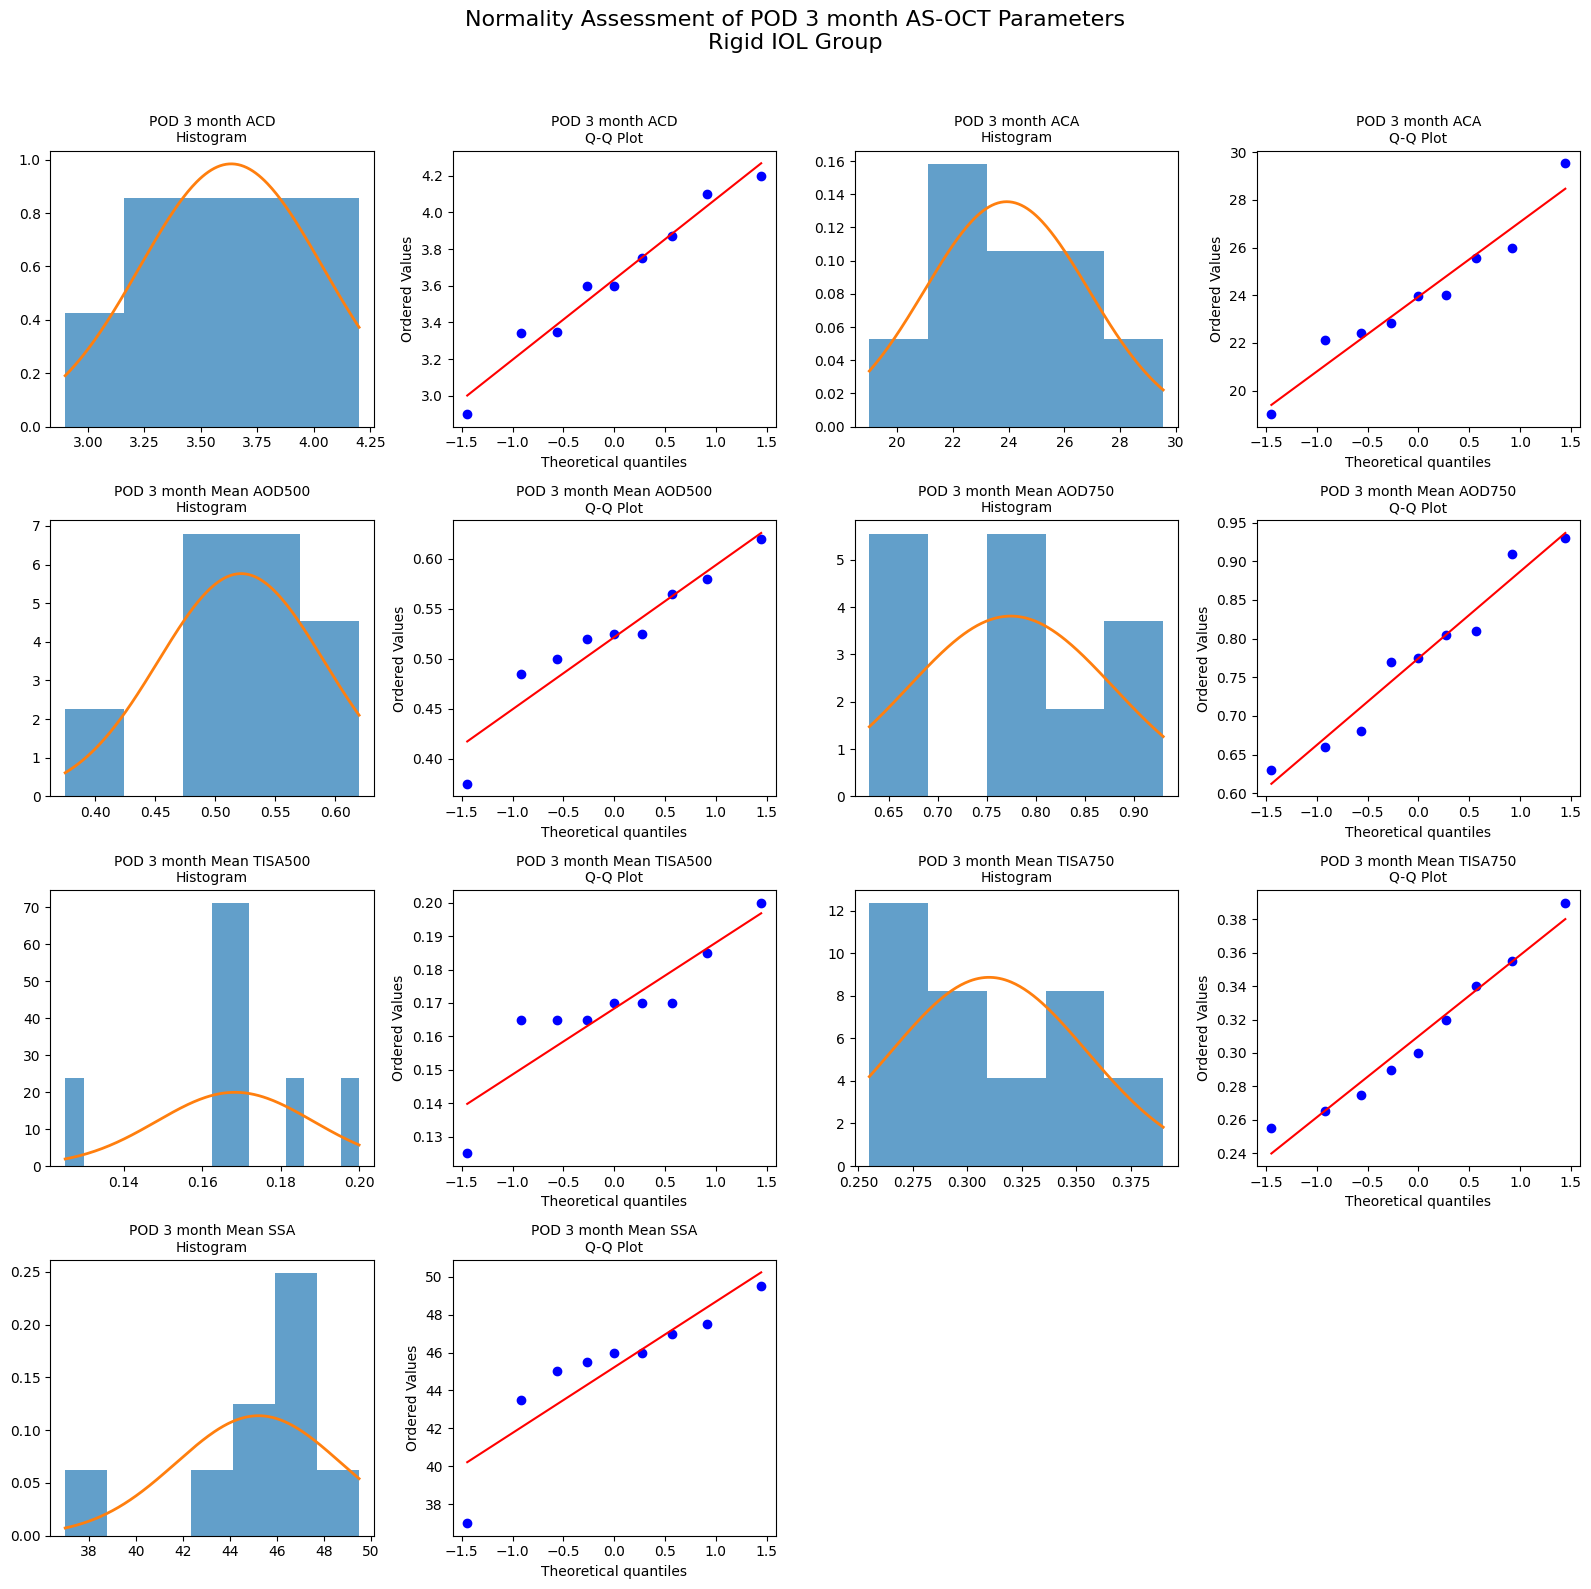

In [296]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, probplot

variables = [
    'ACD',
    'ACA',
    'pod3mth_meanAOD500',
    'pod3mth_meanAOD750',
    'pod3mth_meanTISA500',
    'pod3mth_meanTISA750',
    'pod3mth_meanSSA'

]

titles = [
    'POD 3 month ACD',
    'POD 3 month ACA',
    'POD 3 month Mean AOD500',
    'POD 3 month Mean AOD750',
    'POD 3 month Mean TISA500',
    'POD 3 month Mean TISA750',
    'POD 3 month Mean SSA',

]

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

panel = 0

for var, title in zip(variables, titles):

    data = pod3mth_rigid_df[var].dropna()

    # Histogram + Normal Curve
    axes[panel].hist(data, bins='auto', density=True, alpha=0.7)

    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 200)

    axes[panel].plot(
        x,
        norm.pdf(x, mu, sigma),
        linewidth=2
    )

    axes[panel].set_title(f'{title}\nHistogram', fontsize=10)
    panel += 1

    # QQ Plot
    probplot(data, dist='norm', plot=axes[panel])
    axes[panel].set_title(f'{title}\nQ-Q Plot', fontsize=10)
    panel += 1

# Hide unused panels
for i in range(panel, len(axes)):
    axes[i].axis('off')

plt.suptitle(
    'Normality Assessment of POD 3 month AS-OCT Parameters\nRigid IOL Group',
    fontsize=16,
    y=0.99
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(
    'Rigid_POD3mth_Normality_4x4.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

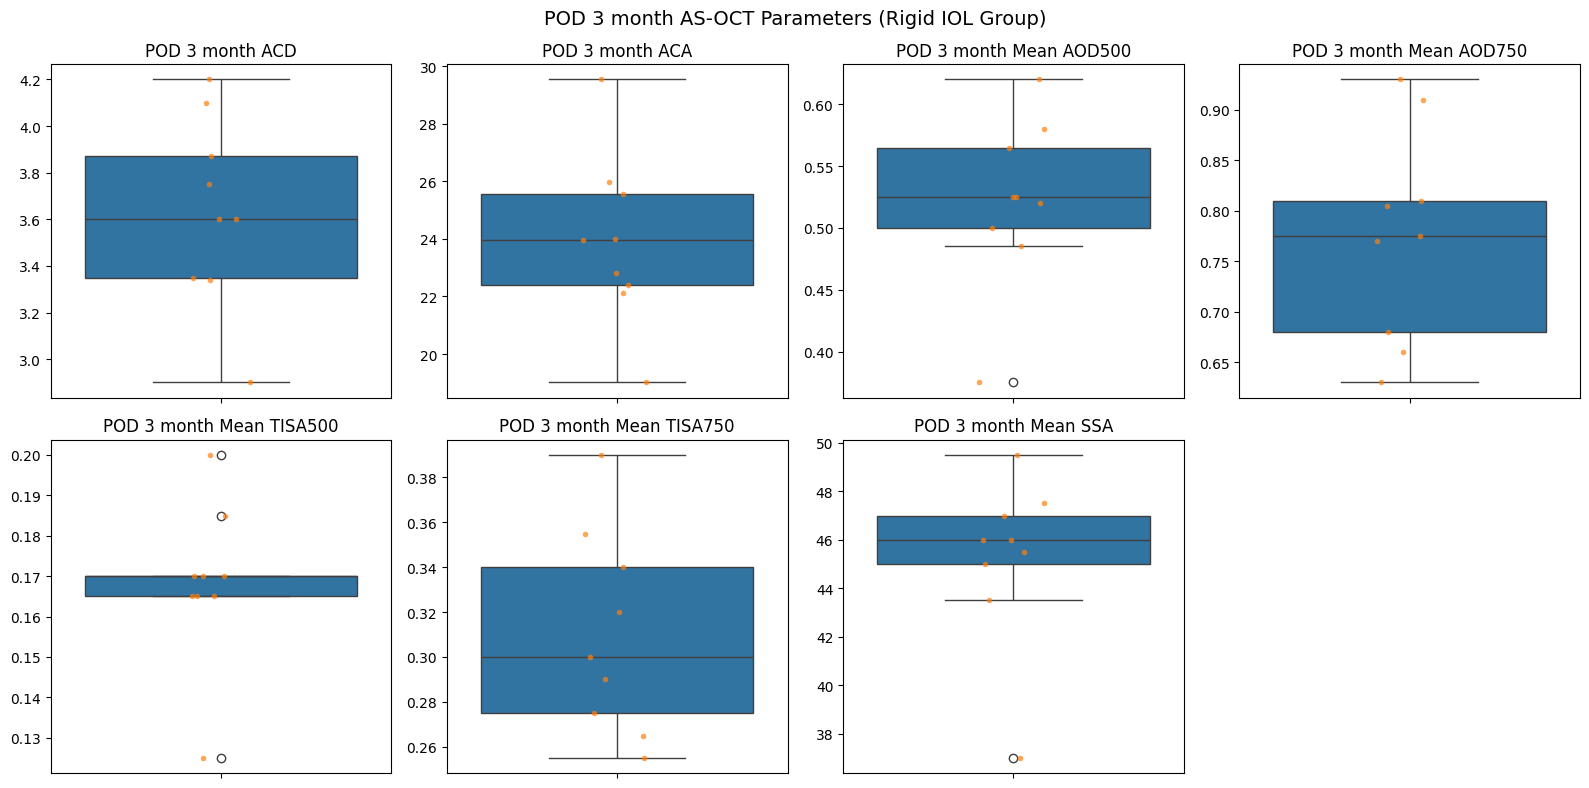

In [297]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, (var, title) in enumerate(zip(variables, titles)):

    sns.boxplot(
        y=pod3mth_rigid_df[var],
        ax=axes[i]
    )

    sns.stripplot(
        y=pod3mth_rigid_df[var],
        ax=axes[i],
        size=4,
        alpha=0.7
    )

    axes[i].set_title(title)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

axes[7].axis('off')

plt.suptitle(
    'POD 3 month AS-OCT Parameters (Rigid IOL Group)',
    fontsize=14
)

plt.tight_layout()
plt.show()

## Foldable IOL analysis

In [298]:
fold_preop = sheets.parse('F preop')
fold_pod1 = sheets.parse('F pod1')
fold_pod6wks = sheets.parse('F pod6wks')
fold_pod3mths = sheets.parse('F pod3mthh')


In [299]:
fold_preop.columns

Index(['Name', 'Age (F)', 'Sex (F) ', 'Cataract grading-F ', 'Laterality (F)',
       'Preop VA (F)', ' preop IOP (F)', 'Preop ACD (F)', 'Preop LV (F)',
       'Preop CCT (F)', 'Preop ACA (F) ', 'Preop ATA (F)',
       'Preop AOD N 500 (F)', 'Preop AOD N 750 (F) ', 'Preop TISA N 500 (F)',
       'Preop TISA N 750 (F)', 'Preop SSA-N (F) ', 'Preop AOD T 500 (F) ',
       'Preop AOD T 750 (F) ', 'Preop TISA T 500 (F) ',
       'Preop TISA T 750 (F) ', 'Preop SSA-T (F) '],
      dtype='object')

In [300]:
fold_preop.shape, fold_pod1.shape, fold_pod6wks.shape, fold_pod3mths.shape

((29, 22), (29, 21), (29, 21), (29, 21))

In [301]:
# Preop
fold_preop = fold_preop.rename(columns={
    'Preop IOP-R':'IOP',
    'Preop ACD-R ':'ACD',
    'Preop LV-R':'LV',
    'Preop CCT-R ':'CCT',
    'Preop ACA-R  ':'ACA',
    'Preop ATA-R ':'ATA',
    'Preop AOD N 500-R ':'AOD_N500',
    'preop AOD N 750-R ':'AOD_N750',
    'Preop TISA N 500-R ':'TISA_N500',
    'Preop TISA N 750-R ':'TISA_N750',
    'Preop SSA-N R ':'SSA_N',
    'Preop AOD T 500-R  ':'AOD_T500',
    'Preop AOD T 750-R ':'AOD_T750',
    'Preop TISAT  500-R  ':'TISA_T500',
    'Preop TISA T 750-R ':'TISA_T750',
    'Preop SSA-T-R':'SSA_T'
})

# POD1
fold_pod1 = fold_pod1.rename(columns={
    'POD1 IOP-R ':'IOP',
    'POD1 ACD-R ':'ACD',
    'POD1 LV-R ':'LV',
    'POD1 CCT-R ':'CCT',
    'POD1 ACA-R  ':'ACA',
    'POD1 ATA-R':'ATA',
    'AOD T POD1 500-R':'AOD_T500',
    'AOD T POD1 750-R ':'AOD_T750',
    'TISA T POD1 500-R ':'TISA_T500',
    'TISA T 750 POD1-R':'TISA_T750',
    'SSA-T POD1-R ':'SSA_T',
    'AOD N POD1 500-R ':'AOD_N500',
    'AOD N POD1 750-R ':'AOD_N750',
    'TISA N POD1 500-R ':'TISA_N500',
    'TISA N POD1 750-R ':'TISA_N750',
    'SSA-N POD1-R ':'SSA_N'


})

# POD6wk
fold_pod6wk = fold_pod6wks.rename(columns={
    'POD6wk IOP-R ':'IOP',
    'ACD 6 wk-R ':'ACD',
    'LV 6 wk-R':'LV',
    'CCT 6 wk-R ':'CCT',
    'ACA POD 6 wk-R ':'ACA',
    'ATA 6 wk-R':'ATA',
    'AOD N 500 6 wk-R ':'AOD_N500',
    'AOD N 750 6 wk-R ':'AOD_N750',
    'TISA N 500 6 wk-R ':'TISA_N500',
    'TISA N 750 6 wk-R ':'TISA_N750',
    'SSA-N 6 wk-R ':'SSA_N',
    'AOD T 500 6 wk-R ':'AOD_T500',
    'AOD T 750 6 wk-R ':'AOD_T750',
    'TISA T 500 6 wk-R ':'TISA_T500',
    'TISA T 750 6 wk-R':'TISA_T750',
    'SSA-T 6 wk-R ':'SSA_T'
})

# POD3mth
fold_pod3mth = fold_pod3mths.rename(columns={
    'POD3 mth IOP -R':'IOP',
    'ACD 3 mth-R':'ACD',
    'LV 3 mth-R':'LV',
    'CCT 3 mth-R':'CCT',
    'ACA 3 mth-R':'ACA',
    'ATA 3 mth-R':'ATA',
    'AOD 500 N 3 mth-R':'AOD_N500',
    'AOD 750 N 3 mth-R':'AOD_N750',
    'TISA 500 N 3 mth-R':'TISA_N500',
    'TISA 750 N 3 mth-R':'TISA_N750',
    'SSA N 3 mth-R':'SSA_N',
    'AOD 500 T 3 mth-R':'AOD_T500',
    'AOD 750 T 3 mth-R':'AOD_T750',
    'TISA 500 T 3 mth-R':'TISA_T500',
    'TISA 750 T 3 mth-R':'TISA_T750',
    'SSA T 3 mth-R':'SSA_T'
})

## Foldable preoperative analysis

In [302]:
fold_preop.columns

Index(['Name', 'Age (F)', 'Sex (F) ', 'Cataract grading-F ', 'Laterality (F)',
       'Preop VA (F)', ' preop IOP (F)', 'Preop ACD (F)', 'Preop LV (F)',
       'Preop CCT (F)', 'Preop ACA (F) ', 'Preop ATA (F)',
       'Preop AOD N 500 (F)', 'Preop AOD N 750 (F) ', 'Preop TISA N 500 (F)',
       'Preop TISA N 750 (F)', 'Preop SSA-N (F) ', 'Preop AOD T 500 (F) ',
       'Preop AOD T 750 (F) ', 'Preop TISA T 500 (F) ',
       'Preop TISA T 750 (F) ', 'Preop SSA-T (F) '],
      dtype='object')

In [303]:
fold_preop.isnull().sum()

,0
Name,0
Age (F),0
Sex (F),0
Cataract grading-F,0
Laterality (F),0
Preop VA (F),0
preop IOP (F),0
Preop ACD (F),0
Preop LV (F),0
Preop CCT (F),0


In [304]:
preop_foldable_df = fold_preop[[
   'Preop ACD (F)', 'Preop ACA (F) ',
   'Preop AOD T 500 (F) ','Preop AOD N 500 (F)',
  'Preop AOD T 750 (F) ', 'Preop AOD N 750 (F) ',
  'Preop TISA T 500 (F) ', 'Preop TISA N 500 (F)',
  'Preop TISA T 750 (F) ', 'Preop TISA N 750 (F)',
   'Preop SSA-T (F) ', 'Preop SSA-N (F) ',
    'Preop ATA (F)', 'Preop LV (F)',
   'Preop CCT (F)',' preop IOP (F)'

]]

In [305]:
preop_foldable_df['preop_meanAOD500'] = (fold_preop['Preop AOD T 500 (F) '] + fold_preop['Preop AOD N 500 (F)'])/2

preop_foldable_df['preop_meanAOD750'] = (fold_preop['Preop AOD T 750 (F) '] + fold_preop['Preop AOD N 750 (F) '])/2

preop_foldable_df['preop_meanTISA500'] = (fold_preop['Preop TISA T 500 (F) '] + fold_preop['Preop TISA N 500 (F)'])/2

preop_foldable_df['preop_meanTISA750'] = (fold_preop['Preop TISA T 750 (F) '] + fold_preop['Preop TISA N 750 (F)'])/2

preop_foldable_df['preop_meanSSA'] = (fold_preop['Preop SSA-T (F) '] + fold_preop['Preop SSA-N (F) '])/2


/tmp/ipykernel_905/1776583933.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  preop_foldable_df['preop_meanAOD500'] = (fold_preop['Preop AOD T 500 (F) '] + fold_preop['Preop AOD N 500 (F)'])/2
/tmp/ipykernel_905/1776583933.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  preop_foldable_df['preop_meanAOD750'] = (fold_preop['Preop AOD T 750 (F) '] + fold_preop['Preop AOD N 750 (F) '])/2
/tmp/ipykernel_905/1776583933.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a 

In [306]:
preop_foldable_df.columns

Index(['Preop ACD (F)', 'Preop ACA (F) ', 'Preop AOD T 500 (F) ',
       'Preop AOD N 500 (F)', 'Preop AOD T 750 (F) ', 'Preop AOD N 750 (F) ',
       'Preop TISA T 500 (F) ', 'Preop TISA N 500 (F)',
       'Preop TISA T 750 (F) ', 'Preop TISA N 750 (F)', 'Preop SSA-T (F) ',
       'Preop SSA-N (F) ', 'Preop ATA (F)', 'Preop LV (F)', 'Preop CCT (F)',
       ' preop IOP (F)', 'preop_meanAOD500', 'preop_meanAOD750',
       'preop_meanTISA500', 'preop_meanTISA750', 'preop_meanSSA'],
      dtype='object')

In [307]:
import pandas as pd
from scipy.stats import shapiro

variables = [
    'Preop ACD (F)', 'Preop ACA (F) ',
    'preop_meanAOD500',
    'preop_meanAOD750',
    'preop_meanTISA500',
    'preop_meanTISA750',
    'preop_meanSSA'
]



results = []

for var in variables:

    data = preop_foldable_df[var].dropna()

    W, p = shapiro(data)

    results.append([
        var,
        f"{data.count():.2f}",
        f"{data.mean():.2f} ± {data.std():.2f}",
        f"{data.median():.2f} ({data.quantile(0.25):.2f}–{data.quantile(0.75):.2f})",
        round(data.min(), 2),
        round(data.max(), 2),
        round(W, 3),
        round(p, 3)
    ])

desc_table = pd.DataFrame(
    results,
    columns=[
        'Variable',
        'Count',
        'Mean ± SD',
        'Median (IQR)',
        'Minimum',
        'Maximum',
        'Shapiro-Wilk W',
        'p-value'
    ]
)

desc_table

,Variable,Count,Mean ± SD,Median (IQR),Minimum,Maximum,Shapiro-Wilk W,p-value
0,Preop ACD (F),29.00,2.87 ± 0.37,2.88 (2.48–3.20),2.31,3.50,0.917,0.026
1,Preop ACA (F),29.00,22.14 ± 3.88,22.40 (19.73–23.89),13.89,30.52,0.981,0.867
2,preop_meanAOD500,29.00,0.37 ± 0.07,0.38 (0.32–0.43),0.22,0.53,0.983,0.900
3,preop_meanAOD750,29.00,0.56 ± 0.09,0.56 (0.49–0.60),0.33,0.76,0.986,0.959
4,preop_meanTISA500,29.00,0.14 ± 0.02,0.14 (0.12–0.16),0.10,0.21,0.963,0.389
5,preop_meanTISA750,29.00,0.27 ± 0.05,0.26 (0.23–0.30),0.17,0.38,0.986,0.954
6,preop_meanSSA,29.00,35.47 ± 5.16,34.00 (33.00–39.50),24.50,46.50,0.972,0.613


In [308]:
preop_foldable_df.columns

Index(['Preop ACD (F)', 'Preop ACA (F) ', 'Preop AOD T 500 (F) ',
       'Preop AOD N 500 (F)', 'Preop AOD T 750 (F) ', 'Preop AOD N 750 (F) ',
       'Preop TISA T 500 (F) ', 'Preop TISA N 500 (F)',
       'Preop TISA T 750 (F) ', 'Preop TISA N 750 (F)', 'Preop SSA-T (F) ',
       'Preop SSA-N (F) ', 'Preop ATA (F)', 'Preop LV (F)', 'Preop CCT (F)',
       ' preop IOP (F)', 'preop_meanAOD500', 'preop_meanAOD750',
       'preop_meanTISA500', 'preop_meanTISA750', 'preop_meanSSA'],
      dtype='object')

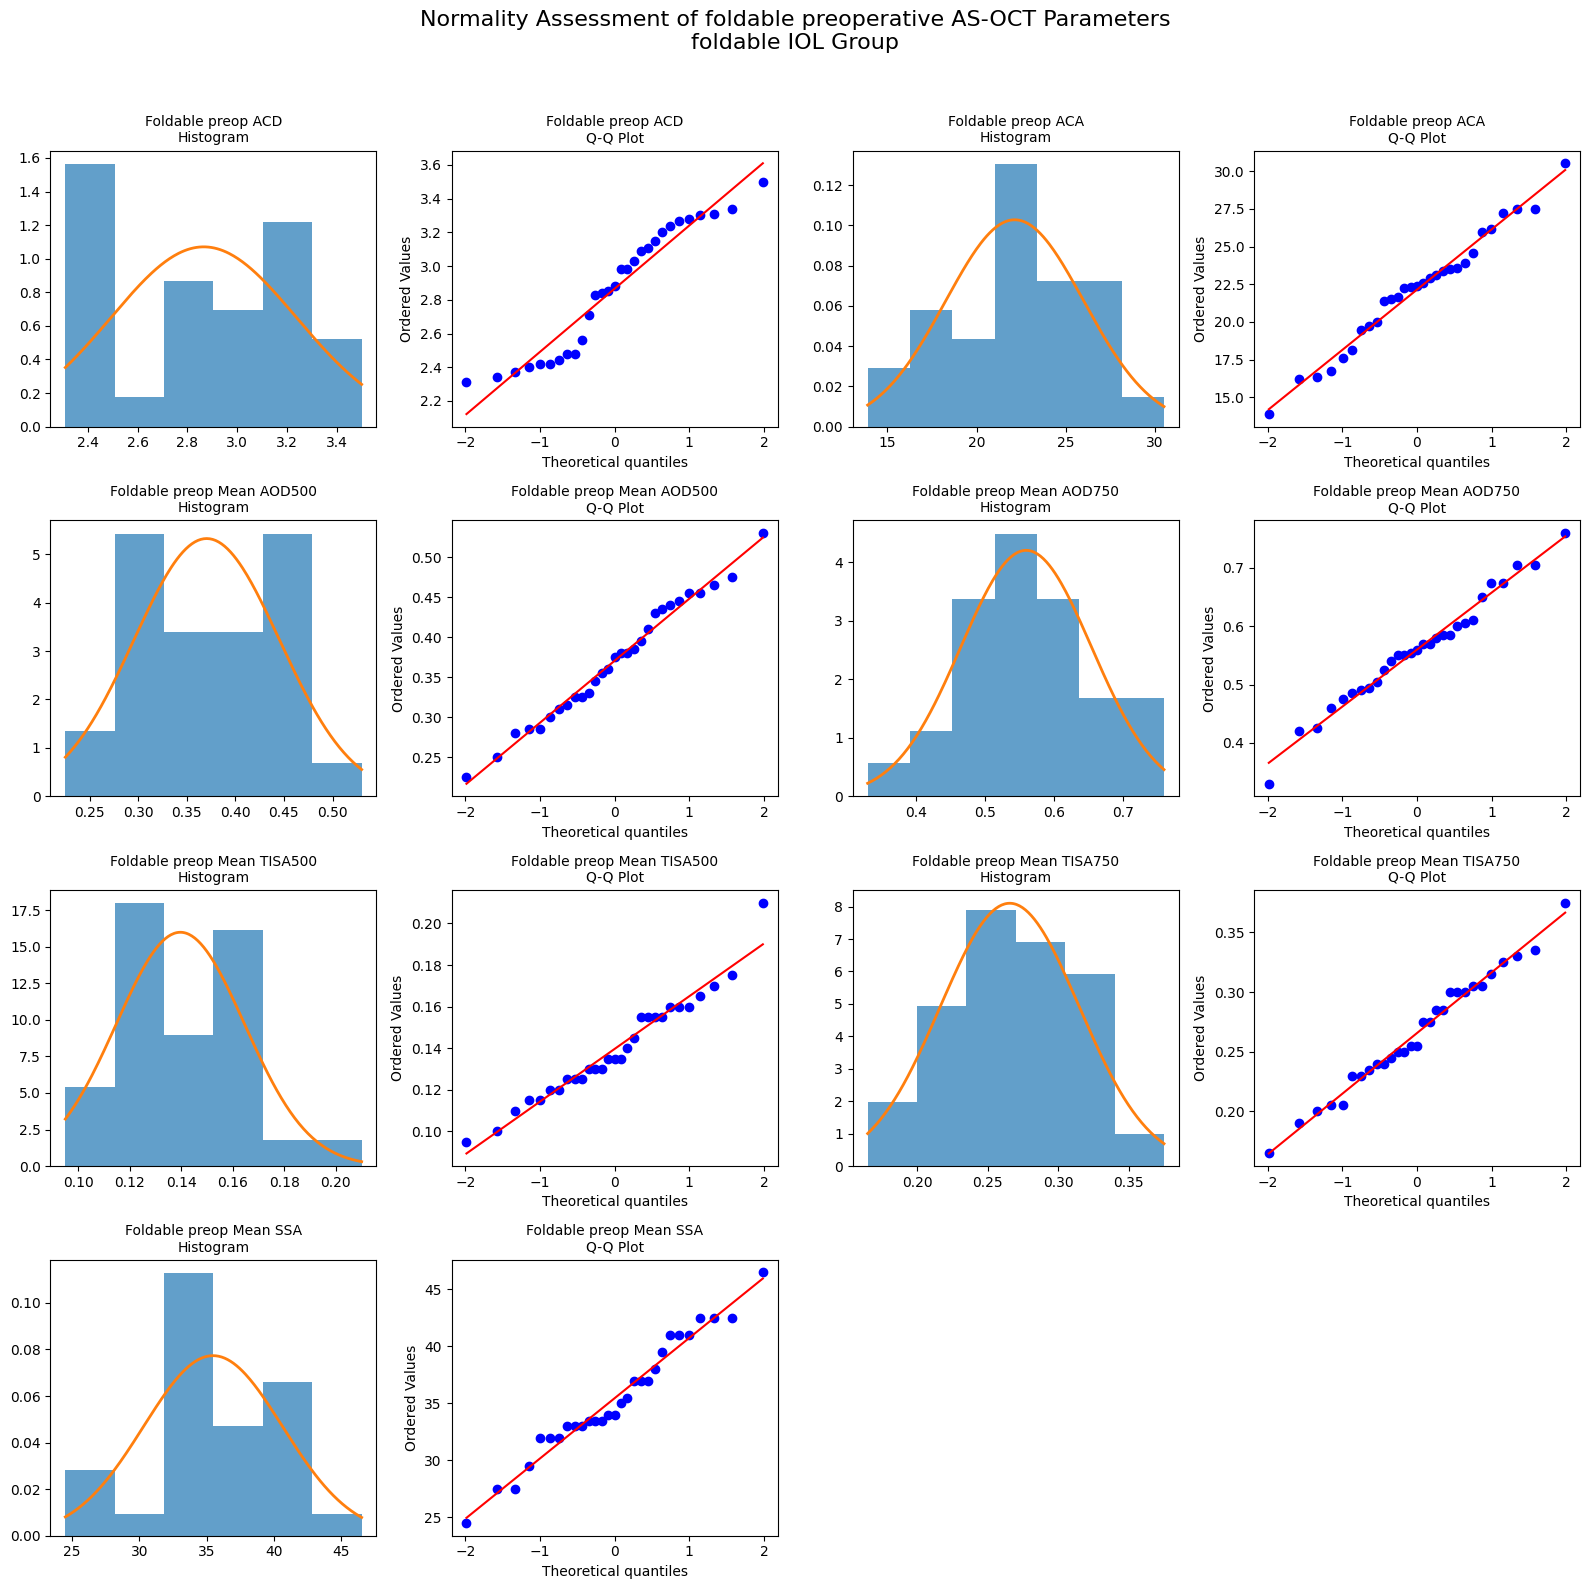

In [309]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, probplot

variables = [
    'Preop ACD (F)', 'Preop ACA (F) ',
    'preop_meanAOD500',
    'preop_meanAOD750',
    'preop_meanTISA500',
    'preop_meanTISA750',
    'preop_meanSSA']




titles = [
    'Foldable preop ACD',
    'Foldable preop ACA',
    'Foldable preop Mean AOD500',
    'Foldable preop Mean AOD750',
    'Foldable preop Mean TISA500',
    'Foldable preop Mean TISA750',
    'Foldable preop Mean SSA',

]

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

panel = 0

for var, title in zip(variables, titles):

    data = preop_foldable_df[var].dropna()

    # Histogram + Normal Curve
    axes[panel].hist(data, bins='auto', density=True, alpha=0.7)

    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 200)

    axes[panel].plot(
        x,
        norm.pdf(x, mu, sigma),
        linewidth=2
    )

    axes[panel].set_title(f'{title}\nHistogram', fontsize=10)
    panel += 1

    # QQ Plot
    probplot(data, dist='norm', plot=axes[panel])
    axes[panel].set_title(f'{title}\nQ-Q Plot', fontsize=10)
    panel += 1

# Hide unused panels
for i in range(panel, len(axes)):
    axes[i].axis('off')

plt.suptitle(
    'Normality Assessment of foldable preoperative AS-OCT Parameters\nfoldable IOL Group',
    fontsize=16,
    y=0.99
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(
    'preop_foldable_Normality_4x4.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

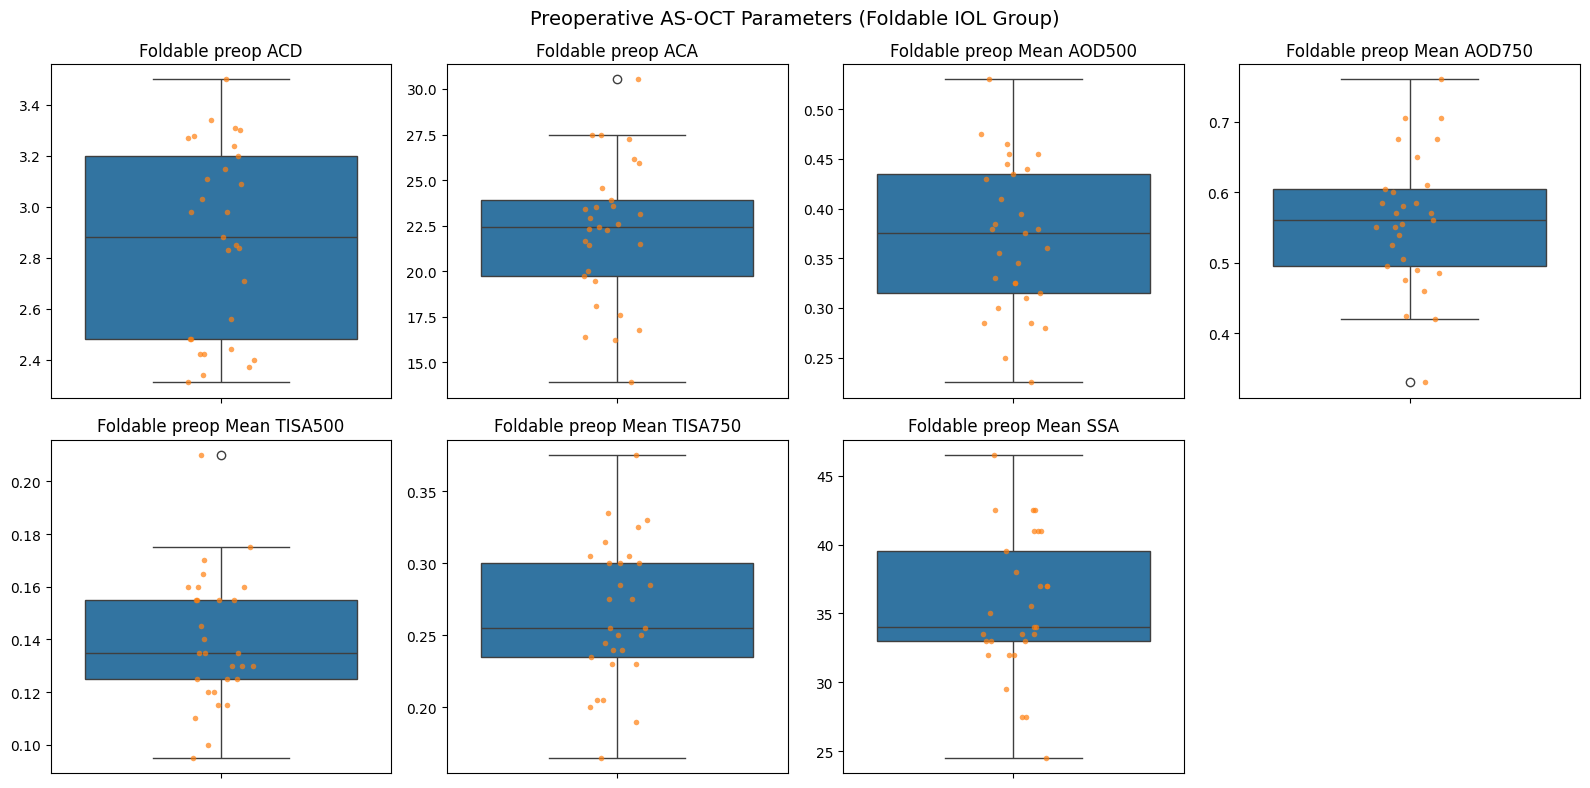

In [310]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, (var, title) in enumerate(zip(variables, titles)):

    sns.boxplot(
        y=preop_foldable_df[var],
        ax=axes[i]
    )

    sns.stripplot(
        y=preop_foldable_df[var],
        ax=axes[i],
        size=4,
        alpha=0.7
    )

    axes[i].set_title(title)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

axes[7].axis('off')

plt.suptitle(
    'Preoperative AS-OCT Parameters (Foldable IOL Group)',
    fontsize=14
)

plt.tight_layout()
plt.show()

## Foldable POD1 analysis

In [311]:
fold_pod1.isnull().sum()

,0
Name,0
Age (F),0
Sex (F),0
Cataract grading-F,0
Laterality (F),0
POD1 IOP (F),0
ACD POD1 (F),0
LV POD1 (F),0
CCT POD1 (F),0
ACA POD1 (F),0


In [312]:
fold_pod1.columns,

(Index(['Name', 'Age (F)', 'Sex (F) ', 'Cataract grading-F ', 'Laterality (F)',
        'POD1 IOP (F)', 'ACD POD1 (F)', 'LV POD1 (F)', 'CCT POD1 (F)',
        'ACA POD1 (F)', 'ATA POD1 (F)', 'AOD 500 N POD1 (F)',
        'AOD 750 N POD1 (F)', 'TISA 500 N POD1 (F)', 'TISA N 750 POD1 (F)',
        'SSA-N POD1 (F)', 'AOD T 500 POD1 (F)', 'AOD T 750 POD1 (F)',
        'TISA T 500 POD1 (F)', 'TISA 750 T POD1 (F)', 'SSA-T POD1 (F)'],
       dtype='object'),)

In [313]:
pod1_foldable_df = fold_pod1[[
    'ACD POD1 (F)', 'ACA POD1 (F)',
    'AOD T 500 POD1 (F)', 'AOD 500 N POD1 (F)',
    'AOD T 750 POD1 (F)','AOD 750 N POD1 (F)',
    'TISA T 500 POD1 (F)','TISA 500 N POD1 (F)',
    'TISA 750 T POD1 (F)', 'TISA N 750 POD1 (F)',
    'SSA-T POD1 (F)','SSA-N POD1 (F)',
    'ATA POD1 (F)','LV POD1 (F)',
    'CCT POD1 (F)','POD1 IOP (F)'

]]

In [314]:
pod1_foldable_df['pod1_meanAOD500'] = (fold_pod1['AOD T 500 POD1 (F)'] + fold_pod1['AOD 500 N POD1 (F)'])/2

pod1_foldable_df['pod1_meanAOD750'] = (fold_pod1['AOD T 750 POD1 (F)'] + fold_pod1['AOD 750 N POD1 (F)'])/2

pod1_foldable_df['pod1_meanTISA500'] = (fold_pod1['TISA T 500 POD1 (F)'] + fold_pod1['TISA 500 N POD1 (F)'])/2

pod1_foldable_df['pod1_meanTISA750'] = (fold_pod1['TISA 750 T POD1 (F)'] + fold_pod1['TISA N 750 POD1 (F)'])/2

pod1_foldable_df['pod1_meanSSA'] = (fold_pod1['SSA-T POD1 (F)'] + fold_pod1['SSA-N POD1 (F)'])/2




/tmp/ipykernel_905/3007757932.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pod1_foldable_df['pod1_meanAOD500'] = (fold_pod1['AOD T 500 POD1 (F)'] + fold_pod1['AOD 500 N POD1 (F)'])/2
/tmp/ipykernel_905/3007757932.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pod1_foldable_df['pod1_meanAOD750'] = (fold_pod1['AOD T 750 POD1 (F)'] + fold_pod1['AOD 750 N POD1 (F)'])/2
/tmp/ipykernel_905/3007757932.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try 

In [315]:
pod1_foldable_df.columns

Index(['ACD POD1 (F)', 'ACA POD1 (F)', 'AOD T 500 POD1 (F)',
       'AOD 500 N POD1 (F)', 'AOD T 750 POD1 (F)', 'AOD 750 N POD1 (F)',
       'TISA T 500 POD1 (F)', 'TISA 500 N POD1 (F)', 'TISA 750 T POD1 (F)',
       'TISA N 750 POD1 (F)', 'SSA-T POD1 (F)', 'SSA-N POD1 (F)',
       'ATA POD1 (F)', 'LV POD1 (F)', 'CCT POD1 (F)', 'POD1 IOP (F)',
       'pod1_meanAOD500', 'pod1_meanAOD750', 'pod1_meanTISA500',
       'pod1_meanTISA750', 'pod1_meanSSA'],
      dtype='object')

In [316]:
import pandas as pd
from scipy.stats import shapiro

variables = [
    'ACD POD1 (F)', 'ACA POD1 (F)',
    'pod1_meanAOD500',
    'pod1_meanAOD750',
    'pod1_meanTISA500',
    'pod1_meanTISA750',
    'pod1_meanSSA'

]



results = []

for var in variables:

    data = pod1_foldable_df[var].dropna()

    W, p = shapiro(data)

    results.append([
        var,
        f"{data.count():.2f}",
        f"{data.mean():.2f} ± {data.std():.2f}",
        f"{data.median():.2f} ({data.quantile(0.25):.2f}–{data.quantile(0.75):.2f})",
        round(data.min(), 2),
        round(data.max(), 2),
        round(W, 3),
        round(p, 3)
    ])

desc_table = pd.DataFrame(
    results,
    columns=[
        'Variable',
        'Count',
        'Mean ± SD',
        'Median (IQR)',
        'Minimum',
        'Maximum',
        'Shapiro-Wilk W',
        'p-value'
    ]
)

desc_table

,Variable,Count,Mean ± SD,Median (IQR),Minimum,Maximum,Shapiro-Wilk W,p-value
0,ACD POD1 (F),29.00,4.18 ± 0.22,4.14 (4.05–4.40),3.83,4.55,0.949,0.177
1,ACA POD1 (F),29.00,26.68 ± 2.32,26.50 (24.53–28.65),22.44,30.20,0.945,0.137
2,pod1_meanAOD500,29.00,0.53 ± 0.09,0.51 (0.46–0.61),0.38,0.69,0.929,0.050
3,pod1_meanAOD750,29.00,0.82 ± 0.08,0.83 (0.77–0.88),0.69,0.98,0.973,0.638
4,pod1_meanTISA500,29.00,0.18 ± 0.02,0.17 (0.17–0.19),0.15,0.23,0.963,0.396
5,pod1_meanTISA750,29.00,0.37 ± 0.05,0.36 (0.33–0.41),0.30,0.45,0.918,0.027
6,pod1_meanSSA,29.00,43.69 ± 4.14,43.50 (41.00–46.50),37.00,53.50,0.975,0.688


In [317]:
pod1_foldable_df.columns

Index(['ACD POD1 (F)', 'ACA POD1 (F)', 'AOD T 500 POD1 (F)',
       'AOD 500 N POD1 (F)', 'AOD T 750 POD1 (F)', 'AOD 750 N POD1 (F)',
       'TISA T 500 POD1 (F)', 'TISA 500 N POD1 (F)', 'TISA 750 T POD1 (F)',
       'TISA N 750 POD1 (F)', 'SSA-T POD1 (F)', 'SSA-N POD1 (F)',
       'ATA POD1 (F)', 'LV POD1 (F)', 'CCT POD1 (F)', 'POD1 IOP (F)',
       'pod1_meanAOD500', 'pod1_meanAOD750', 'pod1_meanTISA500',
       'pod1_meanTISA750', 'pod1_meanSSA'],
      dtype='object')

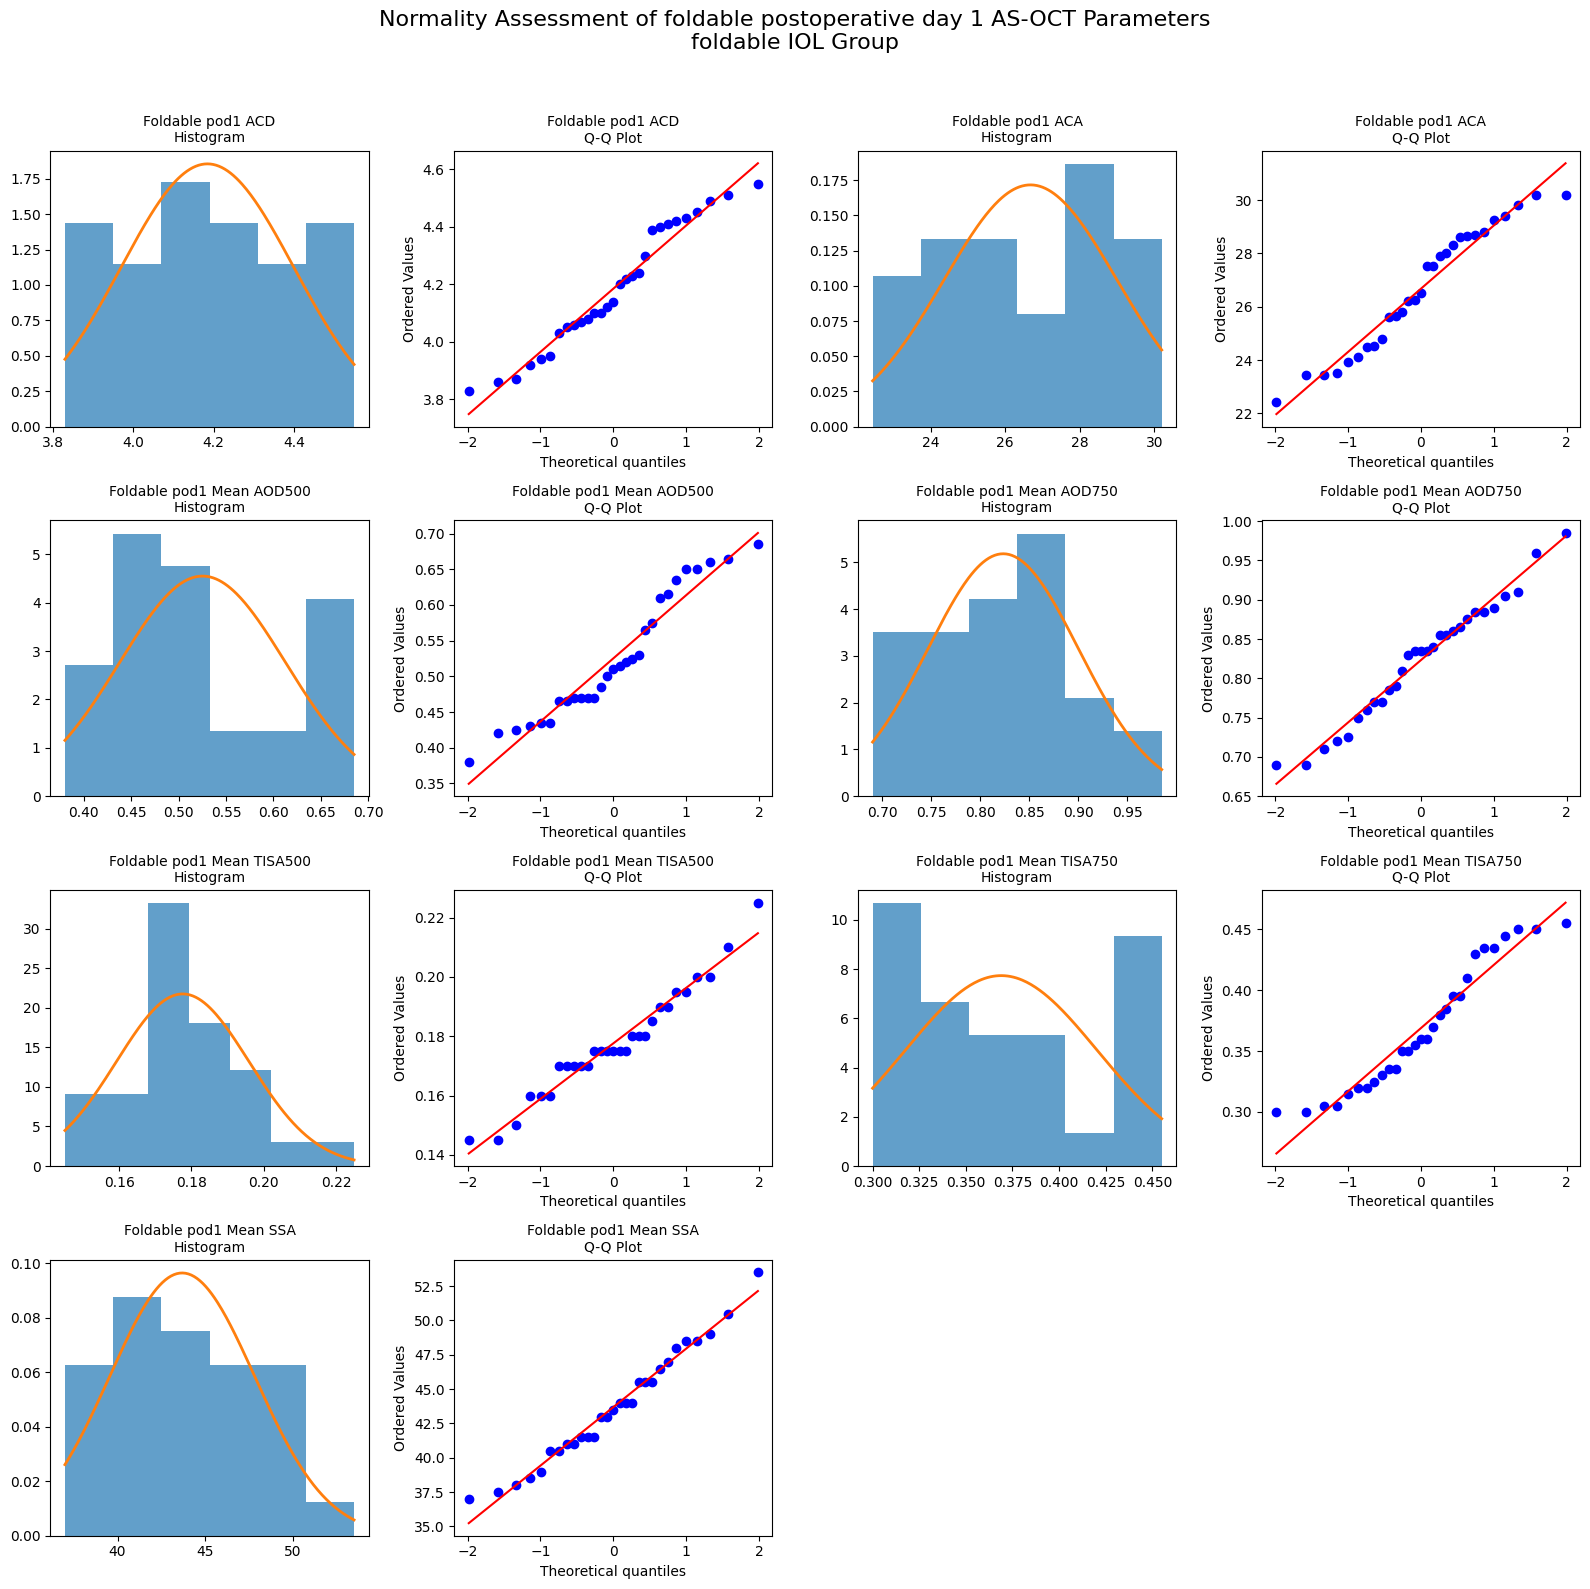

In [318]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, probplot

variables = [
    'ACD POD1 (F)', 'ACA POD1 (F)',
    'pod1_meanAOD500',
    'pod1_meanAOD750',
    'pod1_meanTISA500',
    'pod1_meanTISA750',
    'pod1_meanSSA'
]




titles = [
    'Foldable pod1 ACD',
    'Foldable pod1 ACA',
    'Foldable pod1 Mean AOD500',
    'Foldable pod1 Mean AOD750',
    'Foldable pod1 Mean TISA500',
    'Foldable pod1 Mean TISA750',
    'Foldable pod1 Mean SSA',

]

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

panel = 0

for var, title in zip(variables, titles):

    data = pod1_foldable_df[var].dropna()

    # Histogram + Normal Curve
    axes[panel].hist(data, bins='auto', density=True, alpha=0.7)

    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 200)

    axes[panel].plot(
        x,
        norm.pdf(x, mu, sigma),
        linewidth=2
    )

    axes[panel].set_title(f'{title}\nHistogram', fontsize=10)
    panel += 1

    # QQ Plot
    probplot(data, dist='norm', plot=axes[panel])
    axes[panel].set_title(f'{title}\nQ-Q Plot', fontsize=10)
    panel += 1

# Hide unused panels
for i in range(panel, len(axes)):
    axes[i].axis('off')

plt.suptitle(
    'Normality Assessment of foldable postoperative day 1 AS-OCT Parameters\nfoldable IOL Group',
    fontsize=16,
    y=0.99
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(
    'POD1_foldable_Normality_4x4.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

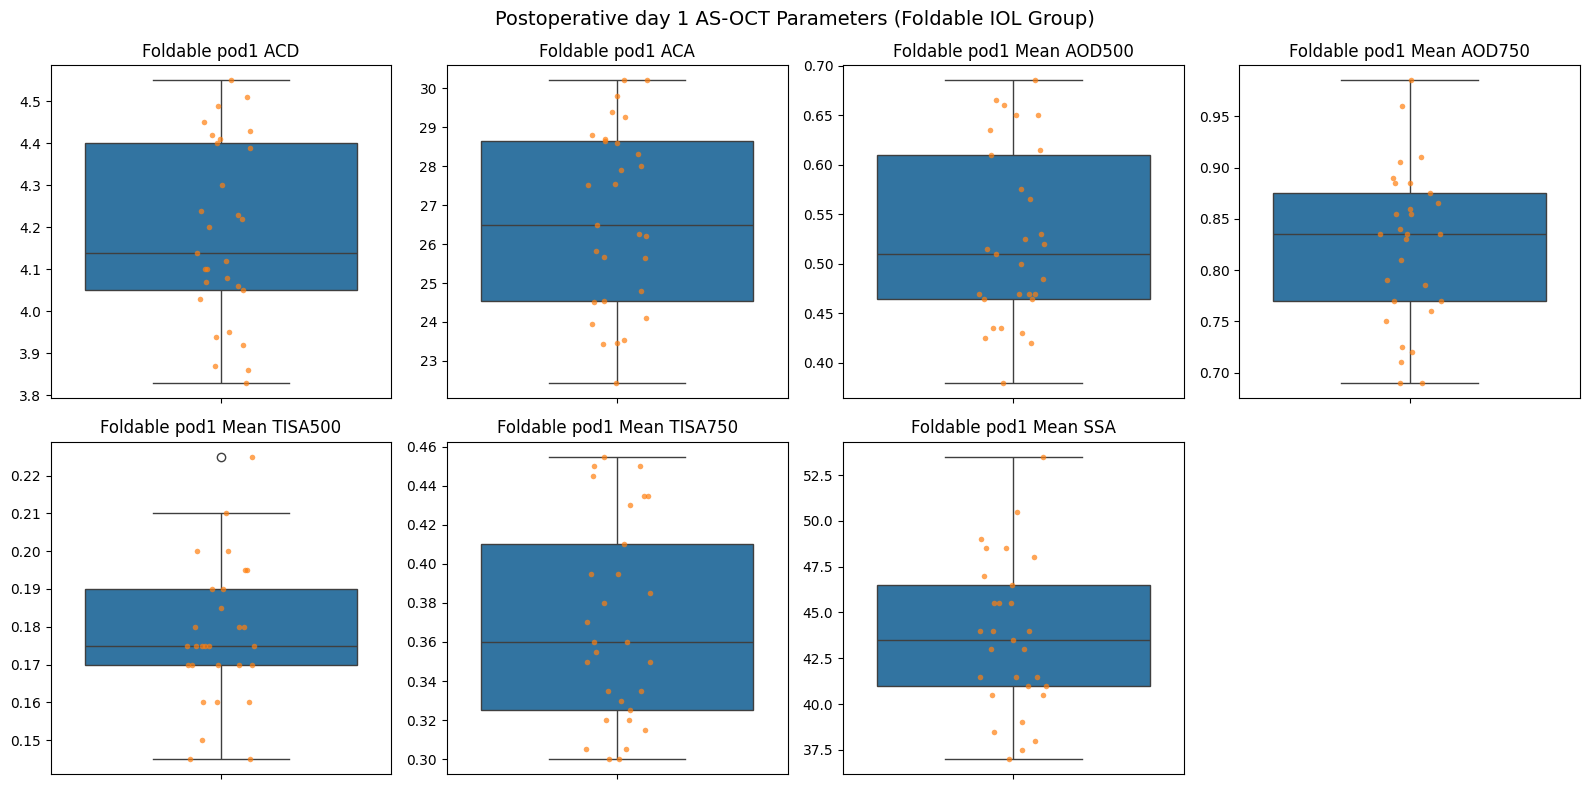

In [319]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, (var, title) in enumerate(zip(variables, titles)):

    sns.boxplot(
        y=pod1_foldable_df[var],
        ax=axes[i]
    )

    sns.stripplot(
        y=pod1_foldable_df[var],
        ax=axes[i],
        size=4,
        alpha=0.7
    )

    axes[i].set_title(title)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

axes[7].axis('off')

plt.suptitle(
    'Postoperative day 1 AS-OCT Parameters (Foldable IOL Group)',
    fontsize=14
)

plt.tight_layout()
plt.show()

## Foldable 6 weeks analysis

In [320]:
fold_pod6wks.isnull().sum()

,0
Name,0
Age (F),0
Sex (F),0
Cataract grading-F,0
Laterality (F),0
POD6wk IOP (F),0
ACD 6wk (F),0
LV 6 wk (F),0
CCT 6 wk (F),0
ACA POD 6 wk (F),0


In [321]:
fold_pod6wks.columns

Index(['Name', 'Age (F)', 'Sex (F) ', 'Cataract grading-F ', 'Laterality (F)',
       'POD6wk IOP (F)', 'ACD 6wk (F)', 'LV 6 wk (F)', 'CCT 6 wk (F)',
       'ACA POD 6 wk (F)', 'ATA POD6wk (F)', 'AOD N 500 6 wk (F)',
       'AOD N 750 6 wk (F)', 'TISA N 500 6 wk (F)', 'TISA N 750 6 wk (F)',
       'SSA-N 6 wk (F)', 'AOD T 500 6 wk (F)', 'AOD T 750 6 wk (F)',
       'TISA T 500 6 wk (F)', 'TISA T 750 6 wk (F)', 'SSA-T 6 wk (F)'],
      dtype='object')

In [322]:
pod6wk_foldable_df = fold_pod6wks[[
     'ACD 6wk (F)', 'ACA POD 6 wk (F)',
     'AOD T 500 6 wk (F)' ,'AOD N 500 6 wk (F)',
     'AOD T 750 6 wk (F)', 'AOD N 750 6 wk (F)',
     'TISA T 500 6 wk (F)','TISA N 500 6 wk (F)',
     'TISA T 750 6 wk (F)', 'TISA N 750 6 wk (F)',
     'SSA-T 6 wk (F)','SSA-N 6 wk (F)',
      'ATA POD6wk (F)',  'LV 6 wk (F)',
      'CCT 6 wk (F)','POD6wk IOP (F)'

]]

In [323]:
fold_pod6wks.columns

Index(['Name', 'Age (F)', 'Sex (F) ', 'Cataract grading-F ', 'Laterality (F)',
       'POD6wk IOP (F)', 'ACD 6wk (F)', 'LV 6 wk (F)', 'CCT 6 wk (F)',
       'ACA POD 6 wk (F)', 'ATA POD6wk (F)', 'AOD N 500 6 wk (F)',
       'AOD N 750 6 wk (F)', 'TISA N 500 6 wk (F)', 'TISA N 750 6 wk (F)',
       'SSA-N 6 wk (F)', 'AOD T 500 6 wk (F)', 'AOD T 750 6 wk (F)',
       'TISA T 500 6 wk (F)', 'TISA T 750 6 wk (F)', 'SSA-T 6 wk (F)'],
      dtype='object')

In [324]:
pod6wk_foldable_df['pod6wk_meanAOD500'] = (fold_pod6wks['AOD T 500 6 wk (F)'] + fold_pod6wks['AOD N 500 6 wk (F)'])/2

pod6wk_foldable_df['pod6wk_meanAOD750'] = (fold_pod6wks['AOD T 750 6 wk (F)'] + fold_pod6wks['AOD N 750 6 wk (F)'])/2

pod6wk_foldable_df['pod6wk_meanTISA500'] = (fold_pod6wks['TISA T 500 6 wk (F)'] + fold_pod6wks['TISA N 500 6 wk (F)'])/2

pod6wk_foldable_df['pod6wk_meanTISA750'] = (fold_pod6wks['TISA T 750 6 wk (F)'] + fold_pod6wks['TISA N 750 6 wk (F)'])/2

pod6wk_foldable_df['pod6wk_meanSSA'] = (fold_pod6wks['SSA-T 6 wk (F)'] + fold_pod6wks['SSA-N 6 wk (F)'])/2



/tmp/ipykernel_905/2879702866.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pod6wk_foldable_df['pod6wk_meanAOD500'] = (fold_pod6wks['AOD T 500 6 wk (F)'] + fold_pod6wks['AOD N 500 6 wk (F)'])/2
/tmp/ipykernel_905/2879702866.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pod6wk_foldable_df['pod6wk_meanAOD750'] = (fold_pod6wks['AOD T 750 6 wk (F)'] + fold_pod6wks['AOD N 750 6 wk (F)'])/2
/tmp/ipykernel_905/2879702866.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice fr

In [325]:
pod6wk_foldable_df.columns

Index(['ACD 6wk (F)', 'ACA POD 6 wk (F)', 'AOD T 500 6 wk (F)',
       'AOD N 500 6 wk (F)', 'AOD T 750 6 wk (F)', 'AOD N 750 6 wk (F)',
       'TISA T 500 6 wk (F)', 'TISA N 500 6 wk (F)', 'TISA T 750 6 wk (F)',
       'TISA N 750 6 wk (F)', 'SSA-T 6 wk (F)', 'SSA-N 6 wk (F)',
       'ATA POD6wk (F)', 'LV 6 wk (F)', 'CCT 6 wk (F)', 'POD6wk IOP (F)',
       'pod6wk_meanAOD500', 'pod6wk_meanAOD750', 'pod6wk_meanTISA500',
       'pod6wk_meanTISA750', 'pod6wk_meanSSA'],
      dtype='object')

In [326]:
import pandas as pd
from scipy.stats import shapiro

variables = [
   'ACD 6wk (F)', 'ACA POD 6 wk (F)',
    'pod6wk_meanAOD500', 'pod6wk_meanAOD750', 'pod6wk_meanTISA500',
       'pod6wk_meanTISA750', 'pod6wk_meanSSA']


results = []

for var in variables:

    data = pod6wk_foldable_df[var].dropna()

    W, p = shapiro(data)

    results.append([
        var,
        f"{data.count():.2f}",
        f"{data.mean():.2f} ± {data.std():.2f}",
        f"{data.median():.2f} ({data.quantile(0.25):.2f}–{data.quantile(0.75):.2f})",
        round(data.min(), 2),
        round(data.max(), 2),
        round(W, 3),
        round(p, 3)
    ])

desc_table = pd.DataFrame(
    results,
    columns=[
        'Variable',
        'Count',
        'Mean ± SD',
        'Median (IQR)',
        'Minimum',
        'Maximum',
        'Shapiro-Wilk W',
        'p-value'
    ]
)

desc_table

,Variable,Count,Mean ± SD,Median (IQR),Minimum,Maximum,Shapiro-Wilk W,p-value
0,ACD 6wk (F),29.00,3.89 ± 0.23,3.89 (3.74–3.98),3.54,4.43,0.949,0.173
1,ACA POD 6 wk (F),29.00,25.90 ± 2.04,26.17 (24.12–27.30),22.14,29.64,0.965,0.427
2,pod6wk_meanAOD500,29.00,0.51 ± 0.07,0.51 (0.47–0.56),0.32,0.63,0.971,0.590
3,pod6wk_meanAOD750,29.00,0.74 ± 0.08,0.74 (0.70–0.79),0.48,0.88,0.933,0.065
4,pod6wk_meanTISA500,29.00,0.18 ± 0.02,0.18 (0.17–0.18),0.12,0.22,0.929,0.052
5,pod6wk_meanTISA750,29.00,0.33 ± 0.04,0.34 (0.30–0.36),0.22,0.40,0.943,0.118
6,pod6wk_meanSSA,29.00,41.95 ± 3.56,42.00 (39.00–44.00),35.00,49.00,0.977,0.771


In [327]:
pod6wk_foldable_df.columns

Index(['ACD 6wk (F)', 'ACA POD 6 wk (F)', 'AOD T 500 6 wk (F)',
       'AOD N 500 6 wk (F)', 'AOD T 750 6 wk (F)', 'AOD N 750 6 wk (F)',
       'TISA T 500 6 wk (F)', 'TISA N 500 6 wk (F)', 'TISA T 750 6 wk (F)',
       'TISA N 750 6 wk (F)', 'SSA-T 6 wk (F)', 'SSA-N 6 wk (F)',
       'ATA POD6wk (F)', 'LV 6 wk (F)', 'CCT 6 wk (F)', 'POD6wk IOP (F)',
       'pod6wk_meanAOD500', 'pod6wk_meanAOD750', 'pod6wk_meanTISA500',
       'pod6wk_meanTISA750', 'pod6wk_meanSSA'],
      dtype='object')

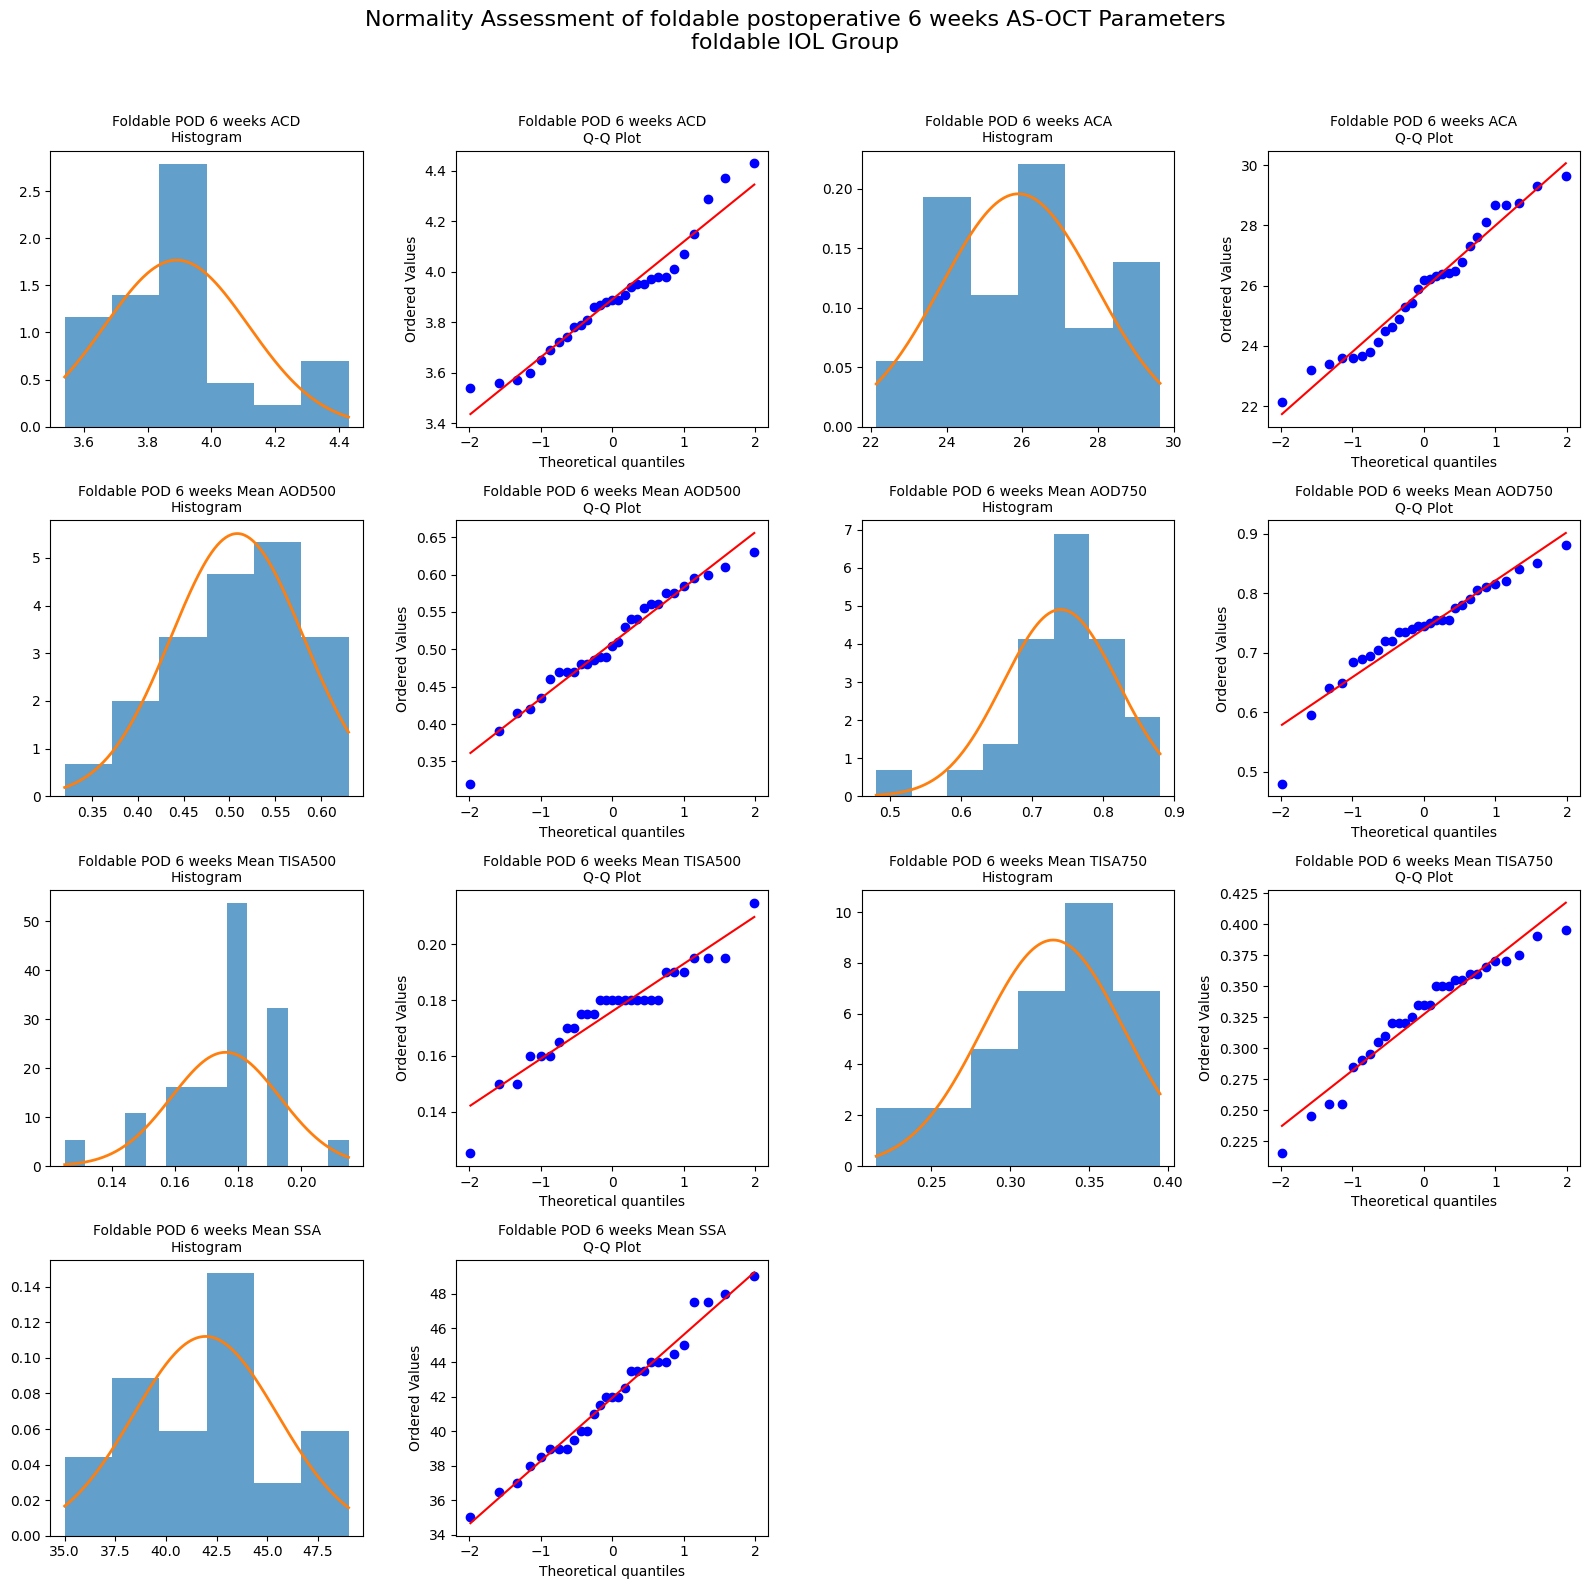

In [328]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, probplot

variables = [
    'ACD 6wk (F)', 'ACA POD 6 wk (F)',
    'pod6wk_meanAOD500',
    'pod6wk_meanAOD750',
    'pod6wk_meanTISA500',
    'pod6wk_meanTISA750',
    'pod6wk_meanSSA']






titles = [
    'Foldable POD 6 weeks ACD',
    'Foldable POD 6 weeks ACA',
    'Foldable POD 6 weeks Mean AOD500',
    'Foldable POD 6 weeks Mean AOD750',
    'Foldable POD 6 weeks Mean TISA500',
    'Foldable POD 6 weeks Mean TISA750',
    'Foldable POD 6 weeks Mean SSA',

]

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

panel = 0

for var, title in zip(variables, titles):

    data = pod6wk_foldable_df[var].dropna()

    # Histogram + Normal Curve
    axes[panel].hist(data, bins='auto', density=True, alpha=0.7)

    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 200)

    axes[panel].plot(
        x,
        norm.pdf(x, mu, sigma),
        linewidth=2
    )

    axes[panel].set_title(f'{title}\nHistogram', fontsize=10)
    panel += 1

    # QQ Plot
    probplot(data, dist='norm', plot=axes[panel])
    axes[panel].set_title(f'{title}\nQ-Q Plot', fontsize=10)
    panel += 1

# Hide unused panels
for i in range(panel, len(axes)):
    axes[i].axis('off')

plt.suptitle(
    'Normality Assessment of foldable postoperative 6 weeks AS-OCT Parameters\nfoldable IOL Group',
    fontsize=16,
    y=0.99
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(
    'POD6wk_foldable_Normality_4x4.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

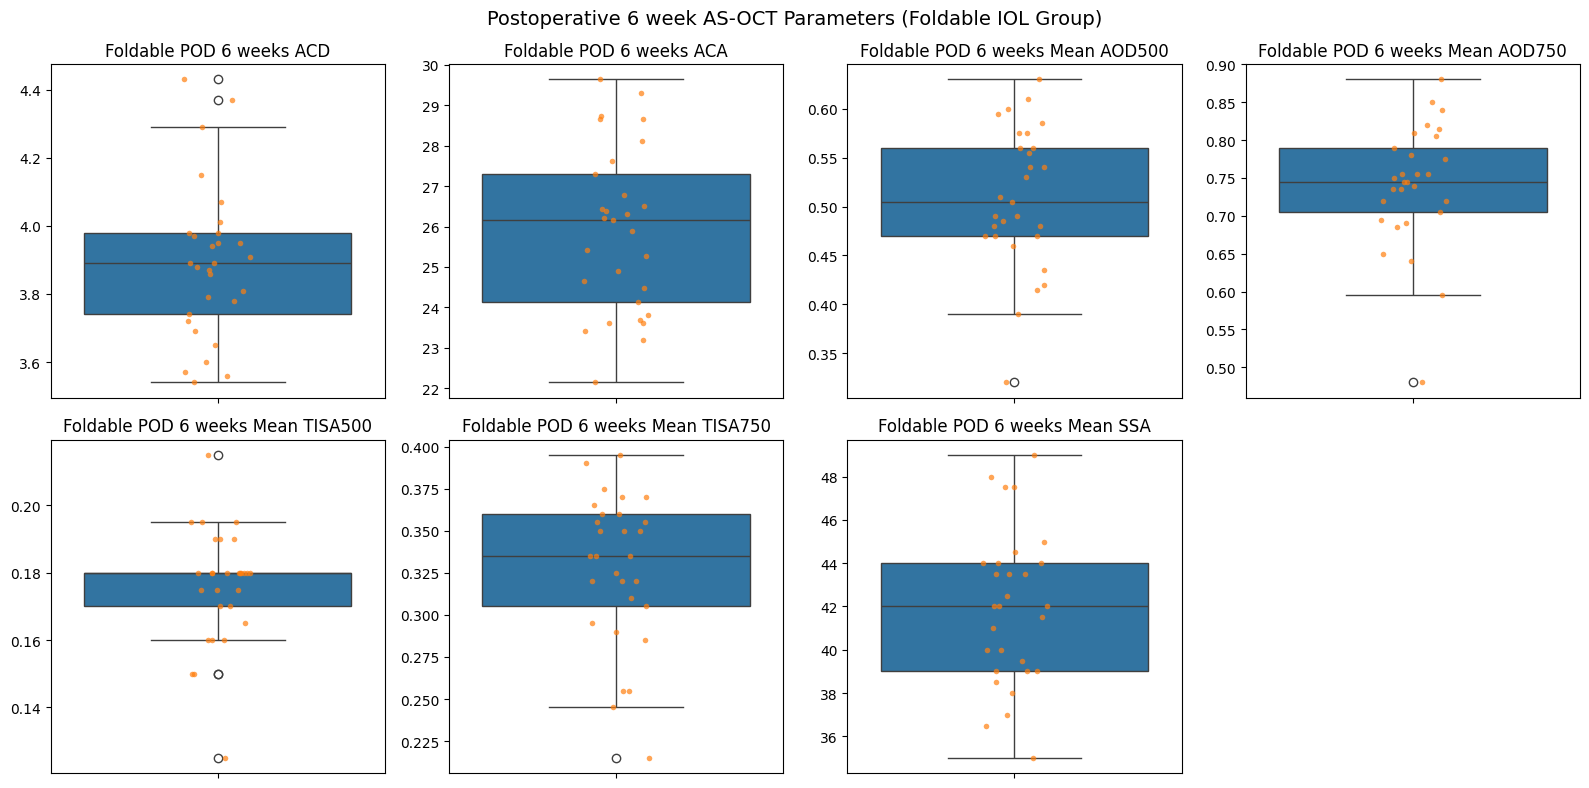

In [329]:
import matplotlib.pyplot as plt
import seaborn as sns

variables = [
    'ACD 6wk (F)', 'ACA POD 6 wk (F)',
    'pod6wk_meanAOD500',
    'pod6wk_meanAOD750',
    'pod6wk_meanTISA500',
    'pod6wk_meanTISA750',
    'pod6wk_meanSSA'

]

titles = [
    'Foldable POD 6 weeks ACD',
    'Foldable POD 6 weeks ACA',
    'Foldable POD 6 weeks Mean AOD500',
    'Foldable POD 6 weeks Mean AOD750',
    'Foldable POD 6 weeks Mean TISA500',
    'Foldable POD 6 weeks Mean TISA750',
    'Foldable POD 6 weeks Mean SSA',

]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, (var, title) in enumerate(zip(variables, titles)):

    sns.boxplot(
        y=pod6wk_foldable_df[var],
        ax=axes[i]
    )

    sns.stripplot(
        y=pod6wk_foldable_df[var],
        ax=axes[i],
        size=4,
        alpha=0.7
    )

    axes[i].set_title(title)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

axes[7].axis('off')

plt.suptitle(
    'Postoperative 6 week AS-OCT Parameters (Foldable IOL Group)',
    fontsize=14
)

plt.tight_layout()
plt.show()

## Foldable 3 months analysis

In [330]:
fold_pod3mths.isnull().sum()

,0
Name,0
Age (F),0
Sex (F),0
Cataract grading-F,0
Laterality (F),0
POD 3 mth IOP (F),0
ACD 3 mth (F),0
LV 3 mth (F),0
CCT 3 mth (F),0
ACA 3 mth (F),0


In [331]:
fold_pod3mths.columns

Index(['Name', 'Age (F)', 'Sex (F) ', 'Cataract grading-F ', 'Laterality (F)',
       'POD 3 mth IOP (F)', 'ACD 3 mth (F)', 'LV 3 mth (F)', 'CCT 3 mth (F)',
       'ACA 3 mth (F)', 'ATA 3mth (F)', 'AOD N 500 3 mth (F)',
       'AOD N 750 3 mth (F)', 'TISA N 500 3 mth (F)', 'TISA N 750 3 mth (F)',
       'SSA-N 3 mth (F)', 'AOD T 500 3 mth (F)', 'AOD T 750 3 mth (F)',
       'TISA T 500 3 mth (F)', 'TISA T 750 3 mth (F)', 'SSA-T 3 mth (F)'],
      dtype='object')

In [332]:
pod3mths_foldable_df = fold_pod3mths[[
    'ACD 3 mth (F)',  'ACA 3 mth (F)',
      'AOD T 500 3 mth (F)', 'AOD N 500 3 mth (F)',
      'AOD T 750 3 mth (F)','AOD N 750 3 mth (F)',
    'TISA T 500 3 mth (F)','TISA N 500 3 mth (F)',
   'TISA T 750 3 mth (F)', 'TISA N 750 3 mth (F)',
       'SSA-T 3 mth (F)','SSA-N 3 mth (F)',
    'ATA 3mth (F)', 'LV 3 mth (F)',   'CCT 3 mth (F)',
    'POD 3 mth IOP (F)'
]]

In [333]:
pod3mths_foldable_df['meanAOD500'] = (fold_pod3mths['AOD T 500 3 mth (F)'] + fold_pod3mths['AOD N 500 3 mth (F)'])/2

pod3mths_foldable_df['meanAOD750'] = (fold_pod3mths['AOD T 750 3 mth (F)'] + fold_pod3mths['AOD N 750 3 mth (F)'])/2

pod3mths_foldable_df['meanTISA500'] = (fold_pod3mths['TISA T 500 3 mth (F)'] + fold_pod3mths['TISA N 500 3 mth (F)'])/2

pod3mths_foldable_df['meanTISA750'] = (fold_pod3mths['TISA T 750 3 mth (F)'] + fold_pod3mths['TISA N 750 3 mth (F)'])/2

pod3mths_foldable_df['meanSSA'] = (fold_pod3mths['SSA-T 3 mth (F)'] + fold_pod3mths['SSA-N 3 mth (F)'])/2

/tmp/ipykernel_905/64086854.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pod3mths_foldable_df['meanAOD500'] = (fold_pod3mths['AOD T 500 3 mth (F)'] + fold_pod3mths['AOD N 500 3 mth (F)'])/2
/tmp/ipykernel_905/64086854.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pod3mths_foldable_df['meanAOD750'] = (fold_pod3mths['AOD T 750 3 mth (F)'] + fold_pod3mths['AOD N 750 3 mth (F)'])/2
/tmp/ipykernel_905/64086854.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Dat

## Foldable DS with shapiro 3 months

In [334]:
pod3mths_foldable_df.columns

Index(['ACD 3 mth (F)', 'ACA 3 mth (F)', 'AOD T 500 3 mth (F)',
       'AOD N 500 3 mth (F)', 'AOD T 750 3 mth (F)', 'AOD N 750 3 mth (F)',
       'TISA T 500 3 mth (F)', 'TISA N 500 3 mth (F)', 'TISA T 750 3 mth (F)',
       'TISA N 750 3 mth (F)', 'SSA-T 3 mth (F)', 'SSA-N 3 mth (F)',
       'ATA 3mth (F)', 'LV 3 mth (F)', 'CCT 3 mth (F)', 'POD 3 mth IOP (F)',
       'meanAOD500', 'meanAOD750', 'meanTISA500', 'meanTISA750', 'meanSSA'],
      dtype='object')

In [335]:
import pandas as pd
from scipy.stats import shapiro

variables = [
    'ACD 3 mth (F)', 'ACA 3 mth (F)',
    'meanAOD500', 'meanAOD750', 'meanTISA500', 'meanTISA750', 'meanSSA'

   ]


results = []

for var in variables:

    data = pod3mths_foldable_df[var].dropna()

    W, p = shapiro(data)

    results.append([
        var,
        f"{data.count():.2f}",
        f"{data.mean():.2f} ± {data.std():.2f}",
        f"{data.median():.2f} ({data.quantile(0.25):.2f}–{data.quantile(0.75):.2f})",
        round(data.min(), 2),
        round(data.max(), 2),
        round(W, 3),
        round(p, 3)
    ])

desc_table = pd.DataFrame(
    results,
    columns=[
        'Variable',
        'Count',
        'Mean ± SD',
        'Median (IQR)',
        'Minimum',
        'Maximum',
        'Shapiro-Wilk W',
        'p-value'
    ]
)

desc_table

,Variable,Count,Mean ± SD,Median (IQR),Minimum,Maximum,Shapiro-Wilk W,p-value
0,ACD 3 mth (F),29.00,3.65 ± 0.19,3.65 (3.60–3.70),3.14,4.01,0.894,0.007
1,ACA 3 mth (F),29.00,24.91 ± 1.16,24.91 (24.00–24.91),23.61,28.50,0.856,0.001
2,meanAOD500,29.00,0.49 ± 0.04,0.49 (0.48–0.52),0.35,0.55,0.865,0.002
3,meanAOD750,29.00,0.68 ± 0.07,0.68 (0.67–0.71),0.46,0.79,0.896,0.008
4,meanTISA500,29.00,0.17 ± 0.01,0.17 (0.16–0.17),0.12,0.21,0.892,0.006
5,meanTISA750,29.00,0.31 ± 0.04,0.30 (0.29–0.30),0.24,0.39,0.872,0.002
6,meanSSA,29.00,41.03 ± 2.68,41.00 (39.50–42.00),35.00,48.00,0.948,0.166


In [336]:
pod3mths_foldable_df.columns

Index(['ACD 3 mth (F)', 'ACA 3 mth (F)', 'AOD T 500 3 mth (F)',
       'AOD N 500 3 mth (F)', 'AOD T 750 3 mth (F)', 'AOD N 750 3 mth (F)',
       'TISA T 500 3 mth (F)', 'TISA N 500 3 mth (F)', 'TISA T 750 3 mth (F)',
       'TISA N 750 3 mth (F)', 'SSA-T 3 mth (F)', 'SSA-N 3 mth (F)',
       'ATA 3mth (F)', 'LV 3 mth (F)', 'CCT 3 mth (F)', 'POD 3 mth IOP (F)',
       'meanAOD500', 'meanAOD750', 'meanTISA500', 'meanTISA750', 'meanSSA'],
      dtype='object')

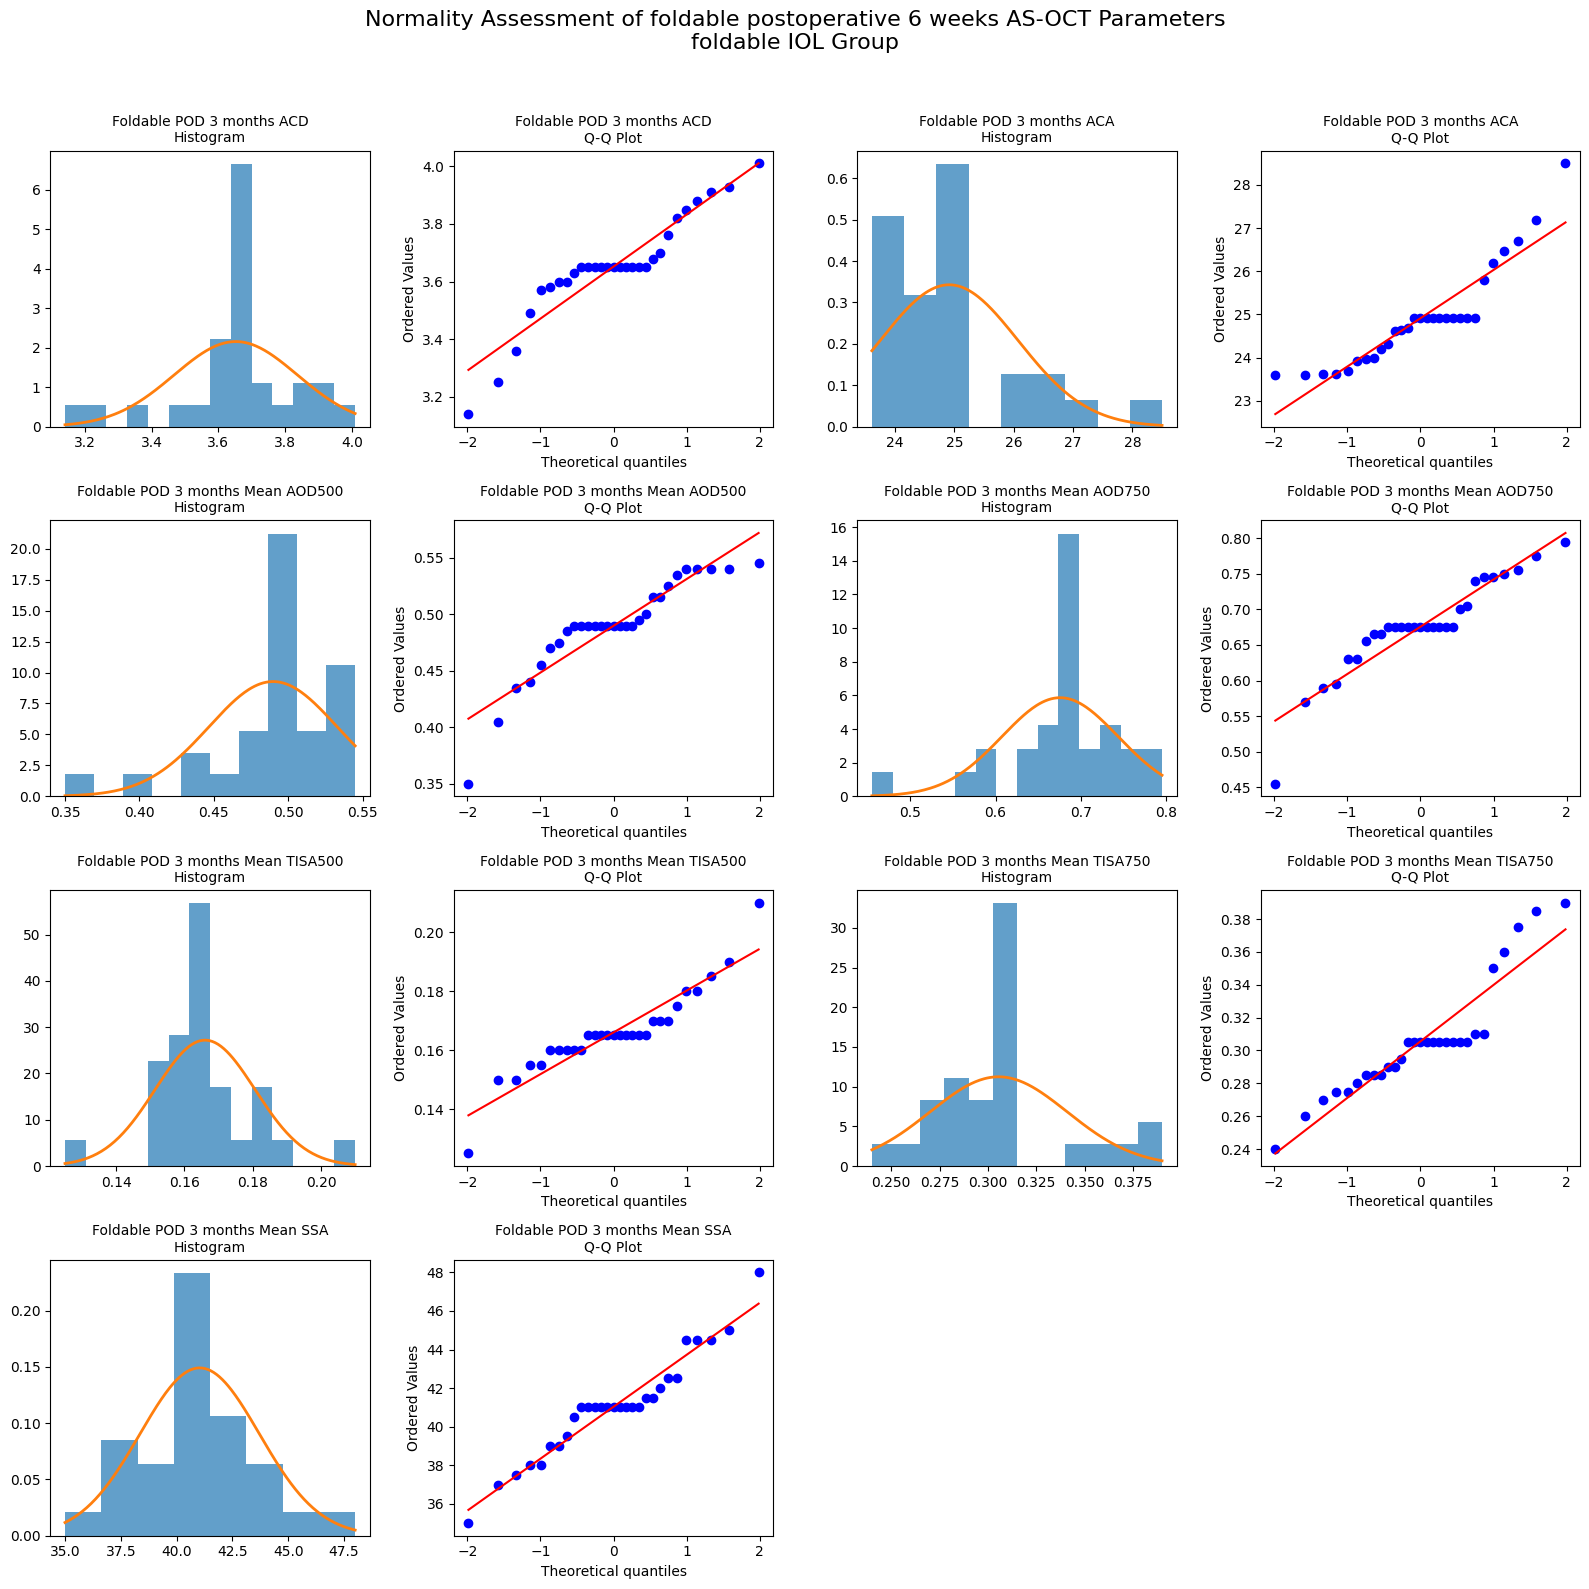

In [337]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, probplot

variables = [
   'ACD 3 mth (F)', 'ACA 3 mth (F)',
    'meanAOD500',
   'meanAOD750',
   'meanTISA500',
   'meanTISA750',
   'meanSSA'

             ]






titles = [
    'Foldable POD 3 months ACD',
    'Foldable POD 3 months ACA',
    'Foldable POD 3 months Mean AOD500',
    'Foldable POD 3 months Mean AOD750',
    'Foldable POD 3 months Mean TISA500',
    'Foldable POD 3 months Mean TISA750',
    'Foldable POD 3 months Mean SSA',

]

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

panel = 0

for var, title in zip(variables, titles):

    data = pod3mths_foldable_df[var].dropna()

    # Histogram + Normal Curve
    axes[panel].hist(data, bins='auto', density=True, alpha=0.7)

    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 200)

    axes[panel].plot(
        x,
        norm.pdf(x, mu, sigma),
        linewidth=2
    )

    axes[panel].set_title(f'{title}\nHistogram', fontsize=10)
    panel += 1

    # QQ Plot
    probplot(data, dist='norm', plot=axes[panel])
    axes[panel].set_title(f'{title}\nQ-Q Plot', fontsize=10)
    panel += 1

# Hide unused panels
for i in range(panel, len(axes)):
    axes[i].axis('off')

plt.suptitle(
    'Normality Assessment of foldable postoperative 6 weeks AS-OCT Parameters\nfoldable IOL Group',
    fontsize=16,
    y=0.99
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(
    'POD3mths_foldable_Normality_4x4.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

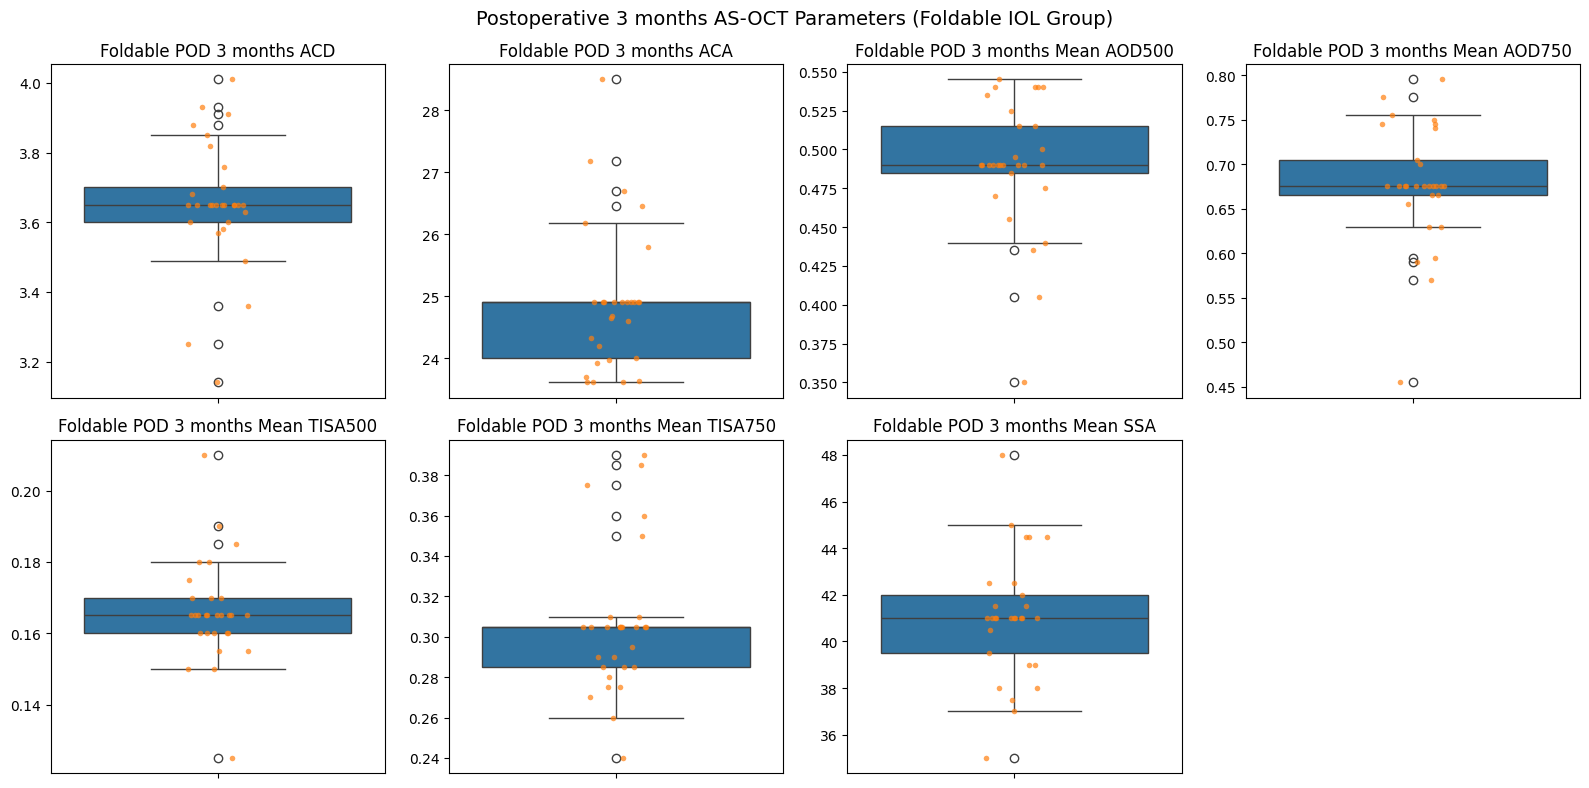

In [338]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, (var, title) in enumerate(zip(variables, titles)):

    sns.boxplot(
        y=pod3mths_foldable_df[var],
        ax=axes[i]
    )

    sns.stripplot(
        y=pod3mths_foldable_df[var],
        ax=axes[i],
        size=4,
        alpha=0.7
    )

    axes[i].set_title(title)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

axes[7].axis('off')

plt.suptitle(
    'Postoperative 3 months AS-OCT Parameters (Foldable IOL Group)',
    fontsize=14
)

plt.tight_layout()
plt.show()

# friedmanchisquare, wilcoxon

In [339]:
from scipy.stats import wilcoxon
from itertools import combinations

variables = {
    'ACD': [
        preop_rigid['ACD'],
        pod1_rigid['ACD'],
        pod6wk_rigid['ACD'],

    ],

    'ACA': [
        preop_rigid['ACA'],
        pod1_rigid['ACA'],
        pod6wk_rigid['ACA'],

    ],

    'Mean AOD500': [
        preop_rigid_df['preop_meanAOD500'],
        pod1_rigid_df['pod1_meanAOD500'],
        pod6wk_rigid_df['pod6wk_meanAOD500'],

    ],

    'Mean AOD750': [
        preop_rigid_df['preop_meanAOD750'],
        pod1_rigid_df['pod1_meanAOD750'],
        pod6wk_rigid_df['pod6wk_meanAOD750'],

    ],

    'Mean TISA500': [
        preop_rigid_df['preop_meanTISA500'],
        pod1_rigid_df['pod1_meanTISA500'],
        pod6wk_rigid_df['pod6wk_meanTISA500'],

    ],

    'Mean TISA750': [
        preop_rigid_df['preop_meanTISA750'],
        pod1_rigid_df['pod1_meanTISA750'],
        pod6wk_rigid_df['pod6wk_meanTISA750'],

    ],

    'Mean SSA': [
        preop_rigid_df['preop_meanSSA'],
        pod1_rigid_df['pod1_meanSSA'],
        pod6wk_rigid_df['pod6wk_meanSSA'],

    ]
}

timepoints = ['Preop', 'POD1', 'POD6wk']

pairwise_results = []

for var, vals in variables.items():

    df_temp = pd.concat(vals, axis=1).dropna()

    for i, j in combinations(range(len(timepoints)), 2):

        stat, p = wilcoxon(
            df_temp.iloc[:, i],
            df_temp.iloc[:, j]
        )

        p_adj = min(p * 6, 1.0)  # Bonferroni correction

        pairwise_results.append({
            'Variable': var,
            'Comparison': f'{timepoints[i]} vs {timepoints[j]}',
            'W statistic': stat,
            'Raw p': round(p, 5),
            'Bonferroni p': round(p_adj, 5),
            'Significant': p_adj < 0.05
        })

pairwise_df = pd.DataFrame(pairwise_results)

pairwise_df

,Variable,Comparison,W statistic,Raw p,Bonferroni p,Significant
0,ACD,Preop vs POD1,0.0,0.00009,0.00053,True
1,ACD,Preop vs POD6wk,0.0,0.00000,0.00001,True
2,ACD,POD1 vs POD6wk,2.0,0.00012,0.00072,True
3,ACA,Preop vs POD1,0.0,0.00000,0.00001,True
4,ACA,Preop vs POD6wk,14.0,0.00021,0.00126,True
5,ACA,POD1 vs POD6wk,26.0,0.00199,0.01191,True
6,Mean AOD500,Preop vs POD1,0.0,0.00009,0.00053,True
7,Mean AOD500,Preop vs POD6wk,13.0,0.00059,0.00355,True
8,Mean AOD500,POD1 vs POD6wk,2.0,0.00012,0.00072,True
9,Mean AOD750,Preop vs POD1,0.0,0.00009,0.00053,True


# Foldable within group

In [340]:
import pandas as pd
from scipy.stats import friedmanchisquare, wilcoxon
from itertools import combinations

variables = {
    'ACD': [
        fold_preop['Preop ACD (F)'],
        fold_pod1['ACD POD1 (F)'],
        fold_pod6wk['ACD 6wk (F)'],
        fold_pod3mths['ACD 3 mth (F)'],

    ],

    'ACA': [
        fold_preop['Preop ACA (F) '],
        fold_pod1['ACA POD1 (F)'],
        fold_pod6wk['ACA POD 6 wk (F)'],
        fold_pod3mths['ACA 3 mth (F)'],
    ],

    'Mean AOD500': [
        preop_foldable_df['preop_meanAOD500'],
        pod1_foldable_df['pod1_meanAOD500'],
        pod6wk_foldable_df['pod6wk_meanAOD500'],
        pod3mths_foldable_df['meanAOD500'],
    ],

    'Mean AOD750': [
        preop_foldable_df['preop_meanAOD750'],
        pod1_foldable_df['pod1_meanAOD750'],
        pod6wk_foldable_df['pod6wk_meanAOD750'],
        pod3mths_foldable_df['meanAOD750'],

    ],

    'Mean TISA500': [
        preop_foldable_df['preop_meanTISA500'],
        pod1_foldable_df['pod1_meanTISA500'],
        pod6wk_foldable_df['pod6wk_meanTISA500'],
        pod3mths_foldable_df['meanTISA500'],

    ],

    'Mean TISA750': [
        preop_foldable_df['preop_meanTISA750'],
        pod1_foldable_df['pod1_meanTISA750'],
        pod6wk_foldable_df['pod6wk_meanTISA750'],
        pod3mths_foldable_df['meanTISA750'],

    ],

    'Mean SSA': [
        preop_foldable_df['preop_meanSSA'],
        pod1_foldable_df['pod1_meanSSA'],
        pod6wk_foldable_df['pod6wk_meanSSA'],
        pod3mths_foldable_df['meanSSA'],

    ]
}

In [341]:
friedman_results = []

n = len(fold_preop)
k = 4

for var, vals in variables.items():

    stat, p = friedmanchisquare(*vals)

    kendalls_w = stat / (n * (k - 1))

    friedman_results.append({
        'Variable': var,
        'Chi-square': round(stat, 3),
        'p-value': round(p, 5),
        'Kendalls_W': round(kendalls_w, 3)
    })

friedman_df = pd.DataFrame(friedman_results)

friedman_df

,Variable,Chi-square,p-value,Kendalls_W
0,ACD,78.446,0.0,0.902
1,ACA,29.814,0.0,0.343
2,Mean AOD500,46.878,0.0,0.539
3,Mean AOD750,70.941,0.0,0.815
4,Mean TISA500,40.742,0.0,0.468
5,Mean TISA750,49.067,0.0,0.564
6,Mean SSA,40.068,0.0,0.461


In [342]:
timepoints = {
    'Preop': 0,
    'POD1': 1,
    'POD6wk': 2,
    'POD3mth': 3
}

pairwise_results = []

for var, vals in variables.items():

    for t1, t2 in combinations(timepoints.keys(), 2):

        stat, p = wilcoxon(
            vals[timepoints[t1]],
            vals[timepoints[t2]]
        )

        p_adj = min(p * 6, 1.0)

        pairwise_results.append({
            'Variable': var,
            'Comparison': f'{t1} vs {t2}',
            'W statistic': stat,
            'Raw p': round(p, 5),
            'Bonferroni p': round(p_adj, 5),
            'Significant': p_adj < 0.05
        })

pairwise_df = pd.DataFrame(pairwise_results)

pairwise_df

,Variable,Comparison,W statistic,Raw p,Bonferroni p,Significant
0,ACD,Preop vs POD1,0.0,0.00000,0.00002,True
1,ACD,Preop vs POD6wk,0.0,0.00000,0.00002,True
2,ACD,Preop vs POD3mth,0.0,0.00000,0.00002,True
3,ACD,POD1 vs POD6wk,7.0,0.00001,0.00003,True
4,ACD,POD1 vs POD3mth,0.0,0.00000,0.00000,True
5,ACD,POD6wk vs POD3mth,37.0,0.00016,0.00094,True
6,ACA,Preop vs POD1,35.0,0.00008,0.00048,True
7,ACA,Preop vs POD6wk,22.0,0.00002,0.00014,True
8,ACA,Preop vs POD3mth,52.0,0.00035,0.00207,True
9,ACA,POD1 vs POD6wk,121.0,0.03692,0.22149,False


In [343]:
with pd.ExcelWriter('Foldable_IOL_Within_Group_Analysis.xlsx') as writer:

    friedman_df.to_excel(
        writer,
        sheet_name='Friedman',
        index=False
    )

    pairwise_df.to_excel(
        writer,
        sheet_name='Posthoc_Wilcoxon',
        index=False
    )

In [344]:
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare, wilcoxon, rankdata
from itertools import combinations

# --------------------------
# Friedman + Posthoc Function
# --------------------------

def within_group_analysis(variables):

    friedman_results = []
    pairwise_results = []

    timepoints = ['Preop', 'POD1', 'POD6wk', 'POD3mth']
    k = 4

    for var, vals in variables.items():

        # Keep only complete cases
        df_temp = pd.concat(vals, axis=1).dropna()

        n = len(df_temp)

        # Friedman test
        chi2, p_friedman = friedmanchisquare(
            df_temp.iloc[:,0],
            df_temp.iloc[:,1],
            df_temp.iloc[:,2],
            df_temp.iloc[:,3]
        )

        kendalls_w = chi2 / (n * (k - 1))

        friedman_results.append({
            'Variable': var,
            'N': n,
            'Chi-square': round(chi2, 3),
            'p-value': round(p_friedman, 5),
            'Kendalls_W': round(kendalls_w, 3)
        })

        # --------------------------
        # Post-hoc Wilcoxon tests
        # --------------------------

        for i, j in combinations(range(4), 2):

            x = df_temp.iloc[:, i]
            y = df_temp.iloc[:, j]

            stat, p = wilcoxon(x, y)

            # Rank-biserial correlation
            diff = x - y
            diff = diff[diff != 0]

            if len(diff) > 0:

                ranks = rankdata(np.abs(diff))

                W_pos = np.sum(ranks[diff > 0])
                W_neg = np.sum(ranks[diff < 0])

                r_rb = (W_pos - W_neg) / (W_pos + W_neg)

            else:
                r_rb = np.nan

            p_adj = min(p * 6, 1.0)

            pairwise_results.append({
                'Variable': var,
                'Comparison':
                    f'{timepoints[i]} vs {timepoints[j]}',
                'W statistic': round(stat, 3),
                'Raw p': round(p, 5),
                'Bonferroni p': round(p_adj, 5),
                'Rank-biserial r': round(r_rb, 3),
                'Significant': p_adj < 0.05
            })

    friedman_df = pd.DataFrame(friedman_results)
    pairwise_df = pd.DataFrame(pairwise_results)

    return friedman_df, pairwise_df

In [345]:
friedman_rigid, posthoc_rigid = within_group_analysis(variables)

In [346]:
friedman_rigid, posthoc_rigid = within_group_analysis(variables)

print("=== FRIEDMAN TEST RESULTS ===")
display(friedman_rigid)

print("\n=== POST-HOC WILCOXON RESULTS ===")
display(posthoc_rigid)

=== FRIEDMAN TEST RESULTS ===


,Variable,N,Chi-square,p-value,Kendalls_W
0,ACD,29,78.446,0.0,0.902
1,ACA,29,29.814,0.0,0.343
2,Mean AOD500,29,46.878,0.0,0.539
3,Mean AOD750,29,70.941,0.0,0.815
4,Mean TISA500,29,40.742,0.0,0.468
5,Mean TISA750,29,49.067,0.0,0.564
6,Mean SSA,29,40.068,0.0,0.461



=== POST-HOC WILCOXON RESULTS ===


,Variable,Comparison,W statistic,Raw p,Bonferroni p,Rank-biserial r,Significant
0,ACD,Preop vs POD1,0.0,0.00000,0.00002,-1.000,True
1,ACD,Preop vs POD6wk,0.0,0.00000,0.00002,-1.000,True
2,ACD,Preop vs POD3mth,0.0,0.00000,0.00002,-1.000,True
3,ACD,POD1 vs POD6wk,7.0,0.00001,0.00003,0.968,True
4,ACD,POD1 vs POD3mth,0.0,0.00000,0.00000,1.000,True
5,ACD,POD6wk vs POD3mth,37.0,0.00016,0.00094,0.818,True
6,ACA,Preop vs POD1,35.0,0.00008,0.00048,-0.839,True
7,ACA,Preop vs POD6wk,22.0,0.00002,0.00014,-0.899,True
8,ACA,Preop vs POD3mth,52.0,0.00035,0.00207,-0.761,True
9,ACA,POD1 vs POD6wk,121.0,0.03692,0.22149,0.444,False


In [347]:
display(
    posthoc_rigid.sort_values(
        ['Variable', 'Comparison']
    ).reset_index(drop=True)
)

,Variable,Comparison,W statistic,Raw p,Bonferroni p,Rank-biserial r,Significant
0,ACA,POD1 vs POD3mth,70.0,0.00089,0.00533,0.678,True
1,ACA,POD1 vs POD6wk,121.0,0.03692,0.22149,0.444,False
2,ACA,POD6wk vs POD3mth,97.0,0.00917,0.05502,0.554,False
3,ACA,Preop vs POD1,35.0,0.00008,0.00048,-0.839,True
4,ACA,Preop vs POD3mth,52.0,0.00035,0.00207,-0.761,True
5,ACA,Preop vs POD6wk,22.0,0.00002,0.00014,-0.899,True
6,ACD,POD1 vs POD3mth,0.0,0.00000,0.00000,1.000,True
7,ACD,POD1 vs POD6wk,7.0,0.00001,0.00003,0.968,True
8,ACD,POD6wk vs POD3mth,37.0,0.00016,0.00094,0.818,True
9,ACD,Preop vs POD1,0.0,0.00000,0.00002,-1.000,True


In [348]:
friedman_foldable, posthoc_foldable = within_group_analysis(
    variables
)

print("=== FRIEDMAN TEST RESULTS ===")
display(friedman_foldable)

print("\n=== POST-HOC WILCOXON RESULTS ===")
display(posthoc_foldable)

=== FRIEDMAN TEST RESULTS ===


,Variable,N,Chi-square,p-value,Kendalls_W
0,ACD,29,78.446,0.0,0.902
1,ACA,29,29.814,0.0,0.343
2,Mean AOD500,29,46.878,0.0,0.539
3,Mean AOD750,29,70.941,0.0,0.815
4,Mean TISA500,29,40.742,0.0,0.468
5,Mean TISA750,29,49.067,0.0,0.564
6,Mean SSA,29,40.068,0.0,0.461



=== POST-HOC WILCOXON RESULTS ===


,Variable,Comparison,W statistic,Raw p,Bonferroni p,Rank-biserial r,Significant
0,ACD,Preop vs POD1,0.0,0.00000,0.00002,-1.000,True
1,ACD,Preop vs POD6wk,0.0,0.00000,0.00002,-1.000,True
2,ACD,Preop vs POD3mth,0.0,0.00000,0.00002,-1.000,True
3,ACD,POD1 vs POD6wk,7.0,0.00001,0.00003,0.968,True
4,ACD,POD1 vs POD3mth,0.0,0.00000,0.00000,1.000,True
5,ACD,POD6wk vs POD3mth,37.0,0.00016,0.00094,0.818,True
6,ACA,Preop vs POD1,35.0,0.00008,0.00048,-0.839,True
7,ACA,Preop vs POD6wk,22.0,0.00002,0.00014,-0.899,True
8,ACA,Preop vs POD3mth,52.0,0.00035,0.00207,-0.761,True
9,ACA,POD1 vs POD6wk,121.0,0.03692,0.22149,0.444,False


In [349]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

display(friedman_rigid)
display(posthoc_rigid)

,Variable,N,Chi-square,p-value,Kendalls_W
0,ACD,29,78.446,0.0,0.902
1,ACA,29,29.814,0.0,0.343
2,Mean AOD500,29,46.878,0.0,0.539
3,Mean AOD750,29,70.941,0.0,0.815
4,Mean TISA500,29,40.742,0.0,0.468
5,Mean TISA750,29,49.067,0.0,0.564
6,Mean SSA,29,40.068,0.0,0.461


,Variable,Comparison,W statistic,Raw p,Bonferroni p,Rank-biserial r,Significant
0,ACD,Preop vs POD1,0.0,0.00000,0.00002,-1.000,True
1,ACD,Preop vs POD6wk,0.0,0.00000,0.00002,-1.000,True
2,ACD,Preop vs POD3mth,0.0,0.00000,0.00002,-1.000,True
3,ACD,POD1 vs POD6wk,7.0,0.00001,0.00003,0.968,True
4,ACD,POD1 vs POD3mth,0.0,0.00000,0.00000,1.000,True
5,ACD,POD6wk vs POD3mth,37.0,0.00016,0.00094,0.818,True
6,ACA,Preop vs POD1,35.0,0.00008,0.00048,-0.839,True
7,ACA,Preop vs POD6wk,22.0,0.00002,0.00014,-0.899,True
8,ACA,Preop vs POD3mth,52.0,0.00035,0.00207,-0.761,True
9,ACA,POD1 vs POD6wk,121.0,0.03692,0.22149,0.444,False


In [350]:
significant_posthoc = posthoc_rigid[
    posthoc_rigid['Significant'] == True
]

display(significant_posthoc)

,Variable,Comparison,W statistic,Raw p,Bonferroni p,Rank-biserial r,Significant
0,ACD,Preop vs POD1,0.0,0.00000,0.00002,-1.000,True
1,ACD,Preop vs POD6wk,0.0,0.00000,0.00002,-1.000,True
2,ACD,Preop vs POD3mth,0.0,0.00000,0.00002,-1.000,True
3,ACD,POD1 vs POD6wk,7.0,0.00001,0.00003,0.968,True
4,ACD,POD1 vs POD3mth,0.0,0.00000,0.00000,1.000,True
5,ACD,POD6wk vs POD3mth,37.0,0.00016,0.00094,0.818,True
6,ACA,Preop vs POD1,35.0,0.00008,0.00048,-0.839,True
7,ACA,Preop vs POD6wk,22.0,0.00002,0.00014,-0.899,True
8,ACA,Preop vs POD3mth,52.0,0.00035,0.00207,-0.761,True
10,ACA,POD1 vs POD3mth,70.0,0.00089,0.00533,0.678,True


In [351]:
def interpret_r(r):

    r = abs(r)

    if r < 0.10:
        return 'Negligible'
    elif r < 0.30:
        return 'Small'
    elif r < 0.50:
        return 'Moderate'
    else:
        return 'Large'

posthoc_rigid['Effect size'] = (
    posthoc_rigid['Rank-biserial r']
    .apply(interpret_r)
)

display(posthoc_rigid)

,Variable,Comparison,W statistic,Raw p,Bonferroni p,Rank-biserial r,Significant,Effect size
0,ACD,Preop vs POD1,0.0,0.00000,0.00002,-1.000,True,Large
1,ACD,Preop vs POD6wk,0.0,0.00000,0.00002,-1.000,True,Large
2,ACD,Preop vs POD3mth,0.0,0.00000,0.00002,-1.000,True,Large
3,ACD,POD1 vs POD6wk,7.0,0.00001,0.00003,0.968,True,Large
4,ACD,POD1 vs POD3mth,0.0,0.00000,0.00000,1.000,True,Large
5,ACD,POD6wk vs POD3mth,37.0,0.00016,0.00094,0.818,True,Large
6,ACA,Preop vs POD1,35.0,0.00008,0.00048,-0.839,True,Large
7,ACA,Preop vs POD6wk,22.0,0.00002,0.00014,-0.899,True,Large
8,ACA,Preop vs POD3mth,52.0,0.00035,0.00207,-0.761,True,Large
9,ACA,POD1 vs POD6wk,121.0,0.03692,0.22149,0.444,False,Moderate


In [352]:
# ---------- RIGID ----------
rigid_delta = pd.DataFrame()

rigid_delta['dACD_POD1']   = pod1_rigid['ACD'] - preop_rigid['ACD']
rigid_delta['dACA_POD1']   = pod1_rigid['ACA'] - preop_rigid['ACA']

rigid_delta['dAOD500_POD1'] = pod1_rigid_df['pod1_meanAOD500'] - preop_rigid_df['preop_meanAOD500']
rigid_delta['dAOD750_POD1'] = pod1_rigid_df['pod1_meanAOD750'] - preop_rigid_df['preop_meanAOD750']

rigid_delta['dTISA500_POD1'] = pod1_rigid_df['pod1_meanTISA500'] - preop_rigid_df['preop_meanTISA500']
rigid_delta['dTISA750_POD1'] = pod1_rigid_df['pod1_meanTISA750'] - preop_rigid_df['preop_meanTISA750']

rigid_delta['dSSA_POD1'] = pod1_rigid_df['pod1_meanSSA'] - preop_rigid_df['preop_meanSSA']


# ---------- FOLDABLE ----------
fold_delta = pd.DataFrame()

fold_delta['dACD_POD1'] = fold_pod1['ACD POD1 (F)'] - fold_preop['Preop ACD (F)']
fold_delta['dACA_POD1'] = fold_pod1['ACA POD1 (F)'] - fold_preop['Preop ACA (F) ']

fold_delta['dAOD500_POD1'] = pod1_foldable_df['pod1_meanAOD500'] - preop_foldable_df['preop_meanAOD500']
fold_delta['dAOD750_POD1'] = pod1_foldable_df['pod1_meanAOD750'] - preop_foldable_df['preop_meanAOD750']

fold_delta['dTISA500_POD1'] = pod1_foldable_df['pod1_meanTISA500'] - preop_foldable_df['preop_meanTISA500']
fold_delta['dTISA750_POD1'] = pod1_foldable_df['pod1_meanTISA750'] - preop_foldable_df['preop_meanTISA750']

fold_delta['dSSA_POD1'] = pod1_foldable_df['pod1_meanSSA'] - preop_foldable_df['preop_meanSSA']

In [353]:
import pandas as pd
import numpy as np

from scipy.stats import (
    shapiro,
    ttest_ind,
    mannwhitneyu
)

results = []

variables = fold_delta.columns

for var in variables:

    g1 = fold_delta[var].dropna()
    g2 = rigid_delta[var].dropna()

    p1 = shapiro(g1)[1]
    p2 = shapiro(g2)[1]

    normal = (p1 > 0.05) and (p2 > 0.05)

    if normal:

        stat, p = ttest_ind(g1, g2, equal_var=False)

        pooled_sd = np.sqrt(
            ((len(g1)-1)*g1.var(ddof=1) +
             (len(g2)-1)*g2.var(ddof=1))
            /
            (len(g1)+len(g2)-2)
        )

        effect = (g1.mean()-g2.mean())/pooled_sd

        effect_type = "Cohen's d"

    else:

        stat, p = mannwhitneyu(
            g1,
            g2,
            alternative='two-sided'
        )

        n1 = len(g1)
        n2 = len(g2)

        effect = 1 - (2*stat)/(n1*n2)

        effect_type = "Rank-biserial r"

    results.append([
        var,
        effect_type,
        round(effect,3),
        round(p,4)
    ])

between_group = pd.DataFrame(
    results,
    columns=[
        'Variable',
        'Effect size type',
        'Effect size',
        'p-value'
    ]
)

between_group

,Variable,Effect size type,Effect size,p-value
0,dACD_POD1,Rank-biserial r,-0.124,0.4400
1,dACA_POD1,Cohen's d,-0.355,0.1872
2,dAOD500_POD1,Cohen's d,-0.095,0.7302
3,dAOD750_POD1,Cohen's d,0.573,0.0472
4,dTISA500_POD1,Rank-biserial r,-0.086,0.5961
5,dTISA750_POD1,Rank-biserial r,-0.200,0.2114
6,dSSA_POD1,Cohen's d,-0.134,0.6193


In [354]:
between_group['Bonferroni p'] = np.minimum(
    between_group['p-value'] * len(between_group),
    1.0
)

between_group['Significant'] = (
    between_group['Bonferroni p'] < 0.05
)

between_group

,Variable,Effect size type,Effect size,p-value,Bonferroni p,Significant
0,dACD_POD1,Rank-biserial r,-0.124,0.4400,1.0000,False
1,dACA_POD1,Cohen's d,-0.355,0.1872,1.0000,False
2,dAOD500_POD1,Cohen's d,-0.095,0.7302,1.0000,False
3,dAOD750_POD1,Cohen's d,0.573,0.0472,0.3304,False
4,dTISA500_POD1,Rank-biserial r,-0.086,0.5961,1.0000,False
5,dTISA750_POD1,Rank-biserial r,-0.200,0.2114,1.0000,False
6,dSSA_POD1,Cohen's d,-0.134,0.6193,1.0000,False


## Line graphs

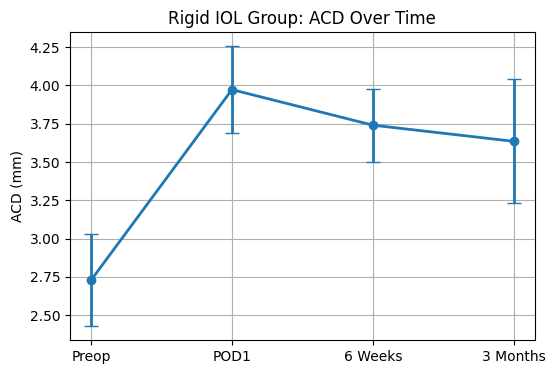

In [355]:
import matplotlib.pyplot as plt
import numpy as np

timepoints = ['Preop', 'POD1', '6 Weeks', '3 Months']

means = [
    preop_rigid['ACD'].mean(),
    pod1_rigid['ACD'].mean(),
    pod6wk_rigid['ACD'].mean(),
    pod3mth_rigid['ACD'].mean()
]

sds = [
    preop_rigid['ACD'].std(),
    pod1_rigid['ACD'].std(),
    pod6wk_rigid['ACD'].std(),
    pod3mth_rigid['ACD'].std()
]

plt.figure(figsize=(6,4))
plt.errorbar(timepoints, means, yerr=sds, marker='o', capsize=5, linewidth=2)
plt.ylabel('ACD (mm)')
plt.title('Rigid IOL Group: ACD Over Time')
plt.grid(True)
plt.show()

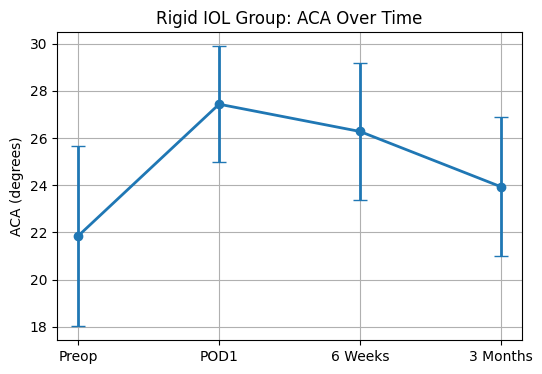

In [356]:
means = [
    preop_rigid['ACA'].mean(),
    pod1_rigid['ACA'].mean(),
    pod6wk_rigid['ACA'].mean(),
    pod3mth_rigid['ACA'].mean()
]

sds = [
    preop_rigid['ACA'].std(),
    pod1_rigid['ACA'].std(),
    pod6wk_rigid['ACA'].std(),
    pod3mth_rigid['ACA'].std()
]

plt.figure(figsize=(6,4))
plt.errorbar(timepoints, means, yerr=sds, marker='o', capsize=5, linewidth=2)
plt.ylabel('ACA (degrees)')
plt.title('Rigid IOL Group: ACA Over Time')
plt.grid(True)
plt.show()

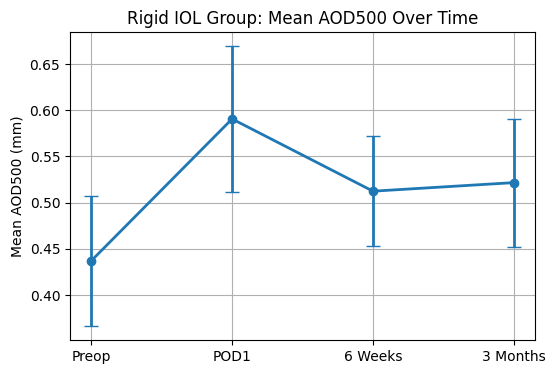

In [357]:
means = [
    preop_rigid_df['preop_meanAOD500'].mean(),
    pod1_rigid_df['pod1_meanAOD500'].mean(),
    pod6wk_rigid_df['pod6wk_meanAOD500'].mean(),
    pod3mth_rigid_df['pod3mth_meanAOD500'].mean()
]

sds = [
    preop_rigid_df['preop_meanAOD500'].std(),
    pod1_rigid_df['pod1_meanAOD500'].std(),
    pod6wk_rigid_df['pod6wk_meanAOD500'].std(),
    pod3mth_rigid_df['pod3mth_meanAOD500'].std()
]

plt.figure(figsize=(6,4))
plt.errorbar(timepoints, means, yerr=sds, marker='o', capsize=5, linewidth=2)
plt.ylabel('Mean AOD500 (mm)')
plt.title('Rigid IOL Group: Mean AOD500 Over Time')
plt.grid(True)
plt.show()

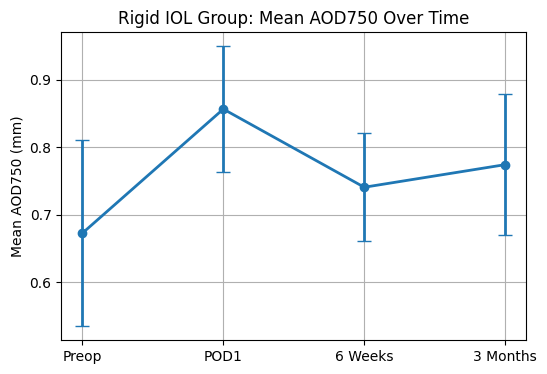

In [358]:
means = [
    preop_rigid_df['preop_meanAOD750'].mean(),
    pod1_rigid_df['pod1_meanAOD750'].mean(),
    pod6wk_rigid_df['pod6wk_meanAOD750'].mean(),
    pod3mth_rigid_df['pod3mth_meanAOD750'].mean()
]

sds = [
    preop_rigid_df['preop_meanAOD750'].std(),
    pod1_rigid_df['pod1_meanAOD750'].std(),
    pod6wk_rigid_df['pod6wk_meanAOD750'].std(),
    pod3mth_rigid_df['pod3mth_meanAOD750'].std()
]

plt.figure(figsize=(6,4))
plt.errorbar(timepoints, means, yerr=sds, marker='o', capsize=5, linewidth=2)
plt.ylabel('Mean AOD750 (mm)')
plt.title('Rigid IOL Group: Mean AOD750 Over Time')
plt.grid(True)
plt.show()

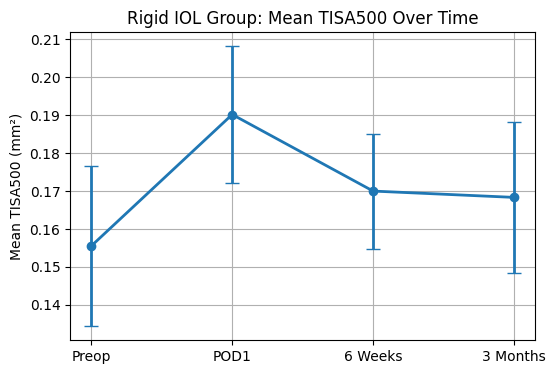

In [359]:
means = [
    preop_rigid_df['preop_meanTISA500'].mean(),
    pod1_rigid_df['pod1_meanTISA500'].mean(),
    pod6wk_rigid_df['pod6wk_meanTISA500'].mean(),
    pod3mth_rigid_df['pod3mth_meanTISA500'].mean()
]

sds = [
    preop_rigid_df['preop_meanTISA500'].std(),
    pod1_rigid_df['pod1_meanTISA500'].std(),
    pod6wk_rigid_df['pod6wk_meanTISA500'].std(),
    pod3mth_rigid_df['pod3mth_meanTISA500'].std()
]

plt.figure(figsize=(6,4))
plt.errorbar(timepoints, means, yerr=sds, marker='o', capsize=5, linewidth=2)
plt.ylabel('Mean TISA500 (mm²)')
plt.title('Rigid IOL Group: Mean TISA500 Over Time')
plt.grid(True)
plt.show()

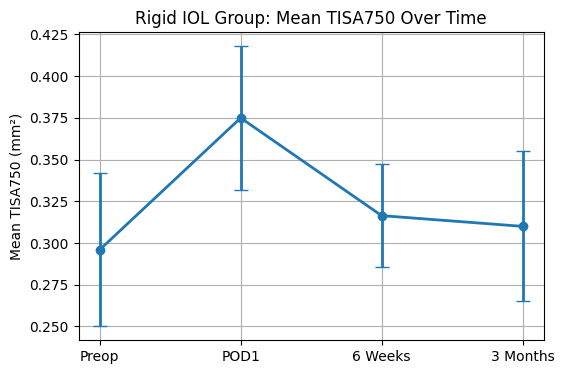

In [360]:
means = [
    preop_rigid_df['preop_meanTISA750'].mean(),
    pod1_rigid_df['pod1_meanTISA750'].mean(),
    pod6wk_rigid_df['pod6wk_meanTISA750'].mean(),
    pod3mth_rigid_df['pod3mth_meanTISA750'].mean()
]

sds = [
    preop_rigid_df['preop_meanTISA750'].std(),
    pod1_rigid_df['pod1_meanTISA750'].std(),
    pod6wk_rigid_df['pod6wk_meanTISA750'].std(),
    pod3mth_rigid_df['pod3mth_meanTISA750'].std()
]

plt.figure(figsize=(6,4))
plt.errorbar(timepoints, means, yerr=sds, marker='o', capsize=5, linewidth=2)
plt.ylabel('Mean TISA750 (mm²)')
plt.title('Rigid IOL Group: Mean TISA750 Over Time')
plt.grid(True)
plt.show()

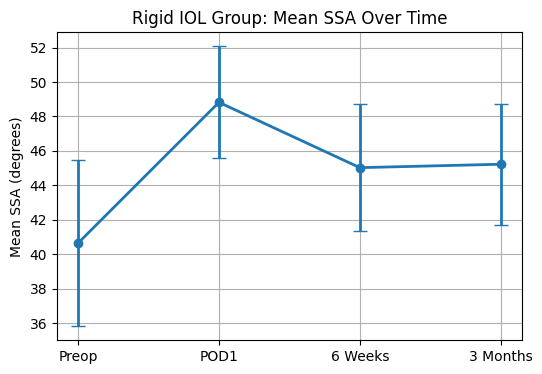

In [361]:
means = [
    preop_rigid_df['preop_meanSSA'].mean(),
    pod1_rigid_df['pod1_meanSSA'].mean(),
    pod6wk_rigid_df['pod6wk_meanSSA'].mean(),
    pod3mth_rigid_df['pod3mth_meanSSA'].mean()
]

sds = [
    preop_rigid_df['preop_meanSSA'].std(),
    pod1_rigid_df['pod1_meanSSA'].std(),
    pod6wk_rigid_df['pod6wk_meanSSA'].std(),
    pod3mth_rigid_df['pod3mth_meanSSA'].std()
]

plt.figure(figsize=(6,4))
plt.errorbar(timepoints, means, yerr=sds, marker='o', capsize=5, linewidth=2)
plt.ylabel('Mean SSA (degrees)')
plt.title('Rigid IOL Group: Mean SSA Over Time')
plt.grid(True)
plt.show()

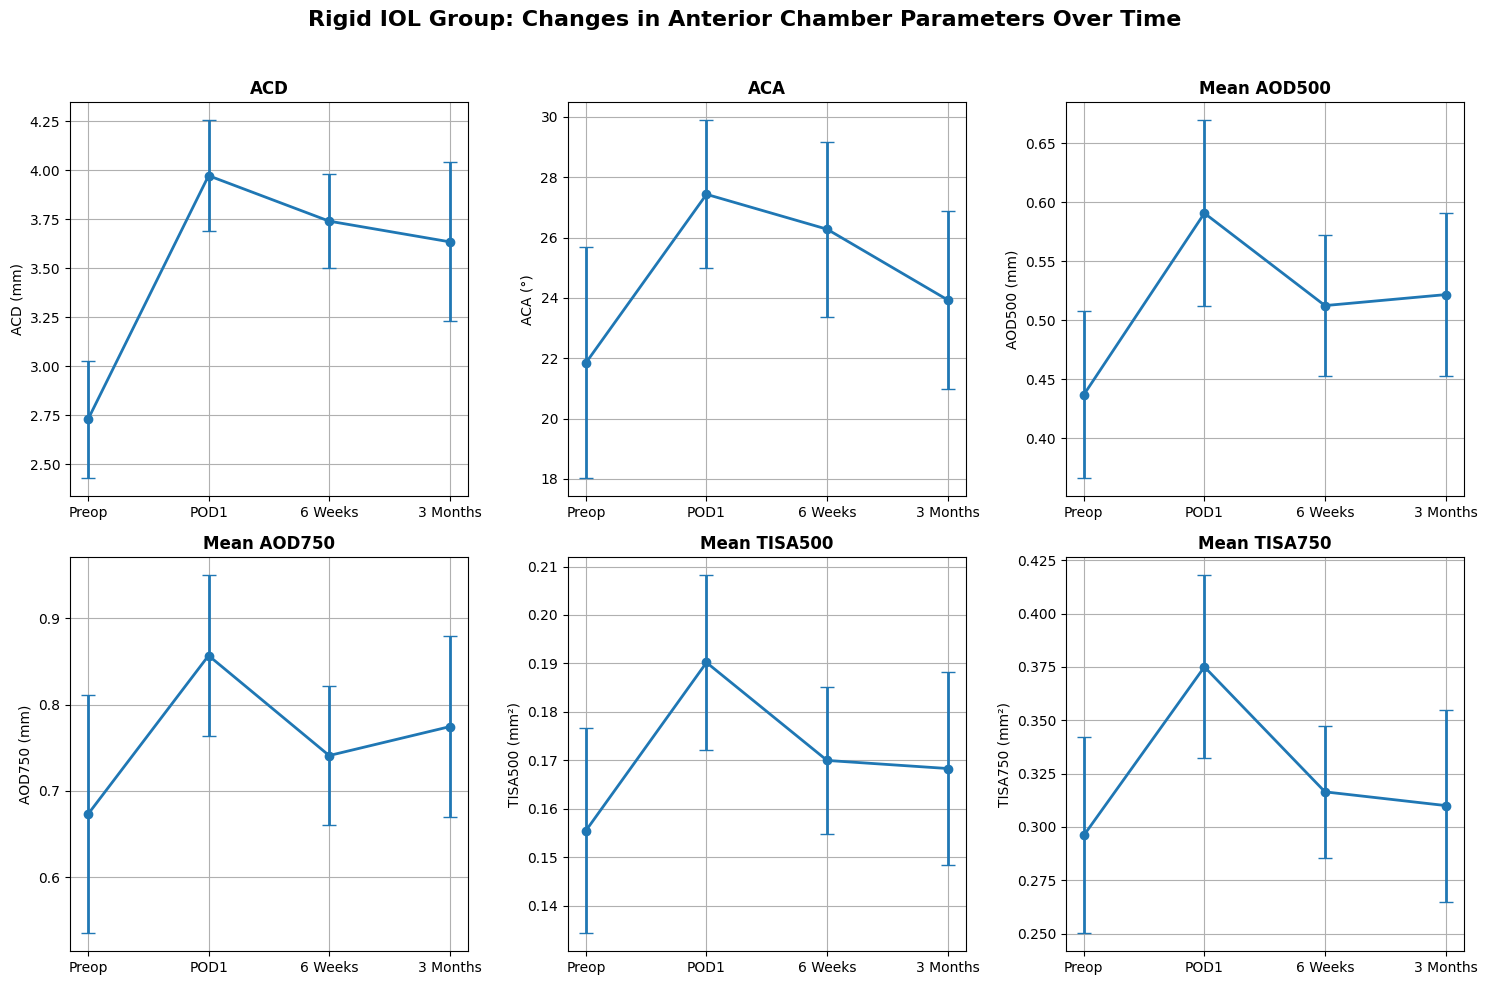

In [362]:
import matplotlib.pyplot as plt
import numpy as np

timepoints = ['Preop', 'POD1', '6 Weeks', '3 Months']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

parameters = [
    ('ACD',
     [preop_rigid['ACD'], pod1_rigid['ACD'],
      pod6wk_rigid['ACD'], pod3mth_rigid['ACD']],
     'ACD (mm)'),

    ('ACA',
     [preop_rigid['ACA'], pod1_rigid['ACA'],
      pod6wk_rigid['ACA'], pod3mth_rigid['ACA']],
     'ACA (°)'),

    ('Mean AOD500',
     [preop_rigid_df['preop_meanAOD500'],
      pod1_rigid_df['pod1_meanAOD500'],
      pod6wk_rigid_df['pod6wk_meanAOD500'],
      pod3mth_rigid_df['pod3mth_meanAOD500']],
     'AOD500 (mm)'),

    ('Mean AOD750',
     [preop_rigid_df['preop_meanAOD750'],
      pod1_rigid_df['pod1_meanAOD750'],
      pod6wk_rigid_df['pod6wk_meanAOD750'],
      pod3mth_rigid_df['pod3mth_meanAOD750']],
     'AOD750 (mm)'),

    ('Mean TISA500',
     [preop_rigid_df['preop_meanTISA500'],
      pod1_rigid_df['pod1_meanTISA500'],
      pod6wk_rigid_df['pod6wk_meanTISA500'],
      pod3mth_rigid_df['pod3mth_meanTISA500']],
     'TISA500 (mm²)'),

    ('Mean TISA750',
     [preop_rigid_df['preop_meanTISA750'],
      pod1_rigid_df['pod1_meanTISA750'],
      pod6wk_rigid_df['pod6wk_meanTISA750'],
      pod3mth_rigid_df['pod3mth_meanTISA750']],
     'TISA750 (mm²)')
]

for ax, (title, data, ylabel) in zip(axes.flat, parameters):

    means = [x.mean() for x in data]
    sds = [x.std() for x in data]

    ax.errorbar(
        timepoints,
        means,
        yerr=sds,
        marker='o',
        linewidth=2,
        capsize=5
    )

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.grid(True)

plt.suptitle(
    'Rigid IOL Group: Changes in Anterior Chamber Parameters Over Time',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

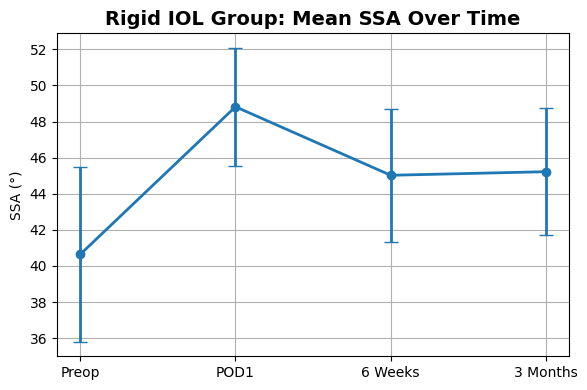

In [363]:
import matplotlib.pyplot as plt

means = [
    preop_rigid_df['preop_meanSSA'].mean(),
    pod1_rigid_df['pod1_meanSSA'].mean(),
    pod6wk_rigid_df['pod6wk_meanSSA'].mean(),
    pod3mth_rigid_df['pod3mth_meanSSA'].mean()
]

sds = [
    preop_rigid_df['preop_meanSSA'].std(),
    pod1_rigid_df['pod1_meanSSA'].std(),
    pod6wk_rigid_df['pod6wk_meanSSA'].std(),
    pod3mth_rigid_df['pod3mth_meanSSA'].std()
]

plt.figure(figsize=(6,4))

plt.errorbar(
    ['Preop','POD1','6 Weeks','3 Months'],
    means,
    yerr=sds,
    marker='o',
    linewidth=2,
    capsize=5
)

plt.title('Rigid IOL Group: Mean SSA Over Time',
          fontsize=14,
          fontweight='bold')
plt.ylabel('SSA (°)')
plt.grid(True)
plt.tight_layout()
plt.show()

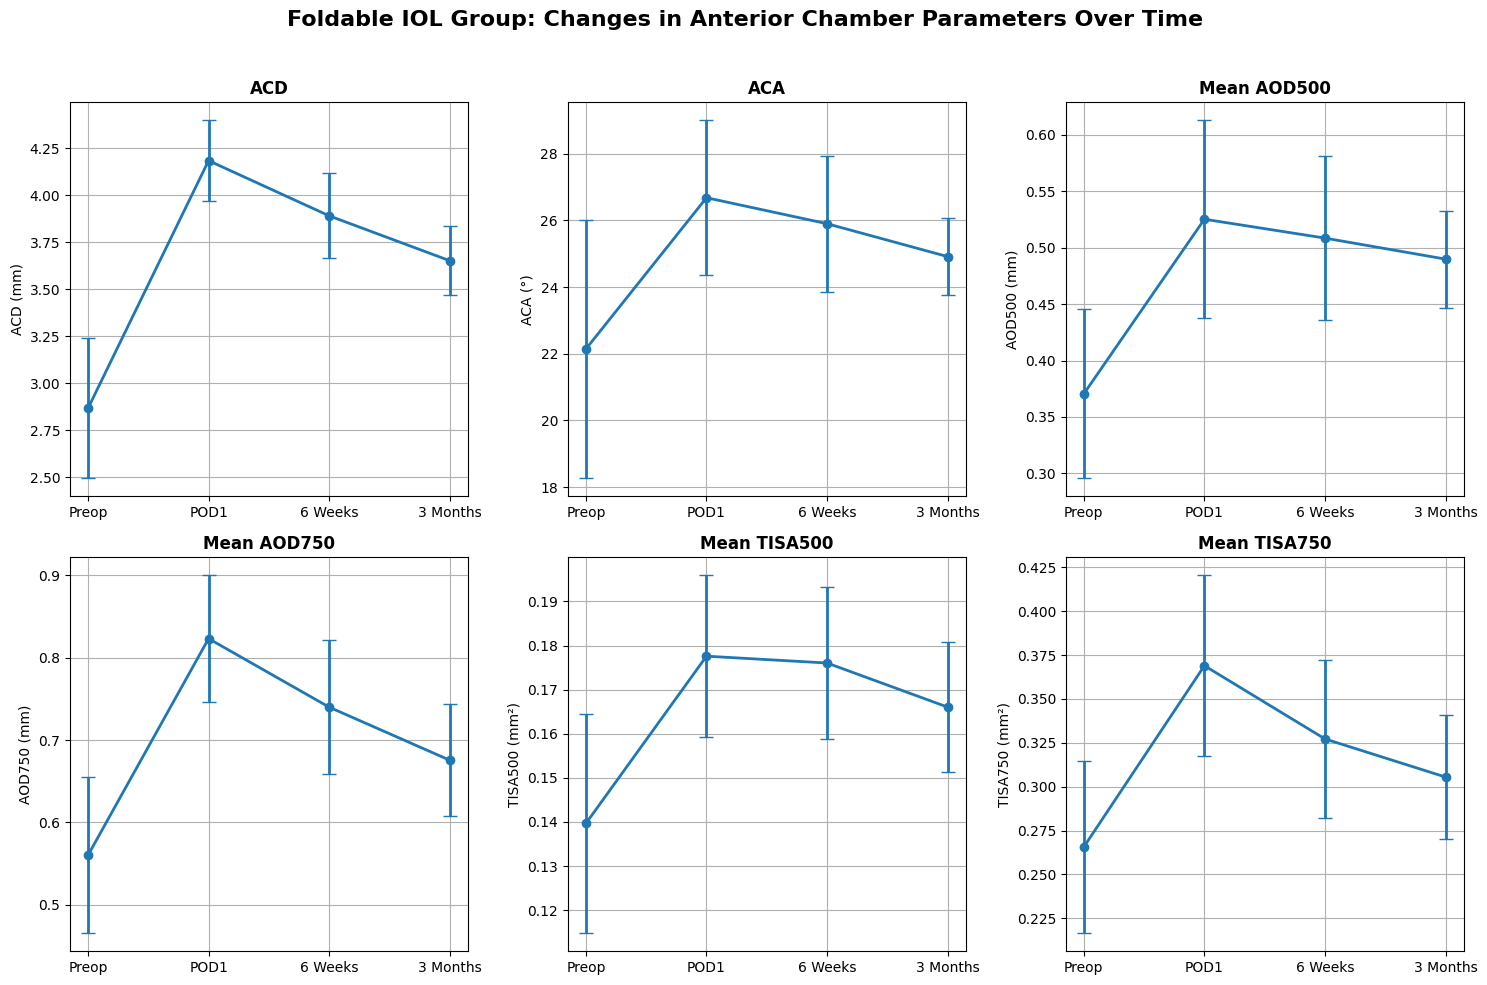

In [364]:
import matplotlib.pyplot as plt
import numpy as np

timepoints = ['Preop', 'POD1', '6 Weeks', '3 Months']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

parameters = [
    ('ACD',
     [fold_preop['Preop ACD (F)'],
      fold_pod1['ACD POD1 (F)'],
      fold_pod6wk['ACD 6wk (F)'],
      fold_pod3mths['ACD 3 mth (F)']],
     'ACD (mm)'),

    ('ACA',
     [fold_preop['Preop ACA (F) '],
      fold_pod1['ACA POD1 (F)'],
      fold_pod6wk['ACA POD 6 wk (F)'],
      fold_pod3mths['ACA 3 mth (F)']],
     'ACA (°)'),

    ('Mean AOD500',
     [preop_foldable_df['preop_meanAOD500'],
      pod1_foldable_df['pod1_meanAOD500'],
      pod6wk_foldable_df['pod6wk_meanAOD500'],
      pod3mths_foldable_df['meanAOD500']],
     'AOD500 (mm)'),

    ('Mean AOD750',
     [preop_foldable_df['preop_meanAOD750'],
      pod1_foldable_df['pod1_meanAOD750'],
      pod6wk_foldable_df['pod6wk_meanAOD750'],
      pod3mths_foldable_df['meanAOD750']],
     'AOD750 (mm)'),

    ('Mean TISA500',
     [preop_foldable_df['preop_meanTISA500'],
      pod1_foldable_df['pod1_meanTISA500'],
      pod6wk_foldable_df['pod6wk_meanTISA500'],
      pod3mths_foldable_df['meanTISA500']],
     'TISA500 (mm²)'),

    ('Mean TISA750',
     [preop_foldable_df['preop_meanTISA750'],
      pod1_foldable_df['pod1_meanTISA750'],
      pod6wk_foldable_df['pod6wk_meanTISA750'],
      pod3mths_foldable_df['meanTISA750']],
     'TISA750 (mm²)')
]

for ax, (title, data, ylabel) in zip(axes.flat, parameters):

    means = [x.mean() for x in data]
    sds = [x.std() for x in data]

    ax.errorbar(
        timepoints,
        means,
        yerr=sds,
        marker='o',
        linewidth=2,
        capsize=5
    )

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.grid(True)

plt.suptitle(
    'Foldable IOL Group: Changes in Anterior Chamber Parameters Over Time',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

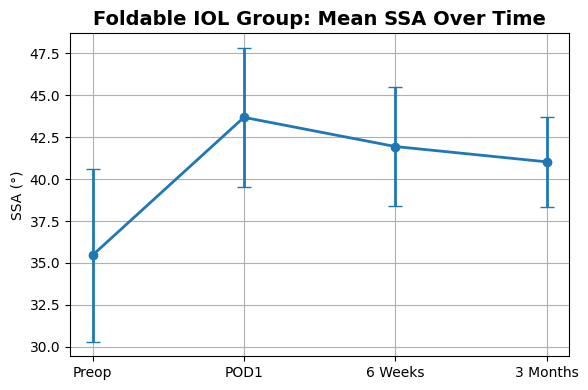

In [365]:
import matplotlib.pyplot as plt

means = [
    preop_foldable_df['preop_meanSSA'].mean(),
    pod1_foldable_df['pod1_meanSSA'].mean(),
    pod6wk_foldable_df['pod6wk_meanSSA'].mean(),
    pod3mths_foldable_df['meanSSA'].mean()
]

sds = [
    preop_foldable_df['preop_meanSSA'].std(),
    pod1_foldable_df['pod1_meanSSA'].std(),
    pod6wk_foldable_df['pod6wk_meanSSA'].std(),
    pod3mths_foldable_df['meanSSA'].std()
]

plt.figure(figsize=(6,4))

plt.errorbar(
    ['Preop', 'POD1', '6 Weeks', '3 Months'],
    means,
    yerr=sds,
    marker='o',
    linewidth=2,
    capsize=5
)

plt.title(
    'Foldable IOL Group: Mean SSA Over Time',
    fontsize=14,
    fontweight='bold'
)

plt.ylabel('SSA (°)')
plt.grid(True)
plt.tight_layout()
plt.show()

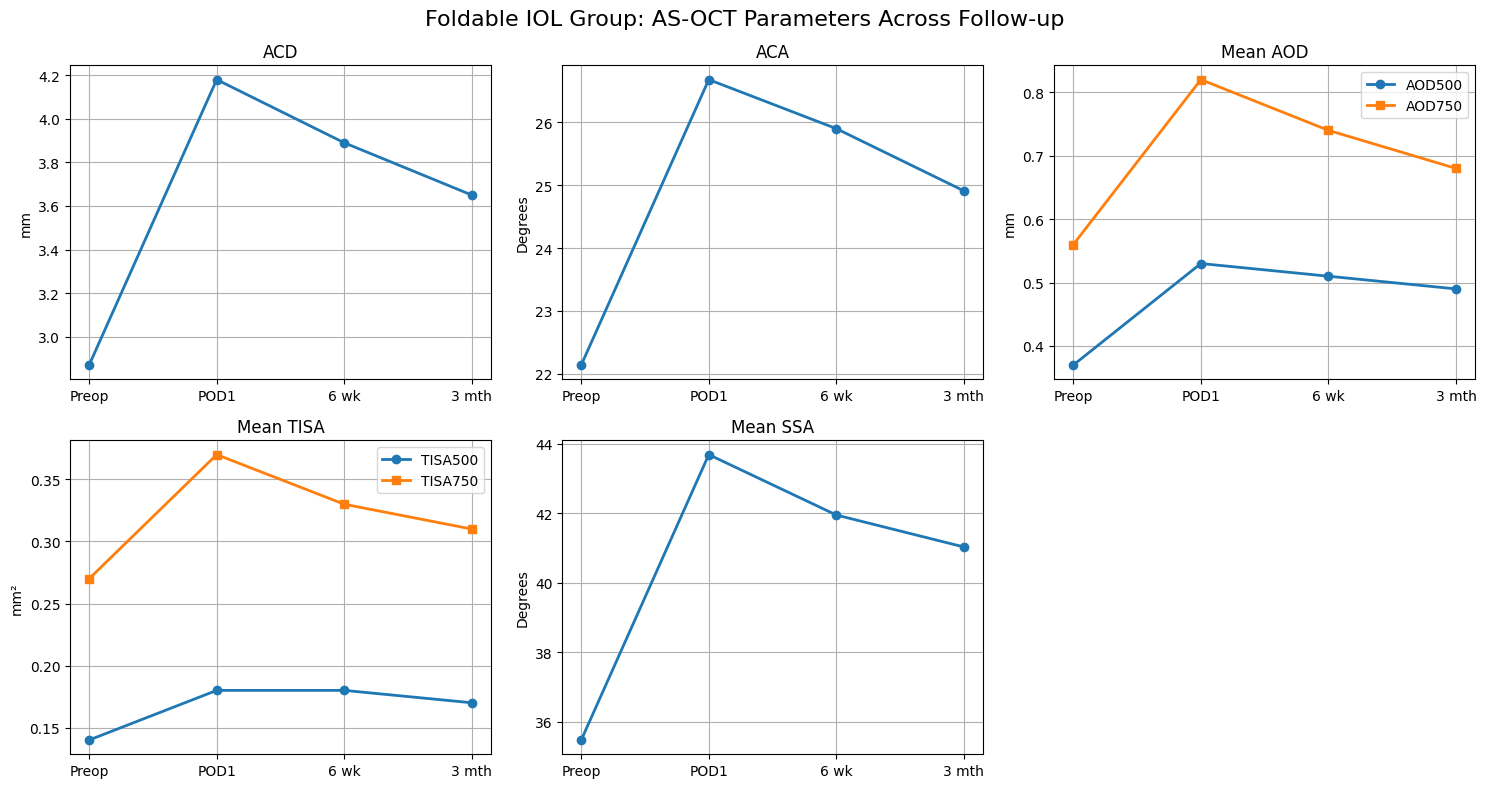

In [366]:
import matplotlib.pyplot as plt
import numpy as np

timepoints = ['Preop', 'POD1', '6 wk', '3 mth']

# Foldable IOL group means
acd = [2.87, 4.18, 3.89, 3.65]
aca = [22.14, 26.68, 25.90, 24.91]

aod500 = [0.37, 0.53, 0.51, 0.49]
aod750 = [0.56, 0.82, 0.74, 0.68]

tisa500 = [0.14, 0.18, 0.18, 0.17]
tisa750 = [0.27, 0.37, 0.33, 0.31]

ssa = [35.47, 43.69, 41.95, 41.03]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# ACD
axes[0,0].plot(timepoints, acd, marker='o', linewidth=2)
axes[0,0].set_title('ACD')
axes[0,0].set_ylabel('mm')
axes[0,0].grid(True)

# ACA
axes[0,1].plot(timepoints, aca, marker='o', linewidth=2)
axes[0,1].set_title('ACA')
axes[0,1].set_ylabel('Degrees')
axes[0,1].grid(True)

# Mean AOD
axes[0,2].plot(timepoints, aod500, marker='o', linewidth=2, label='AOD500')
axes[0,2].plot(timepoints, aod750, marker='s', linewidth=2, label='AOD750')
axes[0,2].set_title('Mean AOD')
axes[0,2].set_ylabel('mm')
axes[0,2].legend()
axes[0,2].grid(True)

# Mean TISA
axes[1,0].plot(timepoints, tisa500, marker='o', linewidth=2, label='TISA500')
axes[1,0].plot(timepoints, tisa750, marker='s', linewidth=2, label='TISA750')
axes[1,0].set_title('Mean TISA')
axes[1,0].set_ylabel('mm²')
axes[1,0].legend()
axes[1,0].grid(True)

# SSA
axes[1,1].plot(timepoints, ssa, marker='o', linewidth=2)
axes[1,1].set_title('Mean SSA')
axes[1,1].set_ylabel('Degrees')
axes[1,1].grid(True)

# Empty panel for symmetry
axes[1,2].axis('off')

fig.suptitle('Foldable IOL Group: AS-OCT Parameters Across Follow-up', fontsize=16)

plt.tight_layout()
plt.show()

In [367]:
# Mean ± SD values from your descriptive tables

acd_mean = [2.87, 4.18, 3.89, 3.65]
acd_sd   = [0.37, 0.22, 0.23, 0.19]

aca_mean = [22.14, 26.68, 25.90, 24.91]
aca_sd   = [3.88, 2.32, 2.04, 1.16]

aod500_mean = [0.37, 0.53, 0.51, 0.49]
aod500_sd   = [0.07, 0.09, 0.07, 0.04]

aod750_mean = [0.56, 0.82, 0.74, 0.68]
aod750_sd   = [0.09, 0.08, 0.08, 0.07]

tisa500_mean = [0.14, 0.18, 0.18, 0.17]
tisa500_sd   = [0.02, 0.02, 0.02, 0.01]

tisa750_mean = [0.27, 0.37, 0.33, 0.31]
tisa750_sd   = [0.05, 0.05, 0.04, 0.04]

ssa_mean = [35.47, 43.69, 41.95, 41.03]
ssa_sd   = [5.16, 4.14, 3.56, 2.68]

In [368]:
axes[0,0].errorbar(timepoints, acd_mean, yerr=acd_sd,
                   marker='o', capsize=4, linewidth=2)

<ErrorbarContainer object of 3 artists>

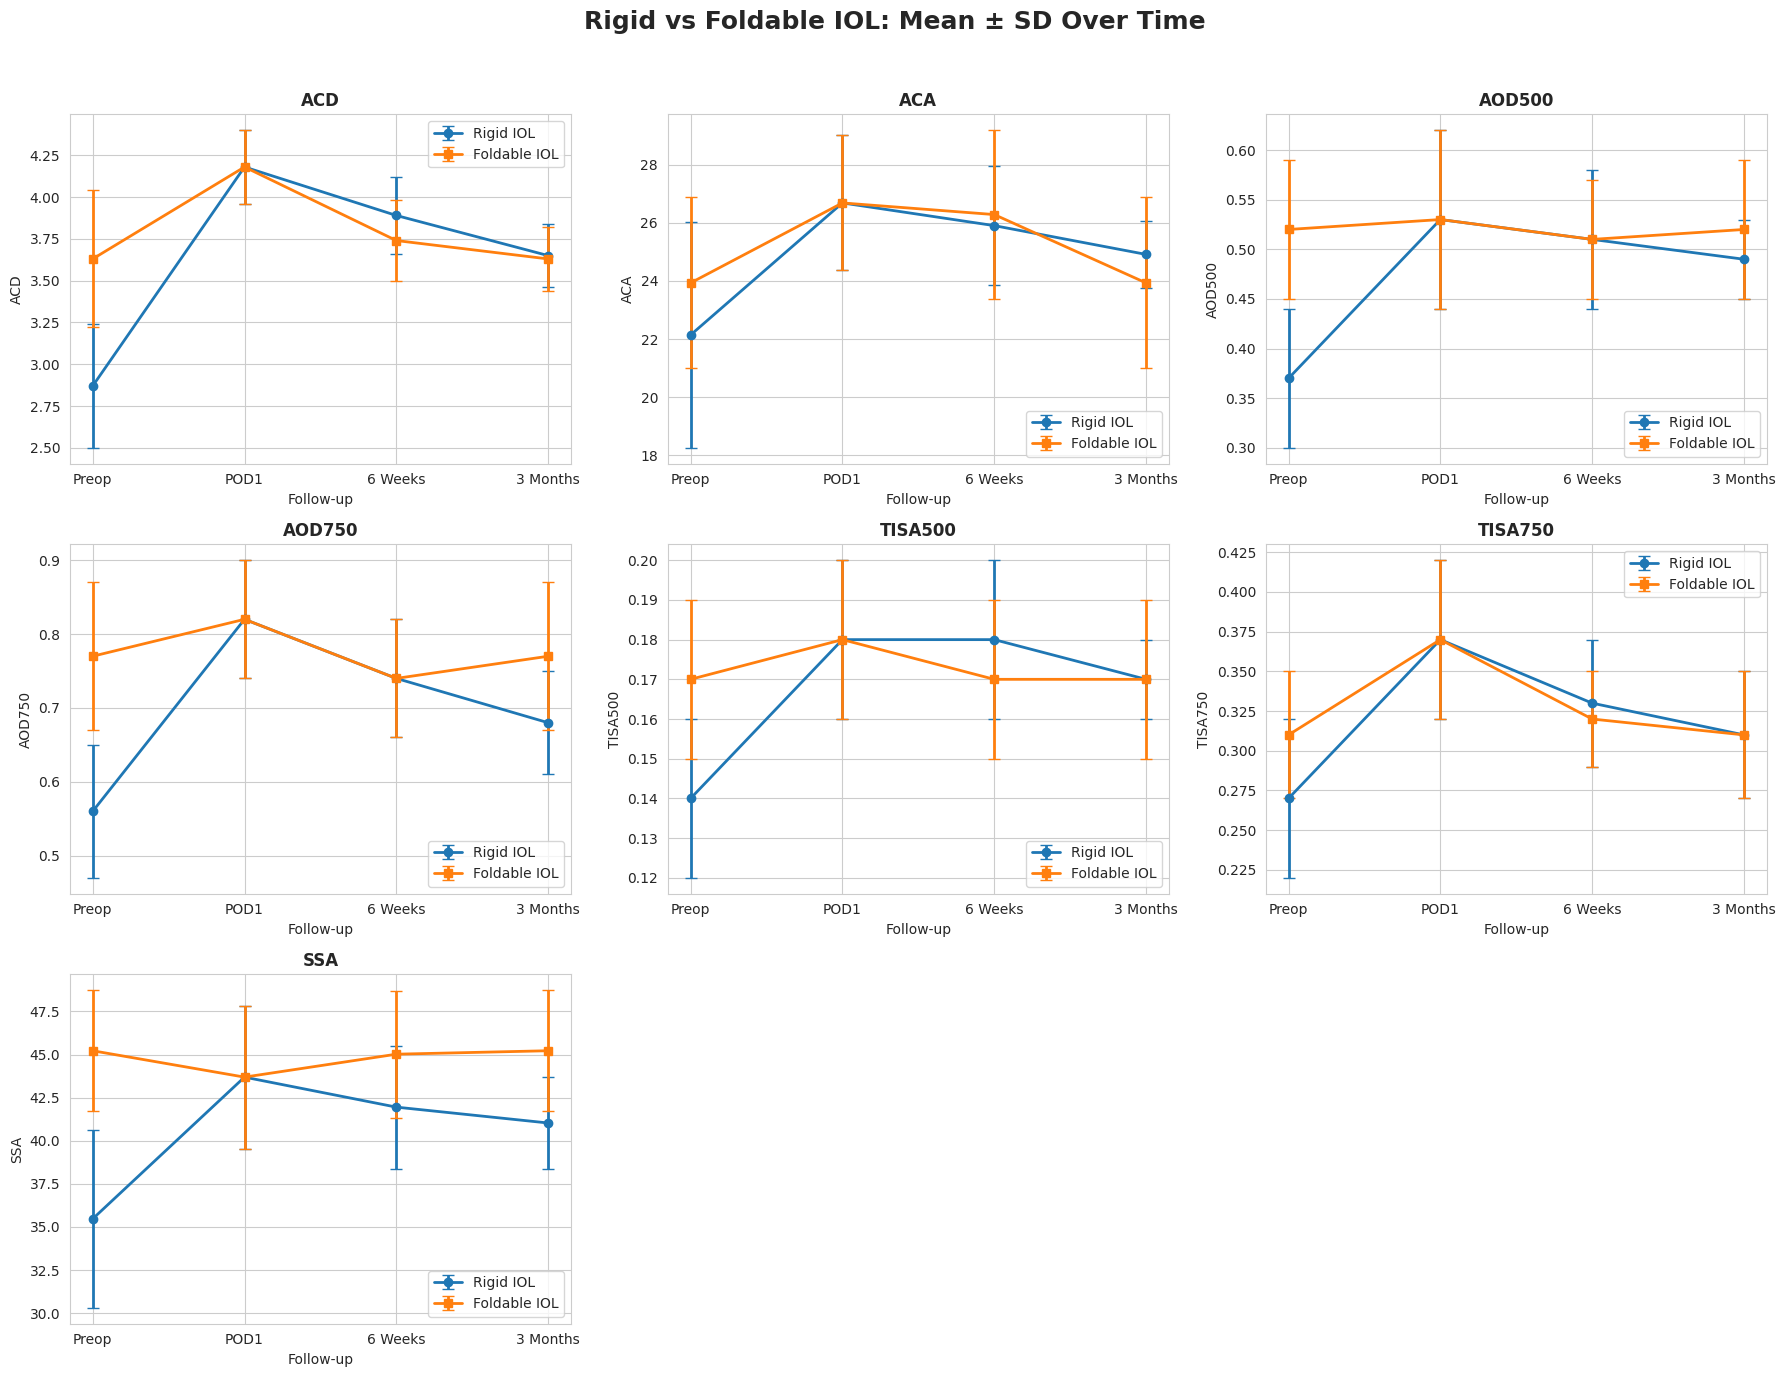

In [369]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

timepoints = ['Preop', 'POD1', '6 Weeks', '3 Months']

# ---------- RIGID ----------
rigid_means = {
    'ACD':[2.87,4.18,3.89,3.65],
    'ACA':[22.14,26.68,25.90,24.91],
    'AOD500':[0.37,0.53,0.51,0.49],
    'AOD750':[0.56,0.82,0.74,0.68],
    'TISA500':[0.14,0.18,0.18,0.17],
    'TISA750':[0.27,0.37,0.33,0.31],
    'SSA':[35.47,43.69,41.95,41.03]
}

rigid_sd = {
    'ACD':[0.37,0.22,0.23,0.19],
    'ACA':[3.88,2.32,2.04,1.16],
    'AOD500':[0.07,0.09,0.07,0.04],
    'AOD750':[0.09,0.08,0.08,0.07],
    'TISA500':[0.02,0.02,0.02,0.01],
    'TISA750':[0.05,0.05,0.04,0.04],
    'SSA':[5.16,4.14,3.56,2.68]
}

# ---------- FOLDABLE ----------
fold_means = {
    'ACD':[3.63,4.18,3.74,3.63],
    'ACA':[23.93,26.68,26.28,23.93],
    'AOD500':[0.52,0.53,0.51,0.52],
    'AOD750':[0.77,0.82,0.74,0.77],
    'TISA500':[0.17,0.18,0.17,0.17],
    'TISA750':[0.31,0.37,0.32,0.31],
    'SSA':[45.22,43.69,45.02,45.22]
}

fold_sd = {
    'ACD':[0.41,0.22,0.24,0.19],
    'ACA':[2.94,2.32,2.90,2.94],
    'AOD500':[0.07,0.09,0.06,0.07],
    'AOD750':[0.10,0.08,0.08,0.10],
    'TISA500':[0.02,0.02,0.02,0.02],
    'TISA750':[0.04,0.05,0.03,0.04],
    'SSA':[3.51,4.14,3.69,3.51]
}

variables = ['ACD','ACA','AOD500','AOD750',
             'TISA500','TISA750','SSA']

fig, axes = plt.subplots(3,3, figsize=(18,14))
axes = axes.flatten()

for i, var in enumerate(variables):

    axes[i].errorbar(
        timepoints,
        rigid_means[var],
        yerr=rigid_sd[var],
        marker='o',
        linewidth=2,
        capsize=4,
        label='Rigid IOL'
    )

    axes[i].errorbar(
        timepoints,
        fold_means[var],
        yerr=fold_sd[var],
        marker='s',
        linewidth=2,
        capsize=4,
        label='Foldable IOL'
    )

    axes[i].set_title(var, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Follow-up')
    axes[i].set_ylabel(var)
    axes[i].legend()

# remove empty panels
for j in range(len(variables), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    'Rigid vs Foldable IOL: Mean ± SD Over Time',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

# Between group friedman

In [370]:
import pandas as pd
from scipy.stats import friedmanchisquare, wilcoxon
from itertools import combinations

# Redefine the 'variables' dictionary for the foldable group
# This is copied from cell r5RDEOJNl74a to ensure correct scope
variables = {
    'ACD': [
        fold_preop['Preop ACD (F)'],
        fold_pod1['ACD POD1 (F)'],
        fold_pod6wk['ACD 6wk (F)'],
        fold_pod3mths['ACD 3 mth (F)'],

    ],

    'ACA': [
        fold_preop['Preop ACA (F) '],
        fold_pod1['ACA POD1 (F)'],
        fold_pod6wk['ACA POD 6 wk (F)'],
        fold_pod3mths['ACA 3 mth (F)'],
    ],

    'Mean AOD500': [
        preop_foldable_df['preop_meanAOD500'],
        pod1_foldable_df['pod1_meanAOD500'],
        pod6wk_foldable_df['pod6wk_meanAOD500'],
        pod3mths_foldable_df['meanAOD500'],
    ],

    'Mean AOD750': [
        preop_foldable_df['preop_meanAOD750'],
        pod1_foldable_df['pod1_meanAOD750'],
        pod6wk_foldable_df['pod6wk_meanAOD750'],
        pod3mths_foldable_df['meanAOD750'],

    ],

    'Mean TISA500': [
        preop_foldable_df['preop_meanTISA500'],
        pod1_foldable_df['pod1_meanTISA500'],
        pod6wk_foldable_df['pod6wk_meanTISA500'],
        pod3mths_foldable_df['meanTISA500'],

    ],

    'Mean TISA750': [
        preop_foldable_df['preop_meanTISA750'],
        pod1_foldable_df['pod1_meanTISA750'],
        pod6wk_foldable_df['pod6wk_meanTISA750'],
        pod3mths_foldable_df['meanTISA750'],

    ],

    'Mean SSA': [
        preop_foldable_df['preop_meanSSA'],
        pod1_foldable_df['pod1_meanSSA'],
        pod6wk_foldable_df['pod6wk_meanSSA'],
        pod3mths_foldable_df['meanSSA'],

    ]
}


results = []

for var, vals in variables.items():

    # Combine time points and remove missing values
    df_temp = pd.concat(vals, axis=1).dropna()

    n = len(df_temp)      # subjects
    k = df_temp.shape[1]  # time points

    chi2, p = friedmanchisquare(
        df_temp.iloc[:,0],
        df_temp.iloc[:,1],
        df_temp.iloc[:,2],
        df_temp.iloc[:,3]
    )

    kendalls_w = chi2 / (n * (k - 1))

    results.append({
        'Variable': var,
        'N': n,
        'Chi-square': round(chi2, 3),
        'df': k - 1,
        'p-value': round(p, 5),
        'Kendalls_W': round(kendalls_w, 3)
    })

friedman_df = pd.DataFrame(results)

friedman_df

,Variable,N,Chi-square,df,p-value,Kendalls_W
0,ACD,29,78.446,3,0.0,0.902
1,ACA,29,29.814,3,0.0,0.343
2,Mean AOD500,29,46.878,3,0.0,0.539
3,Mean AOD750,29,70.941,3,0.0,0.815
4,Mean TISA500,29,40.742,3,0.0,0.468
5,Mean TISA750,29,49.067,3,0.0,0.564
6,Mean SSA,29,40.068,3,0.0,0.461


In [371]:
from scipy.stats import mannwhitneyu
import pandas as pd

# Define rigid_variables using existing rigid dataframes
rigid_variables = {
    'ACD': [
        preop_rigid['ACD'],
        pod1_rigid['ACD'],
        pod6wk_rigid['ACD'],
        pod3mth_rigid['ACD'],
    ],
    'ACA': [
        preop_rigid['ACA'],
        pod1_rigid['ACA'],
        pod6wk_rigid['ACA'],
        pod3mth_rigid['ACA'],
    ],
    'Mean AOD500': [
        preop_rigid_df['preop_meanAOD500'],
        pod1_rigid_df['pod1_meanAOD500'],
        pod6wk_rigid_df['pod6wk_meanAOD500'],
        pod3mth_rigid_df['pod3mth_meanAOD500'],
    ],
    'Mean AOD750': [
        preop_rigid_df['preop_meanAOD750'],
        pod1_rigid_df['pod1_meanAOD750'],
        pod6wk_rigid_df['pod6wk_meanAOD750'],
        pod3mth_rigid_df['pod3mth_meanAOD750'],
    ],
    'Mean TISA500': [
        preop_rigid_df['preop_meanTISA500'],
        pod1_rigid_df['pod1_meanTISA500'],
        pod6wk_rigid_df['pod6wk_meanTISA500'],
        pod3mth_rigid_df['pod3mth_meanTISA500'],
    ],
    'Mean TISA750': [
        preop_rigid_df['preop_meanTISA750'],
        pod1_rigid_df['pod1_meanTISA750'],
        pod6wk_rigid_df['pod6wk_meanTISA750'],
        pod3mth_rigid_df['pod3mth_meanTISA750'],
    ],
    'Mean SSA': [
        preop_rigid_df['preop_meanSSA'],
        pod1_rigid_df['pod1_meanSSA'],
        pod6wk_rigid_df['pod6wk_meanSSA'],
        pod3mth_rigid_df['pod3mth_meanSSA'],
    ]
}

# The 'variables' object in the kernel state is currently the foldable_variables
# as it was last defined in cell sp1AT6UfGwB8 for the foldable group.
# We will use this as foldable_variables for clarity.
foldable_variables = variables

variable_names = list(foldable_variables.keys())
timepoints_list = ['Preop','POD1','POD6wk','POD3mth']
timepoint_map = {tp: i for i, tp in enumerate(timepoints_list)}

results = []

for var in variable_names:
    for tp_name in timepoints_list:
        tp_idx = timepoint_map[tp_name]

        # Access the correct series from the respective dictionaries
        rigid_series = rigid_variables[var][tp_idx].dropna()
        foldable_series = foldable_variables[var][tp_idx].dropna()

        # Ensure both series have data to compare
        if not rigid_series.empty and not foldable_series.empty:
            U, p = mannwhitneyu(
                rigid_series,
                foldable_series,
                alternative='two-sided'
            )
        else:
            # Handle cases where one or both series might be empty after dropna
            U, p = None, None # Or assign np.nan, depending on desired output

        results.append({
            'Variable': var,
            'Timepoint': tp_name,
            'U statistic': U,
            'p-value': p
        })

between_group_df = pd.DataFrame(results)

In [372]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

# -----------------------------
# Time points
# -----------------------------
timepoints = ['Preop', 'POD1', 'POD6wk', 'POD3mth']

# -----------------------------
# Rigid group variables
# -----------------------------
rigid_variables = {
    'ACD': [
        preop_rigid['ACD'],
        pod1_rigid['ACD'],
        pod6wk_rigid['ACD'],
        pod3mth_rigid['ACD']
    ],
    'ACA': [
        preop_rigid['ACA'],
        pod1_rigid['ACA'],
        pod6wk_rigid['ACA'],
        pod3mth_rigid['ACA']
    ],
    'Mean AOD500': [
        preop_rigid_df['preop_meanAOD500'],
        pod1_rigid_df['pod1_meanAOD500'],
        pod6wk_rigid_df['pod6wk_meanAOD500'],
        pod3mth_rigid_df['pod3mth_meanAOD500']
    ],
    'Mean AOD750': [
        preop_rigid_df['preop_meanAOD750'],
        pod1_rigid_df['pod1_meanAOD750'],
        pod6wk_rigid_df['pod6wk_meanAOD750'],
        pod3mth_rigid_df['pod3mth_meanAOD750']
    ],
    'Mean TISA500': [
        preop_rigid_df['preop_meanTISA500'],
        pod1_rigid_df['pod1_meanTISA500'],
        pod6wk_rigid_df['pod6wk_meanTISA500'],
        pod3mth_rigid_df['pod3mth_meanTISA500']
    ],
    'Mean TISA750': [
        preop_rigid_df['preop_meanTISA750'],
        pod1_rigid_df['pod1_meanTISA750'],
        pod6wk_rigid_df['pod6wk_meanTISA750'],
        pod3mth_rigid_df['pod3mth_meanTISA750']
    ],
    'Mean SSA': [
        preop_rigid_df['preop_meanSSA'],
        pod1_rigid_df['pod1_meanSSA'],
        pod6wk_rigid_df['pod6wk_meanSSA'],
        pod3mth_rigid_df['pod3mth_meanSSA']
    ]
}

# -----------------------------
# Foldable group variables
# (assuming variables contains foldable data)
# -----------------------------
foldable_variables = variables

# -----------------------------
# Mann–Whitney U tests
# -----------------------------
results = []

for var in rigid_variables.keys():

    for tp_idx, tp_name in enumerate(timepoints):

        rigid = pd.Series(rigid_variables[var][tp_idx]).dropna()
        foldable = pd.Series(foldable_variables[var][tp_idx]).dropna()

        if len(rigid) > 0 and len(foldable) > 0:

            try:
                U, p = mannwhitneyu(
                    rigid,
                    foldable,
                    alternative='two-sided',
                    method='exact'
                )
            except:
                U, p = mannwhitneyu(
                    rigid,
                    foldable,
                    alternative='two-sided'
                )

            results.append({
                'Variable': var,
                'Timepoint': tp_name,
                'Rigid N': len(rigid),
                'Foldable N': len(foldable),
                'Rigid Median': round(rigid.median(), 3),
                'Foldable Median': round(foldable.median(), 3),
                'U statistic': round(U, 3),
                'p-value': round(p, 4),
                'Significant': p < 0.05
            })

        else:

            results.append({
                'Variable': var,
                'Timepoint': tp_name,
                'Rigid N': len(rigid),
                'Foldable N': len(foldable),
                'Rigid Median': np.nan,
                'Foldable Median': np.nan,
                'U statistic': np.nan,
                'p-value': np.nan,
                'Significant': np.nan
            })

between_group_df = pd.DataFrame(results)

between_group_df

,Variable,Timepoint,Rigid N,Foldable N,Rigid Median,Foldable Median,U statistic,p-value,Significant
0,ACD,Preop,29,29,2.700,2.880,341.5,0.2270,False
1,ACD,POD1,25,29,3.960,4.140,203.0,0.0052,True
2,ACD,POD6wk,21,29,3.700,3.890,194.0,0.0297,True
3,ACD,POD3mth,9,29,3.600,3.650,123.0,0.8134,False
4,ACA,Preop,29,29,20.560,22.400,386.5,0.6104,False
5,ACA,POD1,25,29,27.540,26.500,425.0,0.2847,False
6,ACA,POD6wk,21,29,26.130,26.170,335.0,0.5587,False
7,ACA,POD3mth,9,29,23.960,24.910,89.5,0.1726,False
8,Mean AOD500,Preop,29,29,0.435,0.375,617.0,0.0019,True
9,Mean AOD500,POD1,25,29,0.570,0.510,518.5,0.0065,True


In [373]:
significant_results = between_group_df[
    between_group_df['p-value'] < 0.05
]

significant_results

,Variable,Timepoint,Rigid N,Foldable N,Rigid Median,Foldable Median,U statistic,p-value,Significant
1,ACD,POD1,25,29,3.960,4.140,203.0,0.0052,True
2,ACD,POD6wk,21,29,3.700,3.890,194.0,0.0297,True
8,Mean AOD500,Preop,29,29,0.435,0.375,617.0,0.0019,True
9,Mean AOD500,POD1,25,29,0.570,0.510,518.5,0.0065,True
12,Mean AOD750,Preop,29,29,0.670,0.560,642.5,0.0004,True
15,Mean AOD750,POD3mth,9,29,0.775,0.675,202.5,0.0128,True
16,Mean TISA500,Preop,29,29,0.155,0.135,579.5,0.0132,True
17,Mean TISA500,POD1,25,29,0.190,0.175,501.0,0.0158,True
20,Mean TISA750,Preop,29,29,0.290,0.255,564.0,0.0254,True
24,Mean SSA,Preop,29,29,41.000,34.000,638.5,0.0005,True


In [374]:
print("Number of significant comparisons:",
      (between_group_df['p-value'] < 0.05).sum())

Number of significant comparisons: 13
